# ARC-AGI models data colector

In [1]:
# Step 0 – Install dependencies (run once)
# scrapy-playwright is required to render the JavaScript leaderboard table.
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "scrapy", "scrapy-playwright", "pandas"], check=True)
subprocess.run([sys.executable, "-m", "playwright", "install", "chromium"], check=True)
print("All dependencies installed.")

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
ERROR:tornado.general:SEND Error: Host unreachable


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


All dependencies installed.


In [1]:
import subprocess
import sys
from pathlib import Path

import pandas as pd

# In Jupyter, __file__ is not available.
# The kernel CWD is the notebook directory (arc_agi_data_scraper/arc_agi_data_scraper/).
# scrapy.cfg lives one level up — that is the Scrapy project root.
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent   # …/arc_agi_data_scraper/
CSV_PATH = PROJECT_ROOT / "leaderboard.csv"

# Sanity-check: scrapy.cfg must exist at PROJECT_ROOT
if not (PROJECT_ROOT / "scrapy.cfg").exists():
    raise FileNotFoundError(
        f"scrapy.cfg not found at {PROJECT_ROOT}. "
        "Make sure the Jupyter kernel was started from the notebook directory."
    )

print(f"Project root : {PROJECT_ROOT}")
print(f"CSV output   : {CSV_PATH}")

Project root : /home/asier/repos/arc-agi/src/arc_agi_data_scraper
CSV output   : /home/asier/repos/arc-agi/src/arc_agi_data_scraper/leaderboard.csv


In [2]:
# Run the Scrapy spider.
# A subprocess is used to avoid Twisted reactor / Jupyter asyncio conflicts.
# result = subprocess.run(
#     [sys.executable, "-m", "scrapy", "crawl", "leaderboard"],
#     cwd=str(PROJECT_ROOT),
#     capture_output=True,
#     text=True,
# )

# print("--- STDOUT ---")
# print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)

# if result.returncode != 0:
#     print("--- STDERR ---")
#     print(result.stderr[-3000:] if len(result.stderr) > 3000 else result.stderr)
#     raise RuntimeError(f"Scrapy exited with code {result.returncode}")

# print(f"\nSpider finished successfully. CSV saved to: {CSV_PATH}")

In [3]:
# Load the CSV produced by the spider
df = pd.read_csv(CSV_PATH)

print(f"Shape: {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)")
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (166, 9)  (166 rows × 9 columns)

Column dtypes:
model             object
author            object
date              object
solution_type     object
arc_agi_1        float64
arc_agi_2        float64
arc_agi_3        float64
cost_per_task    float64
total_cost        object
dtype: object

First 5 rows:


,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost
0,GLM-5.2,Z.ai,2026-06-13,CoT,77.0,22.0,NaN,0.25,NaN
1,Claude Opus 4.8 (Low),Anthropic,2026-06-01,CoT,88.0,62.0,NaN,1.68,NaN
2,Claude Opus 4.8 (Medium),Anthropic,2026-06-01,CoT,91.0,71.0,NaN,2.39,NaN
3,Claude Opus 4.8 (High),Anthropic,2026-06-01,CoT,92.0,72.0,1.0,2.74,$10.0K
4,Claude Opus 4.8 (Max),Anthropic,2026-06-01,CoT,92.0,NaN,NaN,2.33,NaN


In [4]:
# Filter: keep only rows that have an ARC-AGI-1 score, sorted best-first
df_arc1 = (
    df[df["arc_agi_1"].notna()]
    .sort_values("arc_agi_1", ascending=False)
    .reset_index(drop=True)
)

print(f"Rows with ARC-AGI-1 score: {len(df_arc1)}")
df_arc1

Rows with ARC-AGI-1 score: 155


,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost
0,Stem Grad,Human,NaN,NaN,98.0,NaN,NaN,10.000,NaN
1,Human Panel,Human,NaN,NaN,98.0,100.0,NaN,17.000,NaN
2,Gemini 3.1 Pro (Preview),Google,2026-02-19,CoT,98.0,77.0,NaN,0.962,NaN
3,Gemini 3 Deep Think (2/26),Google,2026-02-12,CoT,96.0,84.0,NaN,13.620,NaN
4,GPT-5.5 Pro (High),OpenAI,2026-04-23,CoT,96.0,84.0,NaN,10.510,NaN
...,...,...,...,...,...,...,...,...,...
150,Llama 4 Maverick,Meta,2025-04-05,Base LLM,4.0,0.0,NaN,0.012,NaN
151,GPT-4.1-Mini,OpenAI,2025-04-14,Base LLM,3.0,0.0,NaN,0.014,NaN
152,GPT-5 Nano (Minimal),OpenAI,2025-08-07,CoT,1.0,0.0,NaN,0.003,NaN
153,Llama 4 Scout,Meta,2025-04-05,Base LLM,0.0,0.0,NaN,0.006,NaN


In [5]:
# Filter by author/organisation
# Change AUTHOR to any value from the 'author' column (e.g. "OpenAI", "Google", "xAI")
AUTHOR = "Anthropic"

df_author = df_arc1[df_arc1["author"] == AUTHOR].reset_index(drop=True)
print(f"Rows for '{AUTHOR}': {len(df_author)}")
df_author

Rows for 'Anthropic': 42


,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost
0,"Claude Opus 4.6 (120K, High)",Anthropic,2026-02-05,CoT,94.0,69.0,NaN,3.470,NaN
1,"Claude Opus 4.6 (120K, Max)",Anthropic,2026-02-05,CoT,93.0,68.0,NaN,3.640,NaN
2,Claude 4.7 (High),Anthropic,2026-04-16,CoT,93.0,68.0,NaN,3.170,NaN
3,Claude 4.7 (Max),Anthropic,2026-04-16,CoT,92.0,75.0,NaN,7.430,NaN
4,"Claude Opus 4.6 (120K, Medium)",Anthropic,2026-02-05,CoT,92.0,66.0,NaN,2.720,NaN
5,Claude Opus 4.8 (High),Anthropic,2026-06-01,CoT,92.0,72.0,1.0,2.740,$10.0K
6,Claude Opus 4.8 (Max),Anthropic,2026-06-01,CoT,92.0,NaN,NaN,2.330,NaN
7,Claude 4.7 (Medium),Anthropic,2026-04-16,CoT,91.0,67.0,NaN,2.960,NaN
8,Claude Opus 4.8 (Medium),Anthropic,2026-06-01,CoT,91.0,71.0,NaN,2.390,NaN
9,Claude 4.7 (Low),Anthropic,2026-04-16,CoT,91.0,62.0,NaN,2.380,NaN


## Remove duplicated models

In [6]:
df_filtered = df_arc1.copy()

In [7]:
# Remove rwos by model name that contain "Low" or "Medium" (case-insensitive)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Low|Medium|Minimal", case=False, na=False)].reset_index(drop=True)

In [8]:
# Remove row by specific model name (case-insensitive)
df_filtered = df_filtered[~df_filtered["model"].str.contains('GPT-5.2 (Refine.)', case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.5 Pro (High)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.5 (xHigh)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.5 (High)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.2 (Refine.)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.4", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Gemini 3 Deep Think (Preview)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.2", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.1", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5 Pro", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("o3", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5 (High)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Claude Sonnet 4.5", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5 Mini", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Claude Opus 4", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Claude Sonnet 4.6 (High)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Claude Sonnet 4", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5 Nano (High)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-4.5", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Claude Sonnet 4", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-4.", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.1 (Thinking, None)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-4o", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Grok 4 (Refine.)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Opus 4.5 (Thinking, 32K)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5 (High)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Claude 4.7 (High)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.5 (High)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.5 (xHigh)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Opus 4.5 (Thinking, 32K)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Opus 4.5 (Thinking, 16K)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Gemini 2.5 Pro (Thinking 16K)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("Opus 4.5 (Thinking, 1K)", case=False, na=False)].reset_index(drop=True)
df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.5 Pro (High)", case=False, na=False)].reset_index(drop=True)


/tmp/ipykernel_150958/2142109651.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_filtered = df_filtered[~df_filtered["model"].str.contains('GPT-5.2 (Refine.)', case=False, na=False)].reset_index(drop=True)
/tmp/ipykernel_150958/2142109651.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.5 Pro (High)", case=False, na=False)].reset_index(drop=True)
/tmp/ipykernel_150958/2142109651.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_filtered = df_filtered[~df_filtered["model"].str.contains("GPT-5.5 (xHigh)", case=False, na=False)].reset_index(drop=True)
/tmp/ipykernel_150958/2142109651.py:5: UserWarning: This pattern is interpreted as a regular ex

In [9]:
df_filtered

,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost
0,Stem Grad,Human,NaN,NaN,98.0,NaN,NaN,10.000,NaN
1,Human Panel,Human,NaN,NaN,98.0,100.0,NaN,17.000,NaN
2,Gemini 3.1 Pro (Preview),Google,2026-02-19,CoT,98.0,77.0,NaN,0.962,NaN
3,Gemini 3 Deep Think (2/26),Google,2026-02-12,CoT,96.0,84.0,NaN,13.620,NaN
4,GPT-5.5 Pro (High),OpenAI,2026-04-23,CoT,96.0,84.0,NaN,10.510,NaN
...,...,...,...,...,...,...,...,...,...
62,Qwen3-235b-a22b Instruct (25/07),Alibaba,2025-07-25,Base LLM,11.0,1.0,NaN,0.004,NaN
63,Magistral Small,Mistral,2025-06-10,CoT,5.0,0.0,NaN,0.049,NaN
64,Grok 3,xAI,2025-02-19,Base LLM,5.0,0.0,NaN,0.142,NaN
65,Llama 4 Maverick,Meta,2025-04-05,Base LLM,4.0,0.0,NaN,0.012,NaN


In [10]:
# Generate new columns parameters in thousands, precision in TFLOPS and VRAM in GB

# 'parameters' column as float, default value  is 0.0
if "parameters_in_millions" not in df_filtered.columns:
    df_filtered["parameters_in_millions"] = 0.0
df_filtered["parameters_in_millions"] = pd.to_numeric(df_filtered["parameters_in_millions"], errors="coerce").fillna(0.0).astype(float)

if "peak_precision_tflops_fp16" not in df_filtered.columns:
    df_filtered["peak_precision_tflops_fp16"] = 0.0
df_filtered["peak_precision_tflops_fp16"] = pd.to_numeric(df_filtered["peak_precision_tflops_fp16"], errors="coerce").fillna(0.0).astype(float)

if "vram_gb" not in df_filtered.columns:
    df_filtered["vram_gb"] = df_filtered["vram"] if "vram" in df_filtered.columns else 0.0
df_filtered["vram_gb"] = pd.to_numeric(df_filtered["vram_gb"], errors="coerce").fillna(0.0).astype(float)

In [11]:
df_filtered

,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost,parameters_in_millions,peak_precision_tflops_fp16,vram_gb
0,Stem Grad,Human,NaN,NaN,98.0,NaN,NaN,10.000,NaN,0.0,0.0,0.0
1,Human Panel,Human,NaN,NaN,98.0,100.0,NaN,17.000,NaN,0.0,0.0,0.0
2,Gemini 3.1 Pro (Preview),Google,2026-02-19,CoT,98.0,77.0,NaN,0.962,NaN,0.0,0.0,0.0
3,Gemini 3 Deep Think (2/26),Google,2026-02-12,CoT,96.0,84.0,NaN,13.620,NaN,0.0,0.0,0.0
4,GPT-5.5 Pro (High),OpenAI,2026-04-23,CoT,96.0,84.0,NaN,10.510,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
62,Qwen3-235b-a22b Instruct (25/07),Alibaba,2025-07-25,Base LLM,11.0,1.0,NaN,0.004,NaN,0.0,0.0,0.0
63,Magistral Small,Mistral,2025-06-10,CoT,5.0,0.0,NaN,0.049,NaN,0.0,0.0,0.0
64,Grok 3,xAI,2025-02-19,Base LLM,5.0,0.0,NaN,0.142,NaN,0.0,0.0,0.0
65,Llama 4 Maverick,Meta,2025-04-05,Base LLM,4.0,0.0,NaN,0.012,NaN,0.0,0.0,0.0


In [ ]:

# Lo mas lógico debe ser adaptar este modelo con mi grafica o simplemente añadir directamente la mia
compress_arc_new_row = {
    "model": "CompressARC-RTX4070",
    "author": "iliao2345",
    "date": "2025-07-20",
    "solution_type": "Custom",
    "arc_agi_1": 20,  # Example score, replace with actual score if known
    "arc_agi_2": 0,
    "arc_agi_3": 0,
    "parameters_in_millions": 0.076,
    # pending to calculate:
    # 8000 minutes = 133,33 hours
    # CPU v12 CORE + 62 RAM + 1 GPU = 0.25$ per hour
    # total cost = 133,33 * 0.25 = 33.33$ (SEQUENTIAL)
    # total cost = 30 * 0.25 = 7.5$ (SEQUENTIAL)
    "total_cost": 7.5,  # total cost in USD
    # cost_per_task = 33.33 / 400 = 0.083325
    # cost_per_task = 7.5 / 400 = 0.01875
    "cost_per_task": 0.01875,
    "peak_precision_tflops_fp16": 116.6,
    "vram_gb": 12.0,
}

compress_arc_new_row_rx = {
    "model": "SuperCompressARC",
    "author": "asiermarin",
    "date": "2026-07-20",
    "solution_type": "Custom",
    "arc_agi_1": 20,  # Example score, replace with actual score if known
    "arc_agi_2": 0,
    "arc_agi_3": 0,
    "parameters_in_millions": 0.076,
    # pending to calculate:
    # 8000 minutes = 133,33 hours
    # CPU v12 CORE + 62 RAM + 1 GPU = 0.25$ per hour
    # total cost = 133,33 * 0.25 = 33.33$
    "total_cost": 33.33,  # total cost in USD
    # cost_per_task = 33.33 / 400 = 0.083325
    "cost_per_task": 0.083325,
    "peak_precision_tflops_fp16": 195.6,
    "vram_gb": 16.0,
}


df_filtered = pd.concat([df_filtered, pd.DataFrame([compress_arc_new_row])], ignore_index=True)
df_filtered = pd.concat([df_filtered, pd.DataFrame([compress_arc_new_row_rx])], ignore_index=True)

In [38]:
df_filtered

,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost,parameters_in_millions,peak_precision_tflops_fp16,vram_gb
0,Stem Grad,Human,NaN,NaN,98.0,NaN,NaN,10.000000,NaN,0.000,0.0,0.0
1,Human Panel,Human,NaN,NaN,98.0,100.0,NaN,17.000000,NaN,0.000,0.0,0.0
2,Gemini 3.1 Pro (Preview),Google,2026-02-19,CoT,98.0,77.0,NaN,0.962000,NaN,2000000.000,5000.0,1600.0
3,Gemini 3 Deep Think (2/26),Google,2026-02-12,CoT,96.0,84.0,NaN,13.620000,NaN,2000000.000,5000.0,1600.0
4,GPT-5.5 Pro (High),OpenAI,2026-04-23,CoT,96.0,84.0,NaN,10.510000,NaN,4000000.000,10000.0,3200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
65,Grok 3,xAI,2025-02-19,Base LLM,5.0,0.0,NaN,0.142000,NaN,314000.000,1000.0,320.0
66,Llama 4 Maverick,Meta,2025-04-05,Base LLM,4.0,0.0,NaN,0.012000,NaN,400000.000,1500.0,640.0
67,Llama 4 Scout,Meta,2025-04-05,Base LLM,0.0,0.0,NaN,0.006000,NaN,400000.000,1500.0,640.0
68,CompressARC-RTX4070,iliao2345,2025-07-20,Custom,20.0,0.0,0.0,0.018750,7.50,0.076,116.6,12.0


In [39]:
# Modify row with columnn 'model' with value 'Tiny Recursion Model (TRM)'
# Modify solition_type column to 'Custom' for that row
df_filtered.loc[df_filtered['model'] == 'Tiny Recursion Model (TRM)', 'solution_type'] = 'Custom'
df_filtered.loc[df_filtered['model'] == 'Tiny Recursion Model (TRM)', 'parameters_in_millions'] = 7
df_filtered.loc[df_filtered['model'] == 'Tiny Recursion Model (TRM)', 'peak_precision_tflops_fp16'] = 7916
df_filtered.loc[df_filtered['model'] == 'Tiny Recursion Model (TRM)', 'vram_gb'] = 320

In [40]:
df_filtered.loc[df_filtered['model'] == 'Hierarchical Reasoning Model (HRM)', 'solution_type'] = 'Custom'
df_filtered.loc[df_filtered['model'] == 'Hierarchical Reasoning Model (HRM)', 'parameters_in_millions'] = 27
df_filtered.loc[df_filtered['model'] == 'Hierarchical Reasoning Model (HRM)', 'peak_precision_tflops_fp16'] = 6916
df_filtered.loc[df_filtered['model'] == 'Hierarchical Reasoning Model (HRM)', 'vram_gb'] = 280

In [41]:
df_filtered.loc[df_filtered['model'] == 'ARChitects', 'parameters_in_millions'] = 8000
df_filtered.loc[df_filtered['model'] == 'ARChitects', 'peak_precision_tflops_fp16'] = 1979
df_filtered.loc[df_filtered['model'] == 'ARChitects', 'vram_gb'] = 80

In [42]:
df_filtered.loc[df_filtered['model'] == 'Icecuber', 'parameters_in_millions'] = 0
df_filtered.loc[df_filtered['model'] == 'Icecuber', 'peak_precision_tflops_fp16'] = 0.43
df_filtered.loc[df_filtered['model'] == 'Icecuber', 'vram_gb'] = 16

In [43]:
df_filtered

,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost,parameters_in_millions,peak_precision_tflops_fp16,vram_gb
0,Stem Grad,Human,NaN,NaN,98.0,NaN,NaN,10.000000,NaN,0.000,0.0,0.0
1,Human Panel,Human,NaN,NaN,98.0,100.0,NaN,17.000000,NaN,0.000,0.0,0.0
2,Gemini 3.1 Pro (Preview),Google,2026-02-19,CoT,98.0,77.0,NaN,0.962000,NaN,2000000.000,5000.0,1600.0
3,Gemini 3 Deep Think (2/26),Google,2026-02-12,CoT,96.0,84.0,NaN,13.620000,NaN,2000000.000,5000.0,1600.0
4,GPT-5.5 Pro (High),OpenAI,2026-04-23,CoT,96.0,84.0,NaN,10.510000,NaN,4000000.000,10000.0,3200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
65,Grok 3,xAI,2025-02-19,Base LLM,5.0,0.0,NaN,0.142000,NaN,314000.000,1000.0,320.0
66,Llama 4 Maverick,Meta,2025-04-05,Base LLM,4.0,0.0,NaN,0.012000,NaN,400000.000,1500.0,640.0
67,Llama 4 Scout,Meta,2025-04-05,Base LLM,0.0,0.0,NaN,0.006000,NaN,400000.000,1500.0,640.0
68,CompressARC-RTX4070,iliao2345,2025-07-20,Custom,20.0,0.0,0.0,0.018750,7.50,0.076,116.6,12.0


In [44]:
import pandas as pd
import numpy as np

# Diccionario de estimaciones (Parámetros en Millones, VRAM en GB, Peak TFLOPS FP16)
# Ajustado para reflejar predicciones aproximadas de modelos base y SOTA (2025-2026)
llm_specs_estimates = {
    "Gemini 3.5": {"params": 3000000, "vram": 2400, "tflops": 8000},
    "Gemini 3.1": {"params": 2000000, "vram": 1600, "tflops": 5000},
    "Gemini 3": {"params": 2000000, "vram": 1600, "tflops": 5000},
    "Gemini 2.5": {"params": 1000000, "vram": 800, "tflops": 2500},
    "GPT-5.5": {"params": 4000000, "vram": 3200, "tflops": 10000},
    "GPT-5": {"params": 2500000, "vram": 2000, "tflops": 7000},
    "GPT-4": {"params": 1760000, "vram": 1400, "tflops": 5000},
    "Claude 4.7": {"params": 3500000, "vram": 2800, "tflops": 9000},
    "Claude 4": {"params": 3000000, "vram": 2400, "tflops": 8000},
    "Claude 3.7": {"params": 2000000, "vram": 1600, "tflops": 5000},
    "Claude 3": {"params": 1500000, "vram": 1200, "tflops": 4000},
    "Opus 4.5": {"params": 3000000, "vram": 2400, "tflops": 8000},
    "Grok 4.20": {"params": 2500000, "vram": 2000, "tflops": 6000},
    "Grok 4": {"params": 2000000, "vram": 1600, "tflops": 5500},
    "Grok 3": {"params": 314000, "vram": 320, "tflops": 1000},
    "Deepseek V3": {"params": 671000, "vram": 800, "tflops": 2500},
    "Deepseek R1": {"params": 671000, "vram": 800, "tflops": 2500},
    "Llama 4": {"params": 400000, "vram": 640, "tflops": 1500},
    "o4-mini": {"params": 50000, "vram": 80, "tflops": 400},
    "o1-mini": {"params": 10000, "vram": 40, "tflops": 200},
    "Kimi K2.5": {"params": 200000, "vram": 320, "tflops": 800},
    "Minimax M2.5": {"params": 200000, "vram": 320, "tflops": 800},
    "GLM-5.2": {"params": 600000, "vram": 900, "tflops": 1800},
    "GLM-5": {"params": 500000, "vram": 800, "tflops": 1500},
    "Qwen3": {"params": 235000, "vram": 400, "tflops": 1000},
    "Codex Mini": {"params": 20000, "vram": 40, "tflops": 150},
    "Magistral": {"params": 22000, "vram": 80, "tflops": 400},
    "Claude Haiku 4.5": {"params": 100000, "vram": 160, "tflops": 500}
}

def fill_missing_specs(row):
    # 1. Ignorar filas basándonos en tu criterio
    if row['author'] == 'Human' or row['solution_type'] == 'Custom':
        return row
        
    # Variables a rellenar
    model_name = str(row['model'])
    
    params = row['parameters_in_millions']
    vram = row['vram_gb']
    tflops = row['peak_precision_tflops_fp16']
    
    # 2. Comprobar si los valores están vacíos o en 0.0
    needs_update = (pd.isna(params) or params == 0) or \
                   (pd.isna(vram) or vram == 0) or \
                   (pd.isna(tflops) or tflops == 0)
                   
    if needs_update:
        # 3. Buscar correspondencia en el diccionario
        for key, specs in llm_specs_estimates.items():
            if key.lower() in model_name.lower():
                # Si el campo está vacío o es 0, lo rellenamos con la estimación
                if pd.isna(params) or params == 0:
                    row['parameters_in_millions'] = specs['params']
                if pd.isna(vram) or vram == 0:
                    row['vram_gb'] = specs['vram']
                if pd.isna(tflops) or tflops == 0:
                    row['peak_precision_tflops_fp16'] = specs['tflops']
                break
                
    return row

# Aplicar la transformación a cada fila del dataframe
df_filtered = df_filtered.apply(fill_missing_specs, axis=1)

# Visualizar el resultado transformado
df_filtered

,model,author,date,solution_type,arc_agi_1,arc_agi_2,arc_agi_3,cost_per_task,total_cost,parameters_in_millions,peak_precision_tflops_fp16,vram_gb
0,Stem Grad,Human,NaN,NaN,98.0,NaN,NaN,10.000000,NaN,0.000,0.0,0.0
1,Human Panel,Human,NaN,NaN,98.0,100.0,NaN,17.000000,NaN,0.000,0.0,0.0
2,Gemini 3.1 Pro (Preview),Google,2026-02-19,CoT,98.0,77.0,NaN,0.962000,NaN,2000000.000,5000.0,1600.0
3,Gemini 3 Deep Think (2/26),Google,2026-02-12,CoT,96.0,84.0,NaN,13.620000,NaN,2000000.000,5000.0,1600.0
4,GPT-5.5 Pro (High),OpenAI,2026-04-23,CoT,96.0,84.0,NaN,10.510000,NaN,4000000.000,10000.0,3200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
65,Grok 3,xAI,2025-02-19,Base LLM,5.0,0.0,NaN,0.142000,NaN,314000.000,1000.0,320.0
66,Llama 4 Maverick,Meta,2025-04-05,Base LLM,4.0,0.0,NaN,0.012000,NaN,400000.000,1500.0,640.0
67,Llama 4 Scout,Meta,2025-04-05,Base LLM,0.0,0.0,NaN,0.006000,NaN,400000.000,1500.0,640.0
68,CompressARC-RTX4070,iliao2345,2025-07-20,Custom,20.0,0.0,0.0,0.018750,7.50,0.076,116.6,12.0


In [45]:
# Sort by score of arc-agi_1 in descending order
df_filtered = df_filtered.sort_values(by='arc_agi_1', ascending=False).reset_index(drop=True)

In [46]:
# Generate a new CSV file with the filtered and modified data
OUTPUT_CSV_PATH = PROJECT_ROOT / "leaderboard_filtered.csv"
df_filtered.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"Filtered CSV saved to: {OUTPUT_CSV_PATH}")

Filtered CSV saved to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/leaderboard_filtered.csv


## Create different plots

### Examples

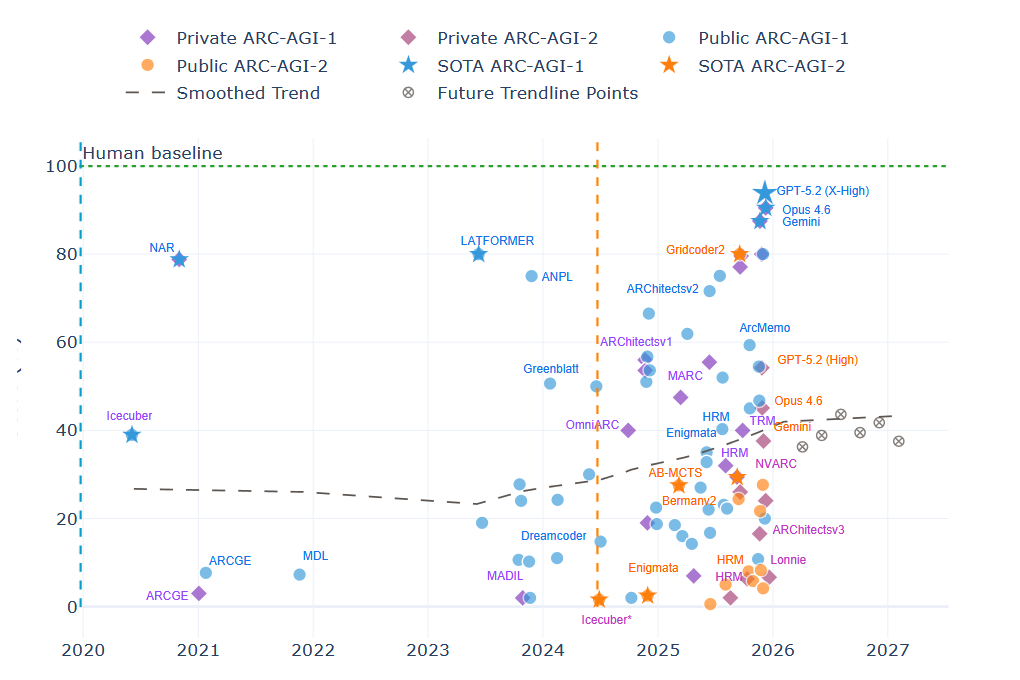

This is a **Time-Series Annotated Scatter Plot**.

It is used to track the performance of various items (in this case, AI models) over a specific time period. The data is categorized by different groups, with specific shapes and colors denoting each category, and it includes reference lines and a trendline to provide context.

Here is a detailed breakdown of the plot's components that you can use as a prompt or instructions to recreate it:

### **Chart Description & Recreation Instructions**

**1. General Layout and Axes**

* **Type:** 2D Scatter Plot.
* **X-axis:** Represents time in years, ranging from 2020 to 2027. Ticks should be placed at each whole year.
* **Y-axis:** Represents a performance score or percentage, ranging from 0 to 100. Major tick intervals should be set at 20 (0, 20, 40, 60, 80, 100).
* **Grid:** Include a very light, subtle grid for both the x and y axes to aid readability. The background should be clean white.

**2. Legend and Categorical Styling**
Position the legend at the top-center of the chart, laid out in three columns. Define the data categories with the following specific marker styles:

* **Private ARC-AGI-1:** Purple diamonds.
* **Private ARC-AGI-2:** Mauve/light pink diamonds.
* **Public ARC-AGI-1:** Light blue circles.
* **Public ARC-AGI-2:** Light orange circles.
* **SOTA ARC-AGI-1:** Blue stars (slightly larger than standard markers).
* **SOTA ARC-AGI-2:** Orange stars (slightly larger than standard markers).
* **Smoothed Trend:** Dark grey dashed line.
* **Future Trendline Points:** Dark grey circles with an 'x' inside.

**3. Data Points and Annotations**

* Scatter the data points across the timeline according to their respective scores and categories.
* **Annotations:** Add text labels next to notable data points (e.g., "GPT-5.2 (X-High)", "Gemini", "NAR", "Icecuber"). The text color of the label must exactly match the color of its corresponding marker. Use a small, clean sans-serif font.

**4. Reference Lines**

* **Horizontal Baseline:** Draw a green dashed line at Y=100. Add the text label "Human baseline" sitting directly on top of this line at the far-left edge.
* **Vertical Markers:**
* Draw a light blue dashed vertical line at X=2020.
* Draw an orange dashed vertical line at approximately mid-2024.



**5. Trendlines**

* Draw a "Smoothed Trend" line using a dark grey dashed stroke. It should start relatively flat (around Y=25) from 2020 to 2023, and then slope upwards through 2024 to 2026.
* Extend the end of this trendline using the "Future Trendline Points" (grey crossed circles) plotted out toward 2026 and 2027.

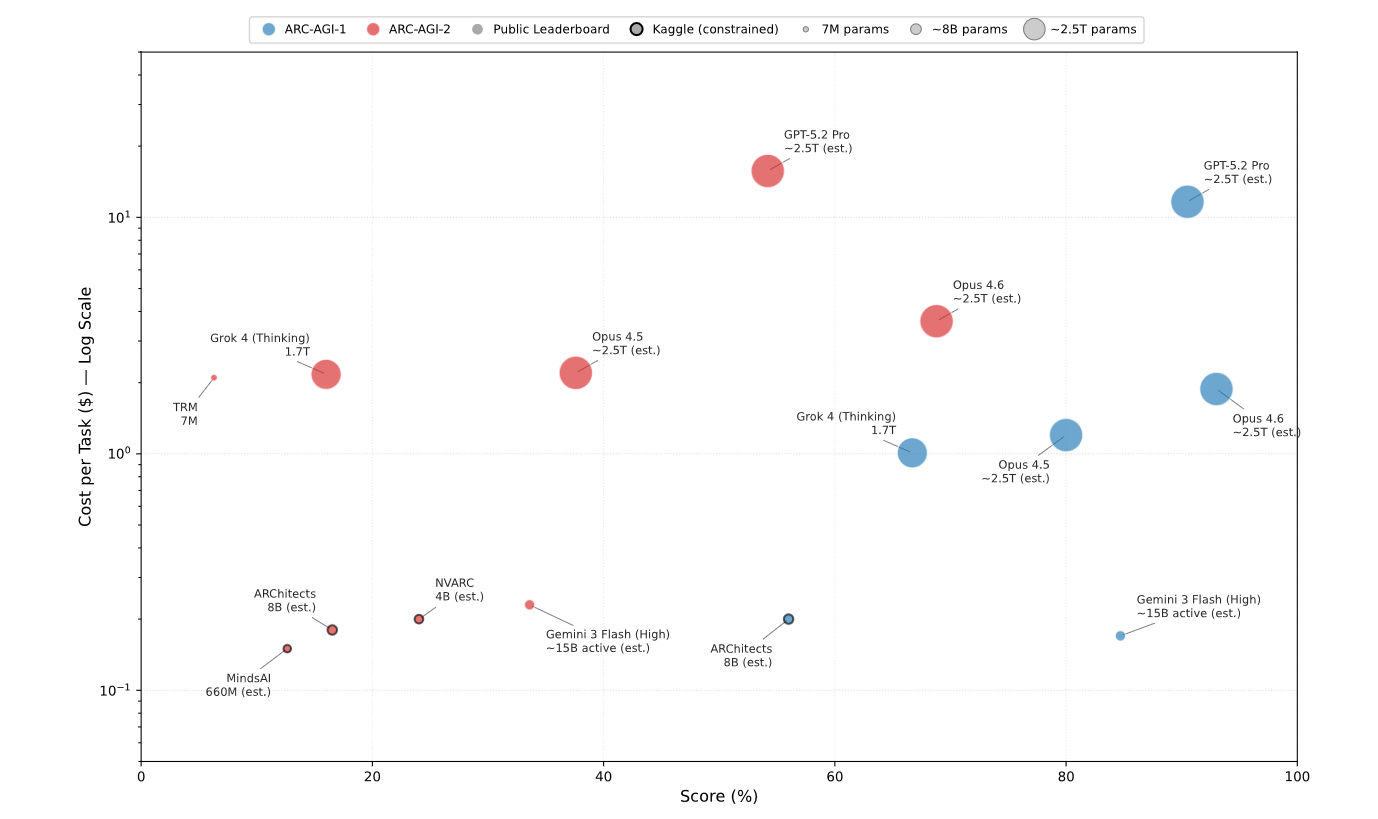

This is a **Bubble Chart**, which is a variation of a scatter plot where the data points are replaced with bubbles, and an additional dimension of the data is represented in the size of the bubbles.

In this specific chart, it tracks the cost-efficiency versus performance of various AI models, utilizing color for task categorization, border style for constraints, and bubble size for parameter count.

Here is a detailed breakdown of the plot's components that you can use as a prompt or instructions to recreate it:

### **Chart Description & Recreation Instructions**

**1. General Layout and Axes**

* **Type:** 2D Bubble Chart.
* **X-axis:** Labeled "Score (%)". It uses a standard linear scale ranging from 0 to 100, with major tick marks and labels placed every 20 units (0, 20, 40, 60, 80, 100).
* **Y-axis:** Labeled "Cost per Task ($) — Log Scale". It uses a logarithmic (base 10) scale. The visible range spans roughly from 0.05 to 50, with major tick labels at 10⁻¹ (0.1), 10⁰ (1.0), and 10¹ (10).
* **Grid & Background:** The background is clean white. A very faint, light grey dotted grid aligns with the major ticks on both the x and y axes. The entire plot area is enclosed by a solid, thin black bounding box.

**2. Legend and Categorical Styling**
Position the legend horizontally at the top center of the chart, enclosed within a thin, rounded rectangular border. It defines three visual dimensions:

* **Color (Task Type):**
* **ARC-AGI-1:** Muted blue fill.
* **ARC-AGI-2:** Salmon/light red fill.
* **Public Leaderboard:** Solid grey fill (used as a baseline key).


* **Border (Constraint):**
* **Kaggle (constrained):** Indicated by a thick, dark grey/black outline around the bubble. Bubbles without this constraint have no border or a very thin one matching their fill color.


* **Size (Parameter Count):**
* **~7M params:** Smallest dot size.
* **~8B params:** Medium dot size.
* **~2.5T params:** Largest dot size. *(Note: Plot the actual data bubbles with continuously scaling sizes based on their specific parameter counts).*



**3. Data Points and Annotations**

* Scatter the bubbles across the plotting area based on their X (Score) and Y (Cost) coordinates. Size them proportionally to the model's parameter count and color them according to their ARC-AGI category.
* Apply the thick black border specifically to the models designated as "Kaggle (constrained)" (predominantly found in the lower-left quadrant, such as MindsAI, ARChtitects, and NVARC).
* **Annotations:** Every single bubble must be labeled.
* Use a thin, straight, dark grey leader line connecting the text to the edge of its corresponding bubble.
* The text must be formatted in a small, dark grey, sans-serif font.
* Split the label into two lines: the top line for the model name (e.g., "GPT-5.2 Pro", "Gemini 3 Flash (High)"), and the bottom line for the parameter count and status (e.g., "~2.5T (est.)", "15B active (est.)").

### New

In [47]:
import matplotlib.pyplot as plt

In [48]:
# Get data from OUTPUT_CSV_PATH

df_saved = pd.read_csv(OUTPUT_CSV_PATH)


In [49]:
# Remove columns 'arc_agi_2' and 'arc_agi_3' from df_saved

df_saved_only_arc_1 = df_saved.drop(columns=['arc_agi_2', 'arc_agi_3'])

In [50]:
df_saved_only_arc_1

,model,author,date,solution_type,arc_agi_1,cost_per_task,total_cost,parameters_in_millions,peak_precision_tflops_fp16,vram_gb
0,Stem Grad,Human,NaN,NaN,98.0,10.000,NaN,0.0,0.0,0.0
1,Human Panel,Human,NaN,NaN,98.0,17.000,NaN,0.0,0.0,0.0
2,Gemini 3.1 Pro (Preview),Google,2026-02-19,CoT,98.0,0.962,NaN,2000000.0,5000.0,1600.0
3,Gemini 3 Deep Think (2/26),Google,2026-02-12,CoT,96.0,13.620,NaN,2000000.0,5000.0,1600.0
4,GPT-5.5 Pro (High),OpenAI,2026-04-23,CoT,96.0,10.510,NaN,4000000.0,10000.0,3200.0
...,...,...,...,...,...,...,...,...,...,...
65,Claude 3.7 (1K),Anthropic,2025-02-24,CoT,11.0,0.140,NaN,2000000.0,5000.0,1600.0
66,Grok 3,xAI,2025-02-19,Base LLM,5.0,0.142,NaN,314000.0,1000.0,320.0
67,Magistral Small,Mistral,2025-06-10,CoT,5.0,0.049,NaN,22000.0,400.0,80.0
68,Llama 4 Maverick,Meta,2025-04-05,Base LLM,4.0,0.012,NaN,400000.0,1500.0,640.0


/tmp/ipykernel_150958/4161887539.py:142: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) JetBrains Mono NL.
  plt.tight_layout()
/home/asier/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) JetBrains Mono NL.
  fig.canvas.print_figure(bytes_io, **kw)


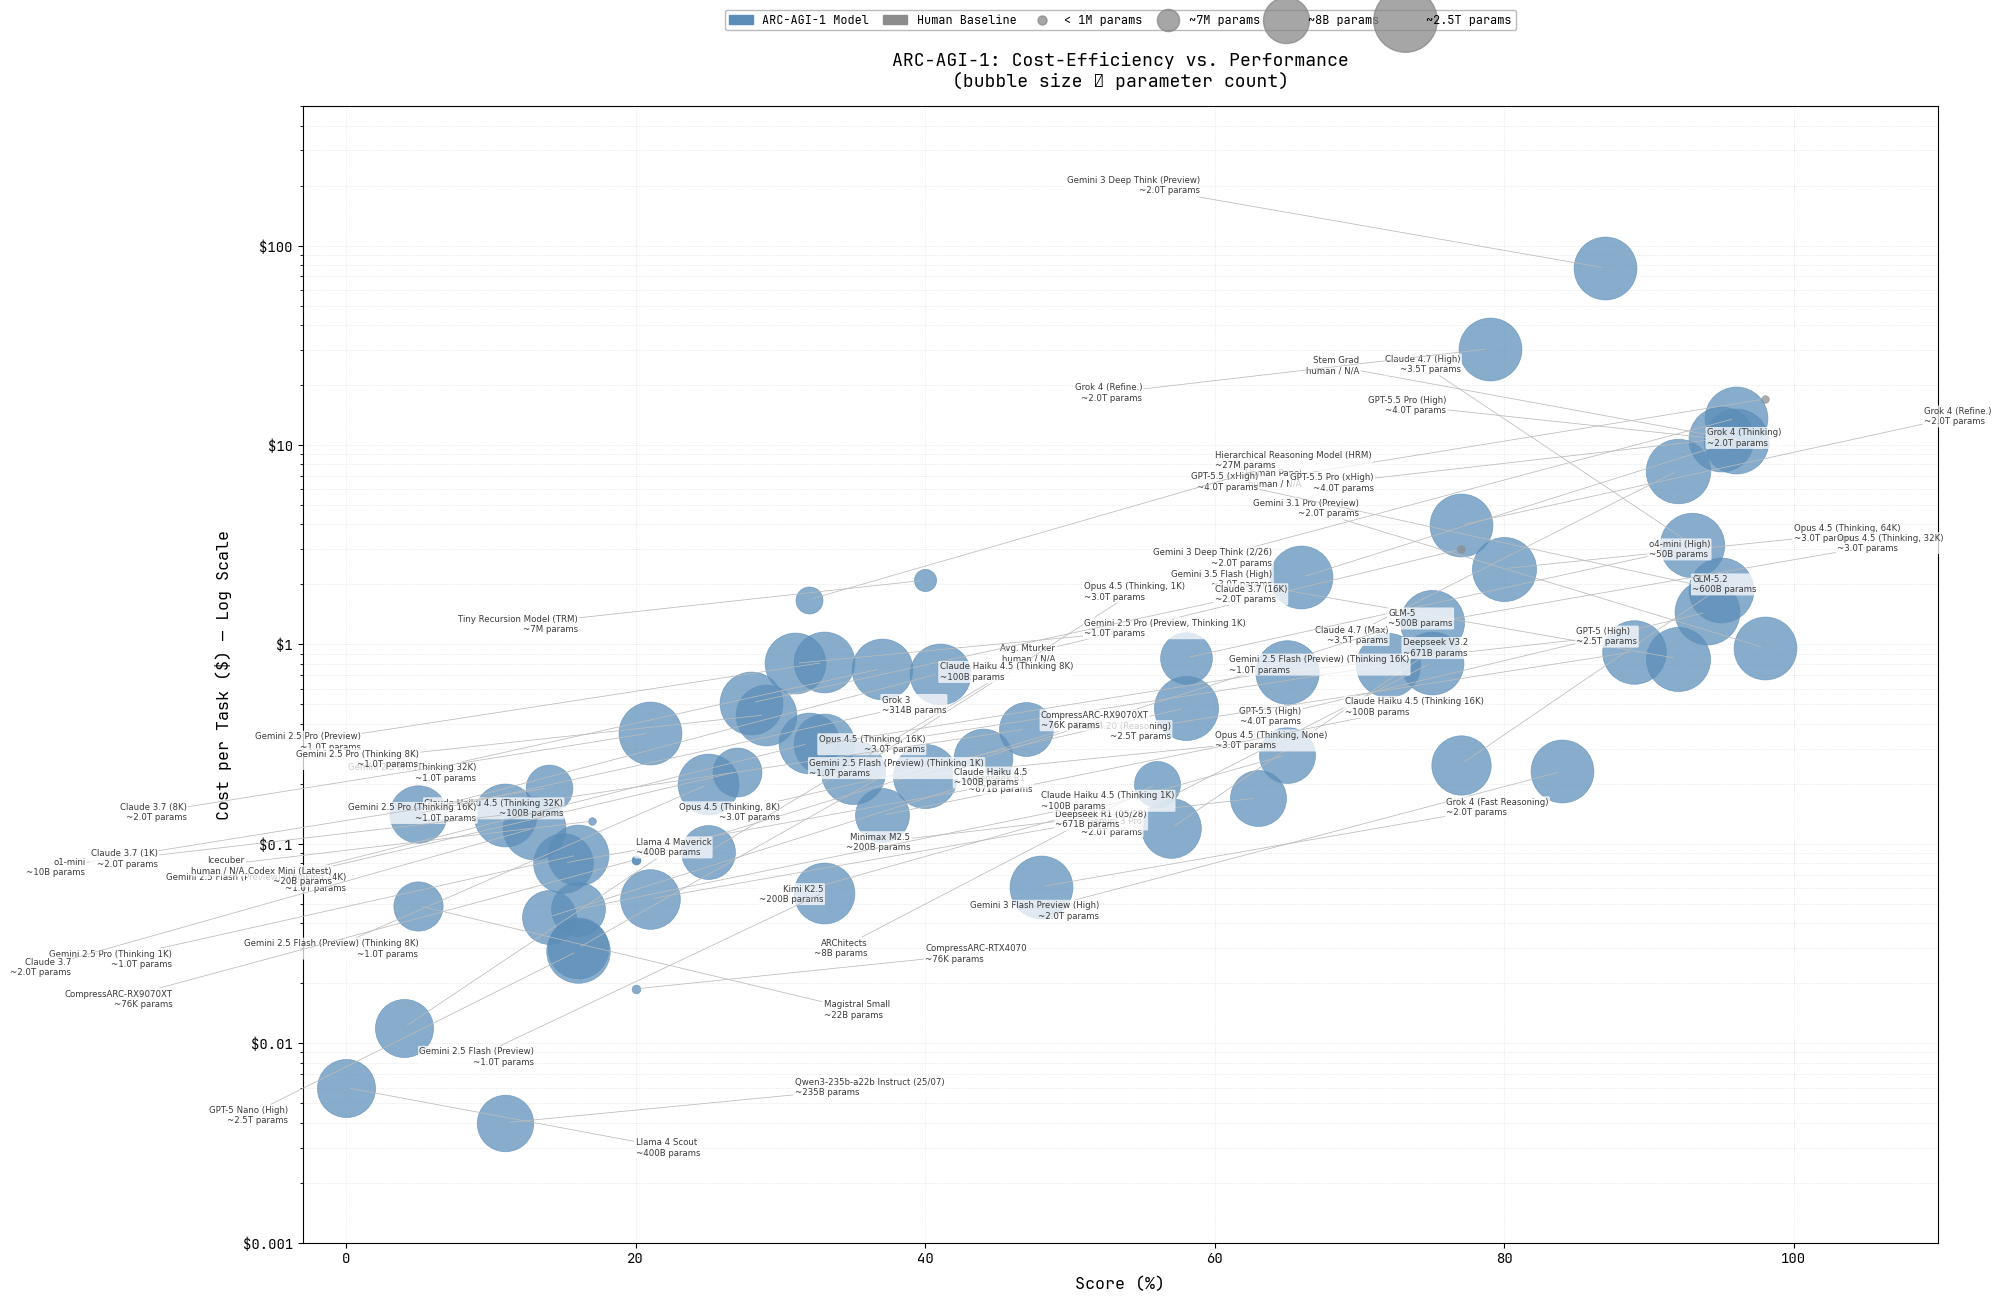

In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from adjustText import adjust_text

# ── Prepare plotting data ─────────────────────────────────────────────────────
df_plot = df_saved_only_arc_1.dropna(subset=['cost_per_task', 'arc_agi_1']).copy()
df_plot = df_plot[df_plot['cost_per_task'] > 0].reset_index(drop=True)

# ── Helpers ───────────────────────────────────────────────────────────────────
def fmt_params(p):
    """Human-readable parameter count label."""
    if pd.isna(p) or p == 0:
        return "human / N/A"
    if p < 1:
        return f"~{p * 1000:.0f}K params"
    if p < 1_000:
        return f"~{int(p)}M params"
    if p < 1_000_000:
        return f"~{p / 1_000:.0f}B params"
    return f"~{p / 1_000_000:.1f}T params"

def bubble_size(p):
    """Log-scaled bubble area (matplotlib s= units)."""
    if pd.isna(p) or p <= 0:
        return 30
    v = (np.log10(p + 0.1) + 1) / 7.7   # normalise to ~[0, 1]
    return 30 + v ** 1.6 * 2200

MUTED_BLUE = '#5B8DB8'
GREY_COL   = '#8C8C8C'

df_plot['bsize']  = df_plot['parameters_in_millions'].apply(bubble_size)
df_plot['plabel'] = df_plot['parameters_in_millions'].apply(fmt_params)
df_plot['color']  = df_plot['author'].apply(
    lambda a: GREY_COL if a == 'Human' else MUTED_BLUE
)

# ── Figure / axes ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 13))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.grid(True, which='both', linestyle=':', color='#DCDCDC', linewidth=0.6, alpha=0.85)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

# ── Scatter bubbles ───────────────────────────────────────────────────────────
for _, row in df_plot.iterrows():
    ax.scatter(
        row['arc_agi_1'], row['cost_per_task'],
        s=row['bsize'], c=row['color'],
        alpha=0.72, edgecolors=row['color'], linewidths=0.5,
        zorder=4
    )

# ── Axes config ───────────────────────────────────────────────────────────────
ax.set_xlim(-3, 110)
ax.set_xticks(range(0, 101, 20))
ax.set_xlabel('Score (%)', fontsize=12, labelpad=8)

ax.set_yscale('log')
ax.set_ylim(0.002, 500)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:g}'))
ax.set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
ax.set_ylabel('Cost per Task ($) — Log Scale', fontsize=12, labelpad=8)

ax.set_title(
    'ARC-AGI-1: Cost-Efficiency vs. Performance\n'
    '(bubble size ∝ parameter count)',
    fontsize=13, pad=14
)

# ── Annotations with leader lines ────────────────────────────────────────────
# Quadrant-aware cycling offsets to spread labels across the chart
offset_x_pool   = [28, -32, 28, -32, 20, -24, 32, -28, 16, -20]
offset_y_factors = [2.5, 0.4, 5.0, 0.2, 1.5, 0.6, 3.5, 0.3, 8.0, 0.15]

for i, (_, row) in enumerate(df_plot.iterrows()):
    x = row['arc_agi_1']
    y = row['cost_per_task']
    label = f"{row['model']}\n{row['plabel']}"

    ox  = offset_x_pool[i % len(offset_x_pool)]
    tyf = offset_y_factors[i % len(offset_y_factors)]

    # Edge corrections: flip horizontal offset near chart borders
    if x > 80 and ox > 0:
        ox = -abs(ox)
    if x < 10 and ox < 0:
        ox = abs(ox)

    ty = max(0.003, min(y * tyf, 200))   # clamp within y-axis limits

    ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + ox, ty),
        fontsize=6.2,
        color='#3A3A3A',
        fontfamily='sans-serif',
        ha='left' if ox >= 0 else 'right',
        va='center',
        arrowprops=dict(
            arrowstyle='-',
            color='#BBBBBB',
            lw=0.55,
            shrinkA=0,
            shrinkB=3,
        ),
        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75),
        zorder=5,
    )

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=MUTED_BLUE, edgecolor=MUTED_BLUE, label='ARC-AGI-1 Model'),
    mpatches.Patch(facecolor=GREY_COL,   edgecolor=GREY_COL,   label='Human Baseline'),
    plt.scatter([], [], s=bubble_size(0.1),       c='#888888', alpha=0.75, label='< 1M params'),
    plt.scatter([], [], s=bubble_size(7),         c='#888888', alpha=0.75, label='~7M params'),
    plt.scatter([], [], s=bubble_size(8_000),     c='#888888', alpha=0.75, label='~8B params'),
    plt.scatter([], [], s=bubble_size(2_500_000), c='#888888', alpha=0.75, label='~2.5T params'),
]

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.09),
    ncol=6,
    fontsize=8.5,
    frameon=True,
    fancybox=True,
    edgecolor='#BBBBBB',
    framealpha=1.0,
    columnspacing=1.2,
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_150958/1199852828.py:156: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) JetBrains Mono NL.
  plt.tight_layout()
/home/asier/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) JetBrains Mono NL.
  fig.canvas.print_figure(bytes_io, **kw)


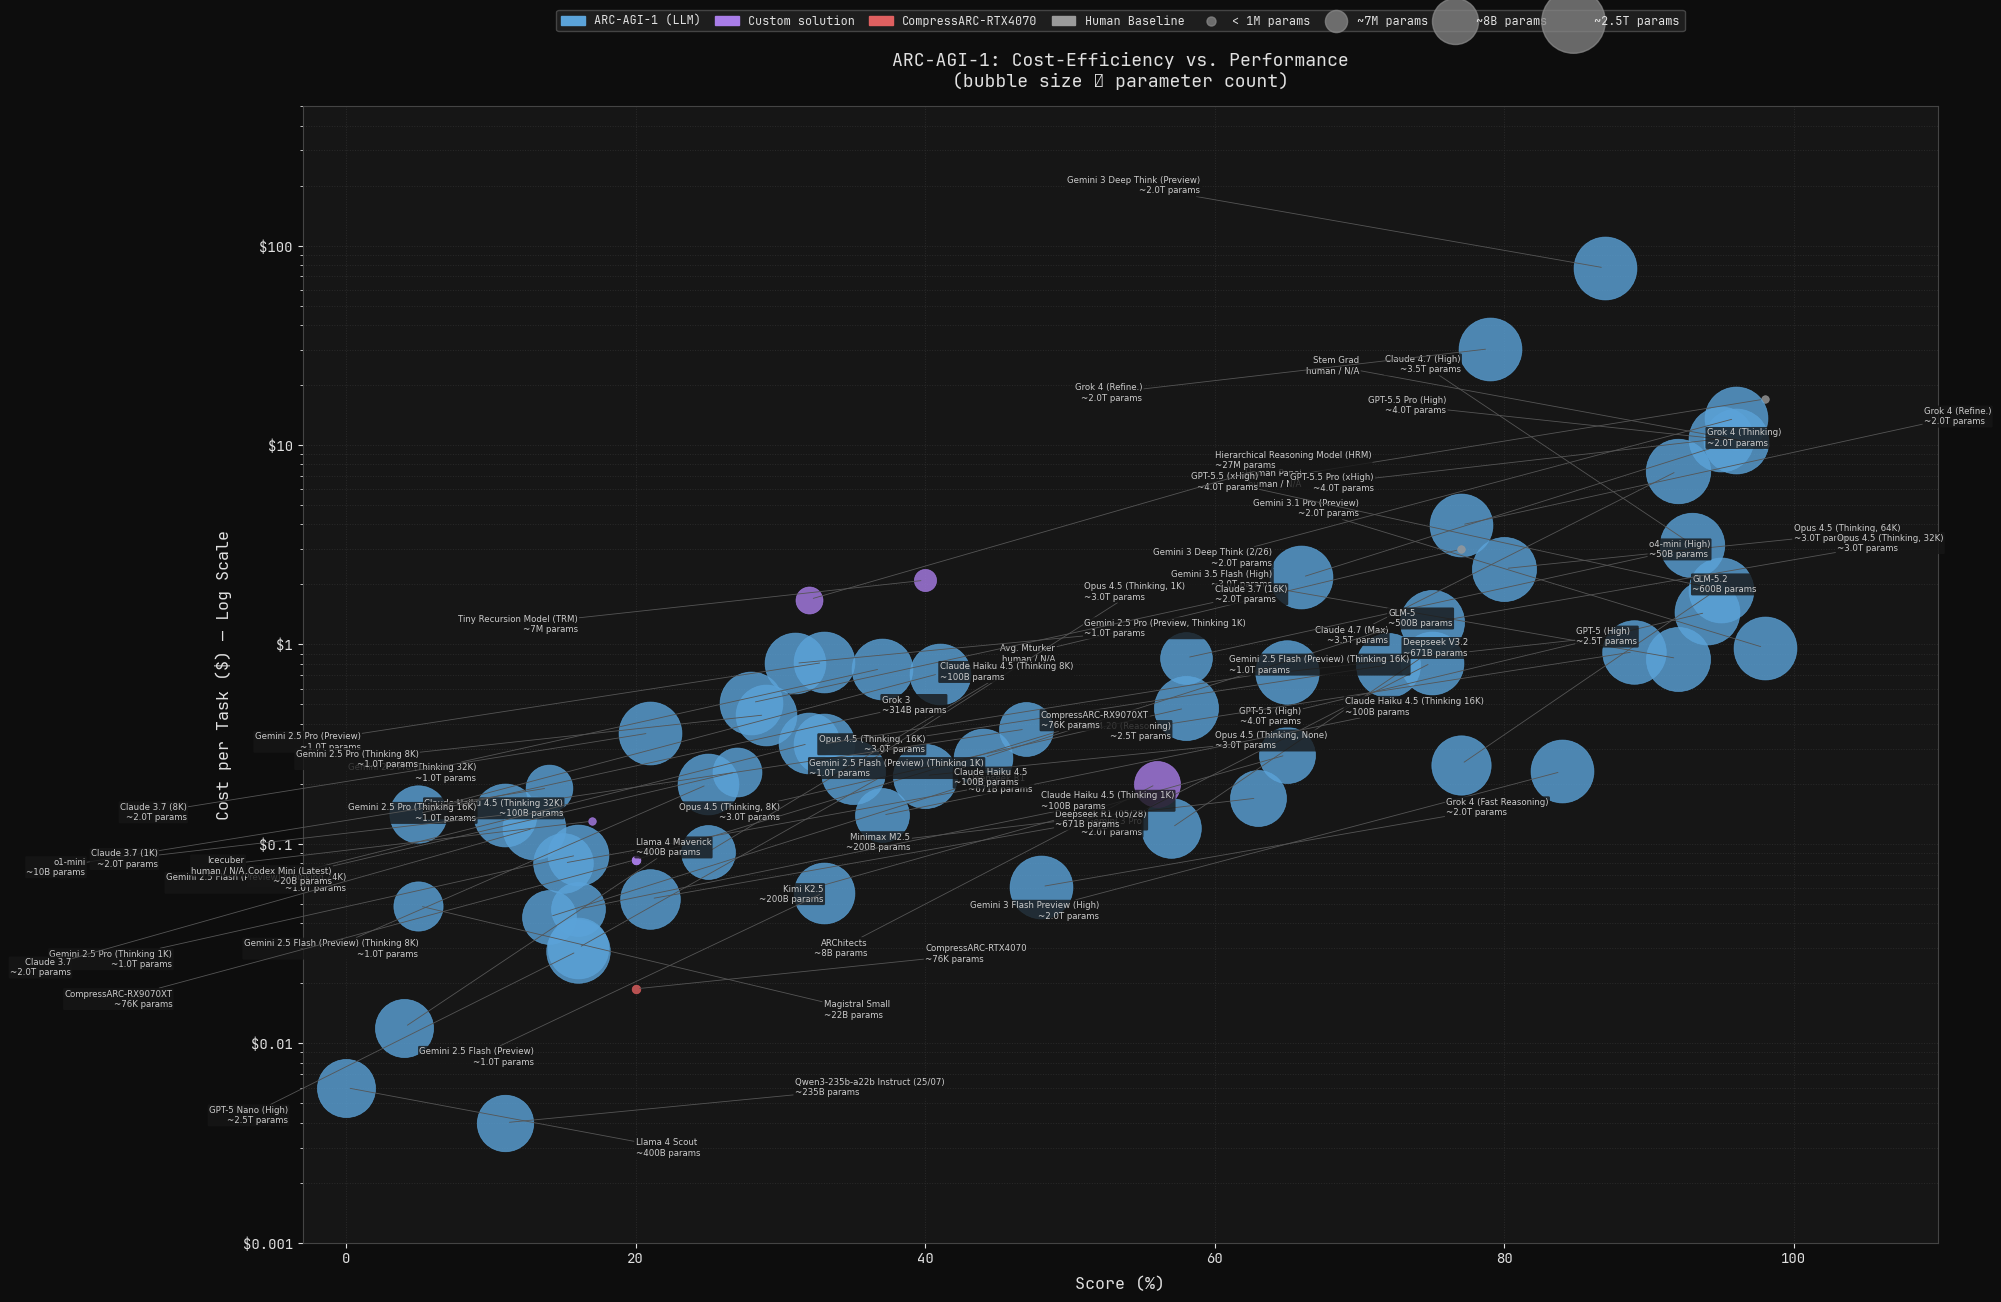

In [52]:
# ── Prepare plotting data ─────────────────────────────────────────────────────
df_plot = df_saved_only_arc_1.dropna(subset=['cost_per_task', 'arc_agi_1']).copy()
df_plot = df_plot[df_plot['cost_per_task'] > 0].reset_index(drop=True)

# ── Helpers ───────────────────────────────────────────────────────────────────
def fmt_params(p):
    if pd.isna(p) or p == 0:
        return "human / N/A"
    if p < 1:
        return f"~{p * 1000:.0f}K params"
    if p < 1_000:
        return f"~{int(p)}M params"
    if p < 1_000_000:
        return f"~{p / 1_000:.0f}B params"
    return f"~{p / 1_000_000:.1f}T params"

def bubble_size(p):
    if pd.isna(p) or p <= 0:
        return 30
    v = (np.log10(p + 0.1) + 1) / 7.7
    return 30 + v ** 1.6 * 2200

# ── Dark theme colors ─────────────────────────────────────────────────────────
BG_COLOR     = '#0D0D0D'
PANEL_COLOR  = '#161616'
GRID_COLOR   = '#2A2A2A'
TEXT_COLOR   = '#E0E0E0'
SPINE_COLOR  = '#444444'

MUTED_BLUE   = '#5BA3D9'   # brighter blue for dark bg
GREY_COL     = '#9A9A9A'
PURPLE_COL   = '#A97DE8'   # brighter purple for dark bg
MUTED_RED    = '#E06060'   # brighter red for dark bg

def get_color(row):
    if row['author'] == 'Human':
        return GREY_COL
    if row['model'] == 'CompressARC-RTX4070':
        return MUTED_RED
    if row.get('solution_type') == 'Custom':
        return PURPLE_COL
    return MUTED_BLUE

df_plot['bsize']  = df_plot['parameters_in_millions'].apply(bubble_size)
df_plot['plabel'] = df_plot['parameters_in_millions'].apply(fmt_params)
df_plot['color']  = df_plot.apply(get_color, axis=1)

# ── Figure / axes ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 13))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(PANEL_COLOR)

ax.grid(True, which='both', linestyle=':', color=GRID_COLOR, linewidth=0.7, alpha=1.0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color(SPINE_COLOR)

ax.tick_params(colors=TEXT_COLOR, which='both')
ax.xaxis.label.set_color(TEXT_COLOR)
ax.yaxis.label.set_color(TEXT_COLOR)
ax.title.set_color(TEXT_COLOR)

# ── Scatter bubbles ───────────────────────────────────────────────────────────
for _, row in df_plot.iterrows():
    ax.scatter(
        row['arc_agi_1'], row['cost_per_task'],
        s=row['bsize'], c=row['color'],
        alpha=0.80, edgecolors=row['color'], linewidths=0.5,
        zorder=4
    )

# ── Axes config ───────────────────────────────────────────────────────────────
ax.set_xlim(-3, 110)
ax.set_xticks(range(0, 101, 20))
ax.set_xlabel('Score (%)', fontsize=12, labelpad=8)

ax.set_yscale('log')
ax.set_ylim(0.002, 500)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:g}'))
ax.set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
ax.set_ylabel('Cost per Task ($) — Log Scale', fontsize=12, labelpad=8)

ax.set_title(
    'ARC-AGI-1: Cost-Efficiency vs. Performance\n'
    '(bubble size ∝ parameter count)',
    fontsize=13, pad=14
)

# ── Annotations with leader lines ────────────────────────────────────────────
offset_x_pool    = [28, -32, 28, -32, 20, -24, 32, -28, 16, -20]
offset_y_factors = [2.5, 0.4, 5.0, 0.2, 1.5, 0.6, 3.5, 0.3, 8.0, 0.15]

for i, (_, row) in enumerate(df_plot.iterrows()):
    x = row['arc_agi_1']
    y = row['cost_per_task']
    label = f"{row['model']}\n{row['plabel']}"

    ox  = offset_x_pool[i % len(offset_x_pool)]
    tyf = offset_y_factors[i % len(offset_y_factors)]

    if x > 80 and ox > 0:
        ox = -abs(ox)
    if x < 10 and ox < 0:
        ox = abs(ox)

    ty = max(0.003, min(y * tyf, 200))

    ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + ox, ty),
        fontsize=6.2,
        color='#CCCCCC',
        fontfamily='sans-serif',
        ha='left' if ox >= 0 else 'right',
        va='center',
        arrowprops=dict(
            arrowstyle='-',
            color='#555555',
            lw=0.6,
            shrinkA=0,
            shrinkB=3,
        ),
        bbox=dict(boxstyle='round,pad=0.15', fc=PANEL_COLOR, ec='none', alpha=0.80),
        zorder=5,
    )

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=MUTED_BLUE,  edgecolor=MUTED_BLUE,  label='ARC-AGI-1 (LLM)'),
    mpatches.Patch(facecolor=PURPLE_COL,  edgecolor=PURPLE_COL,  label='Custom solution'),
    mpatches.Patch(facecolor=MUTED_RED,   edgecolor=MUTED_RED,   label='CompressARC-RTX4070'),
    mpatches.Patch(facecolor=GREY_COL,    edgecolor=GREY_COL,    label='Human Baseline'),
    plt.scatter([], [], s=bubble_size(0.1),       c='#888888', alpha=0.75, label='< 1M params'),
    plt.scatter([], [], s=bubble_size(7),         c='#888888', alpha=0.75, label='~7M params'),
    plt.scatter([], [], s=bubble_size(8_000),     c='#888888', alpha=0.75, label='~8B params'),
    plt.scatter([], [], s=bubble_size(2_500_000), c='#888888', alpha=0.75, label='~2.5T params'),
]

legend = ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.09),
    ncol=8,
    fontsize=8.5,
    frameon=True,
    fancybox=True,
    edgecolor=SPINE_COLOR,
    framealpha=1.0,
    columnspacing=1.2,
    labelcolor=TEXT_COLOR,
    facecolor='#1E1E1E',
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_150958/2168431509.py:144: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) JetBrains Mono NL.
  plt.tight_layout()
/home/asier/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) JetBrains Mono NL.
  fig.canvas.print_figure(bytes_io, **kw)


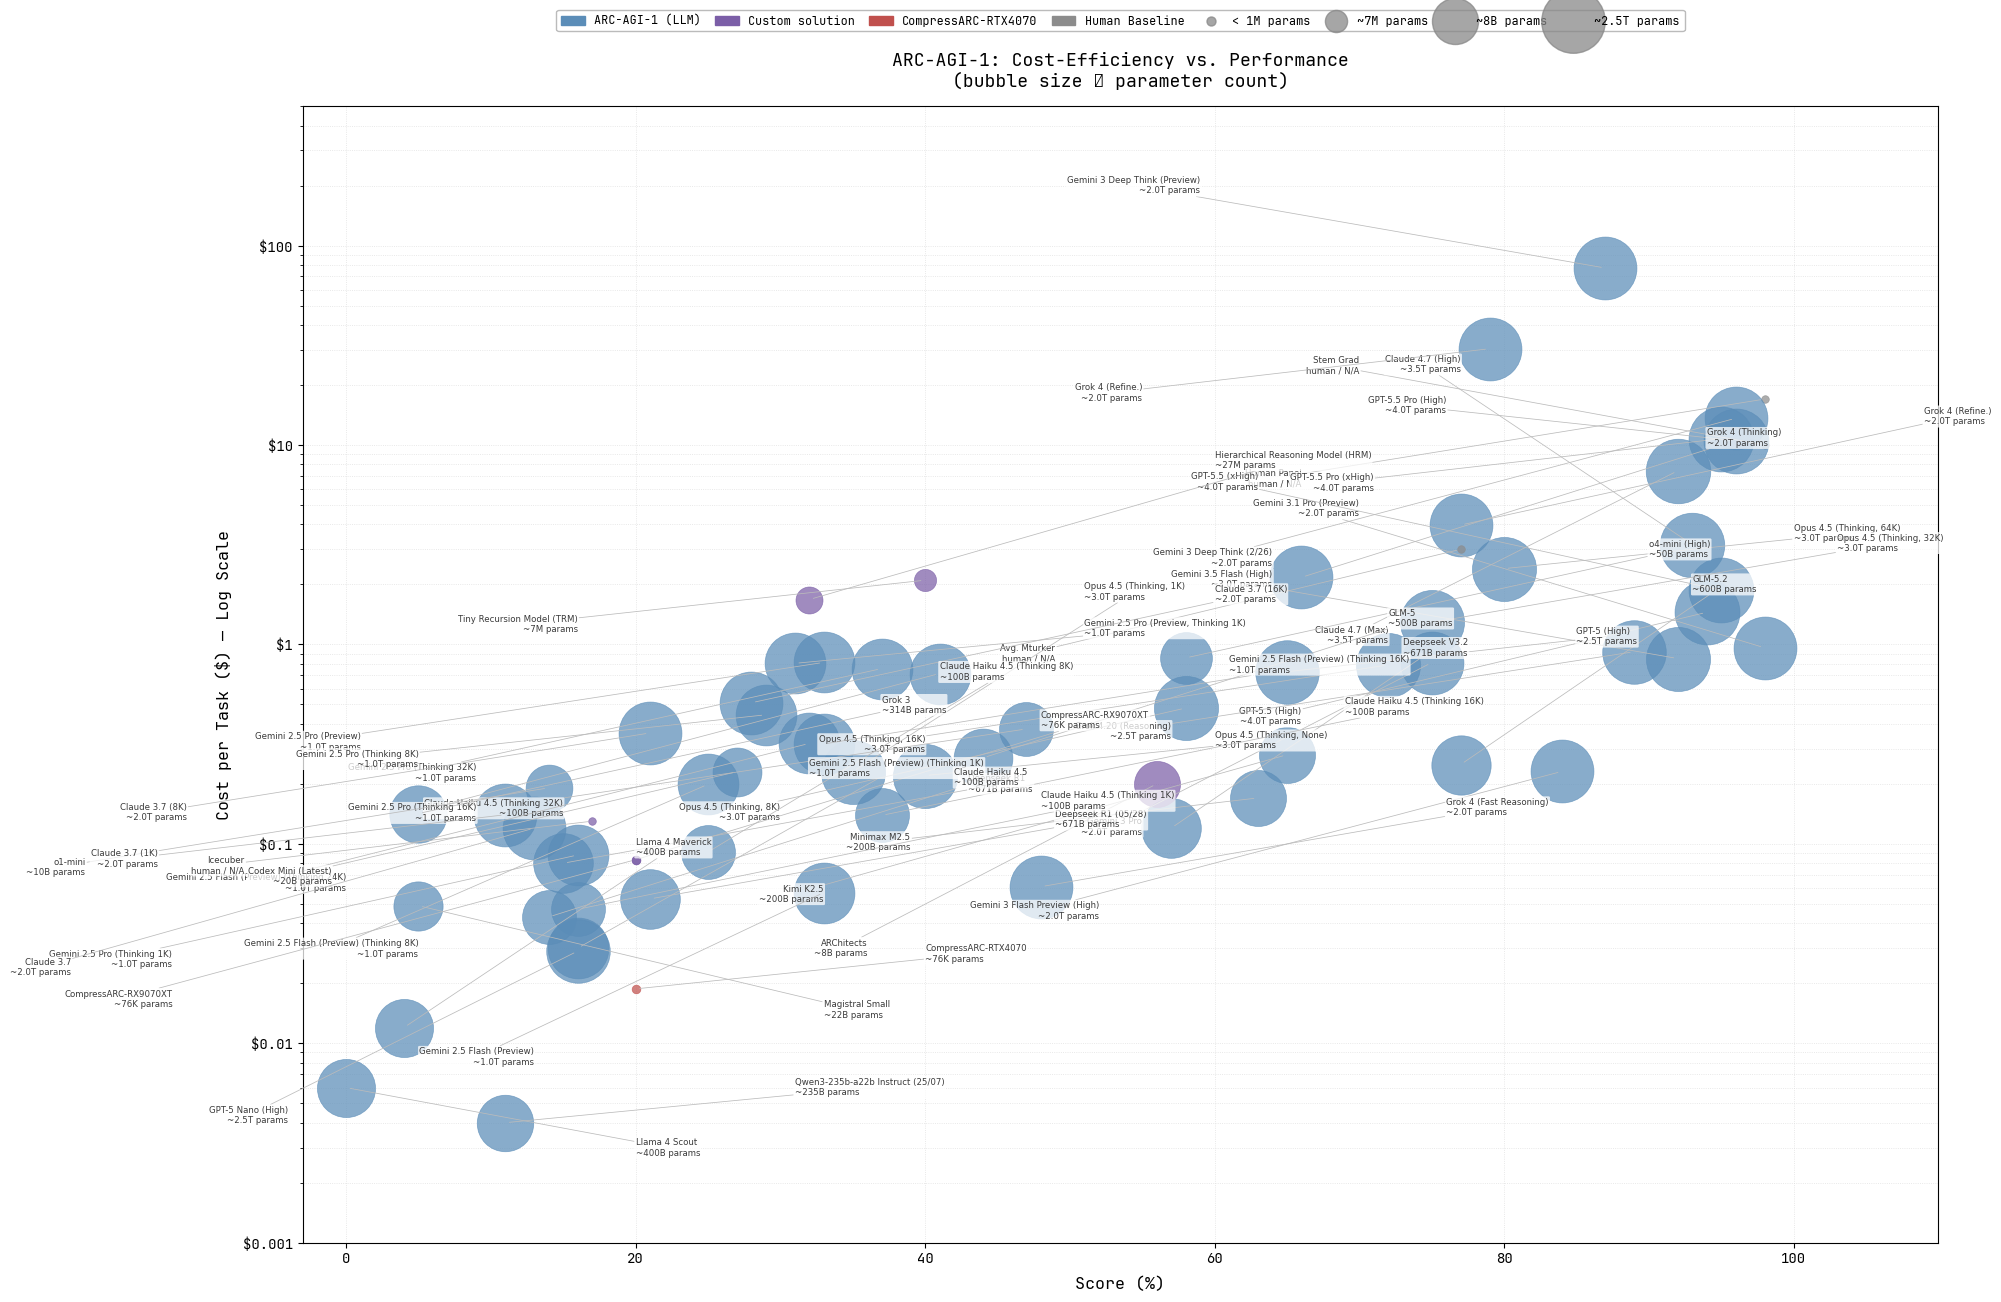

In [53]:
# ── Prepare plotting data ─────────────────────────────────────────────────────
df_plot = df_saved_only_arc_1.dropna(subset=['cost_per_task', 'arc_agi_1']).copy()
df_plot = df_plot[df_plot['cost_per_task'] > 0].reset_index(drop=True)

# ── Helpers ───────────────────────────────────────────────────────────────────
def fmt_params(p):
    """Human-readable parameter count label."""
    if pd.isna(p) or p == 0:
        return "human / N/A"
    if p < 1:
        return f"~{p * 1000:.0f}K params"
    if p < 1_000:
        return f"~{int(p)}M params"
    if p < 1_000_000:
        return f"~{p / 1_000:.0f}B params"
    return f"~{p / 1_000_000:.1f}T params"

def bubble_size(p):
    """Log-scaled bubble area (matplotlib s= units)."""
    if pd.isna(p) or p <= 0:
        return 30
    v = (np.log10(p + 0.1) + 1) / 7.7   # normalise to ~[0, 1]
    return 30 + v ** 1.6 * 2200

MUTED_BLUE   = '#5B8DB8'
GREY_COL     = '#8C8C8C'
PURPLE_COL   = '#7B5EA7'
MUTED_RED    = '#C0504D'

def get_color(row):
    if row['author'] == 'Human':
        return GREY_COL
    if row['model'] == 'CompressARC-RTX4070':
        return MUTED_RED
    if row.get('solution_type') == 'Custom':
        return PURPLE_COL
    return MUTED_BLUE

df_plot['bsize']  = df_plot['parameters_in_millions'].apply(bubble_size)
df_plot['plabel'] = df_plot['parameters_in_millions'].apply(fmt_params)
df_plot['color']  = df_plot.apply(get_color, axis=1)

# ── Figure / axes ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 13))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.grid(True, which='both', linestyle=':', color='#DCDCDC', linewidth=0.6, alpha=0.85)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

# ── Scatter bubbles ───────────────────────────────────────────────────────────
for _, row in df_plot.iterrows():
    ax.scatter(
        row['arc_agi_1'], row['cost_per_task'],
        s=row['bsize'], c=row['color'],
        alpha=0.72, edgecolors=row['color'], linewidths=0.5,
        zorder=4
    )

# ── Axes config ───────────────────────────────────────────────────────────────
ax.set_xlim(-3, 110)
ax.set_xticks(range(0, 101, 20))
ax.set_xlabel('Score (%)', fontsize=12, labelpad=8)

ax.set_yscale('log')
ax.set_ylim(0.002, 500)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:g}'))
ax.set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
ax.set_ylabel('Cost per Task ($) — Log Scale', fontsize=12, labelpad=8)

ax.set_title(
    'ARC-AGI-1: Cost-Efficiency vs. Performance\n'
    '(bubble size ∝ parameter count)',
    fontsize=13, pad=14
)

# ── Annotations with leader lines ────────────────────────────────────────────
offset_x_pool    = [28, -32, 28, -32, 20, -24, 32, -28, 16, -20]
offset_y_factors = [2.5, 0.4, 5.0, 0.2, 1.5, 0.6, 3.5, 0.3, 8.0, 0.15]

for i, (_, row) in enumerate(df_plot.iterrows()):
    x = row['arc_agi_1']
    y = row['cost_per_task']
    label = f"{row['model']}\n{row['plabel']}"

    ox  = offset_x_pool[i % len(offset_x_pool)]
    tyf = offset_y_factors[i % len(offset_y_factors)]

    if x > 80 and ox > 0:
        ox = -abs(ox)
    if x < 10 and ox < 0:
        ox = abs(ox)

    ty = max(0.003, min(y * tyf, 200))

    ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + ox, ty),
        fontsize=6.2,
        color='#3A3A3A',
        fontfamily='sans-serif',
        ha='left' if ox >= 0 else 'right',
        va='center',
        arrowprops=dict(
            arrowstyle='-',
            color='#BBBBBB',
            lw=0.55,
            shrinkA=0,
            shrinkB=3,
        ),
        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.75),
        zorder=5,
    )

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=MUTED_BLUE,  edgecolor=MUTED_BLUE,  label='ARC-AGI-1 (LLM)'),
    mpatches.Patch(facecolor=PURPLE_COL,  edgecolor=PURPLE_COL,  label='Custom solution'),
    mpatches.Patch(facecolor=MUTED_RED,   edgecolor=MUTED_RED,   label='CompressARC-RTX4070'),
    mpatches.Patch(facecolor=GREY_COL,    edgecolor=GREY_COL,    label='Human Baseline'),
    plt.scatter([], [], s=bubble_size(0.1),       c='#888888', alpha=0.75, label='< 1M params'),
    plt.scatter([], [], s=bubble_size(7),         c='#888888', alpha=0.75, label='~7M params'),
    plt.scatter([], [], s=bubble_size(8_000),     c='#888888', alpha=0.75, label='~8B params'),
    plt.scatter([], [], s=bubble_size(2_500_000), c='#888888', alpha=0.75, label='~2.5T params'),
]

ax.legend(
    handles=legend_handles,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.09),
    ncol=8,
    fontsize=8.5,
    frameon=True,
    fancybox=True,
    edgecolor='#BBBBBB',
    framealpha=1.0,
    columnspacing=1.2,
)

plt.tight_layout()
plt.show()

In [54]:
# !rm -rf ~/.cache/matplotlib

### Plot with methods

In [55]:
import os
from pathlib import Path

# Define where you want to save it
output_folder = PROJECT_ROOT / "images"
os.makedirs(output_folder, exist_ok=True) # Ensure the folder exists

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/parameters_models_cost_light.png


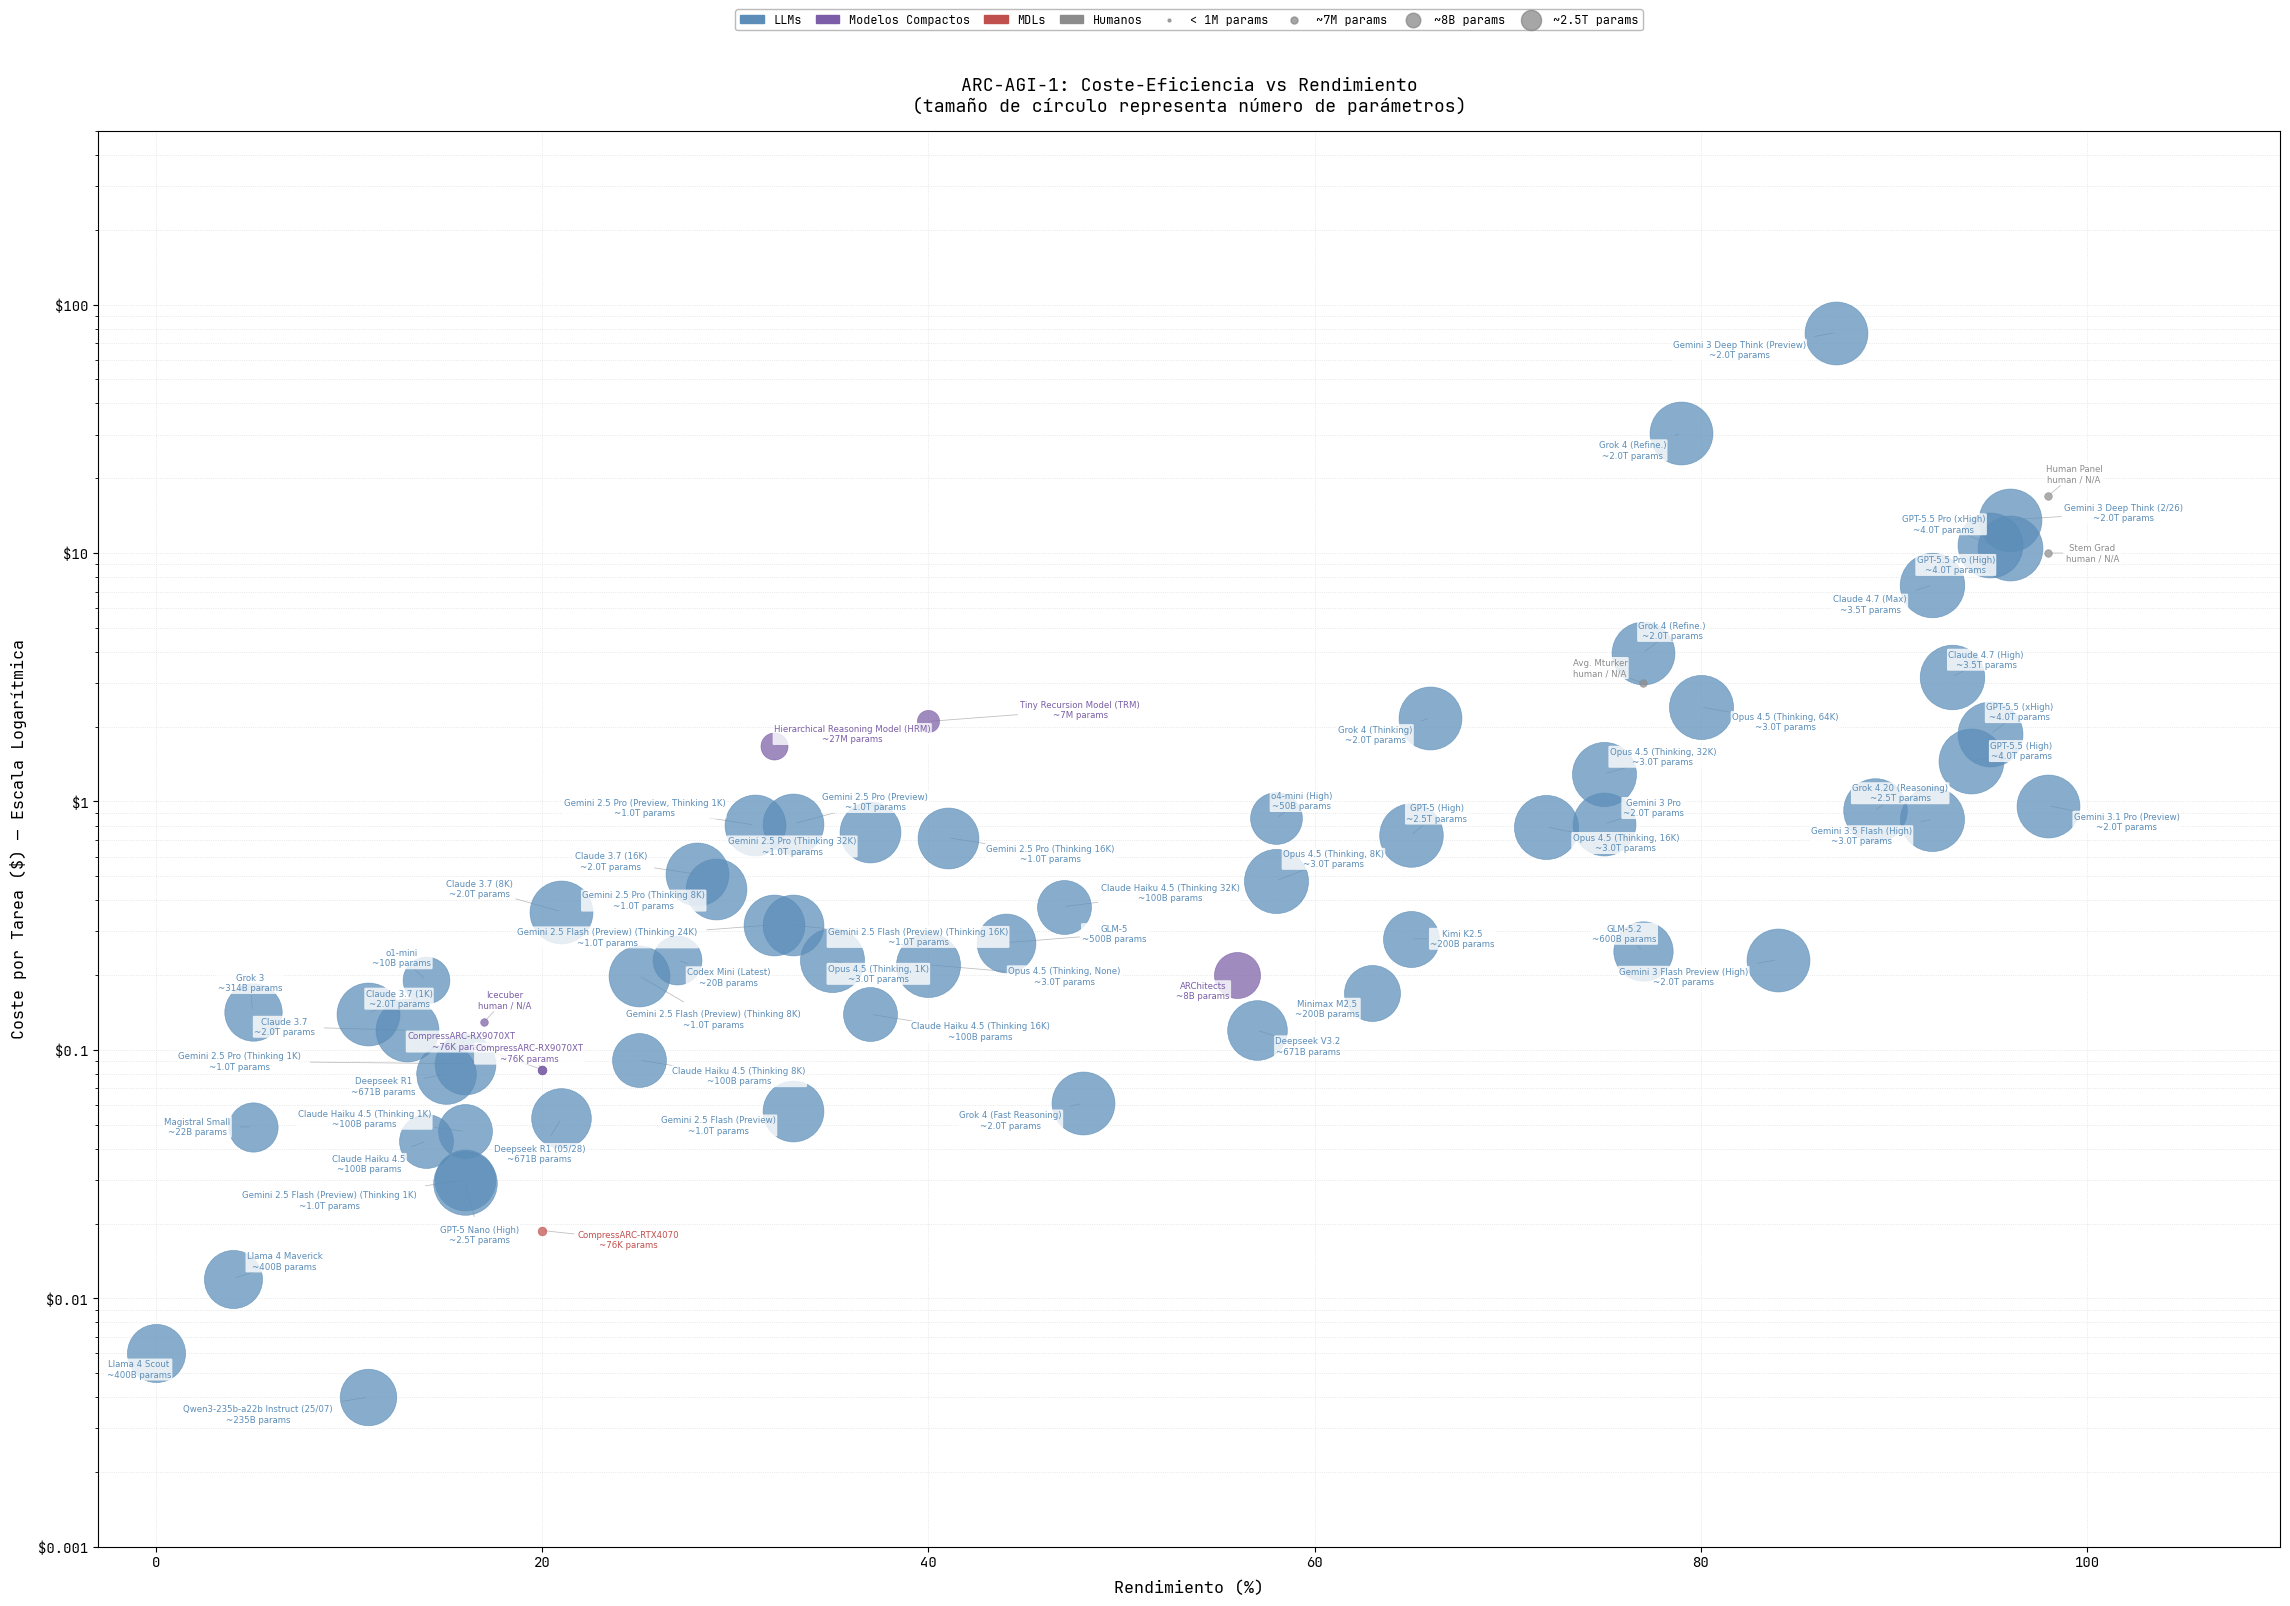

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/parameters_models_cost_dark.png


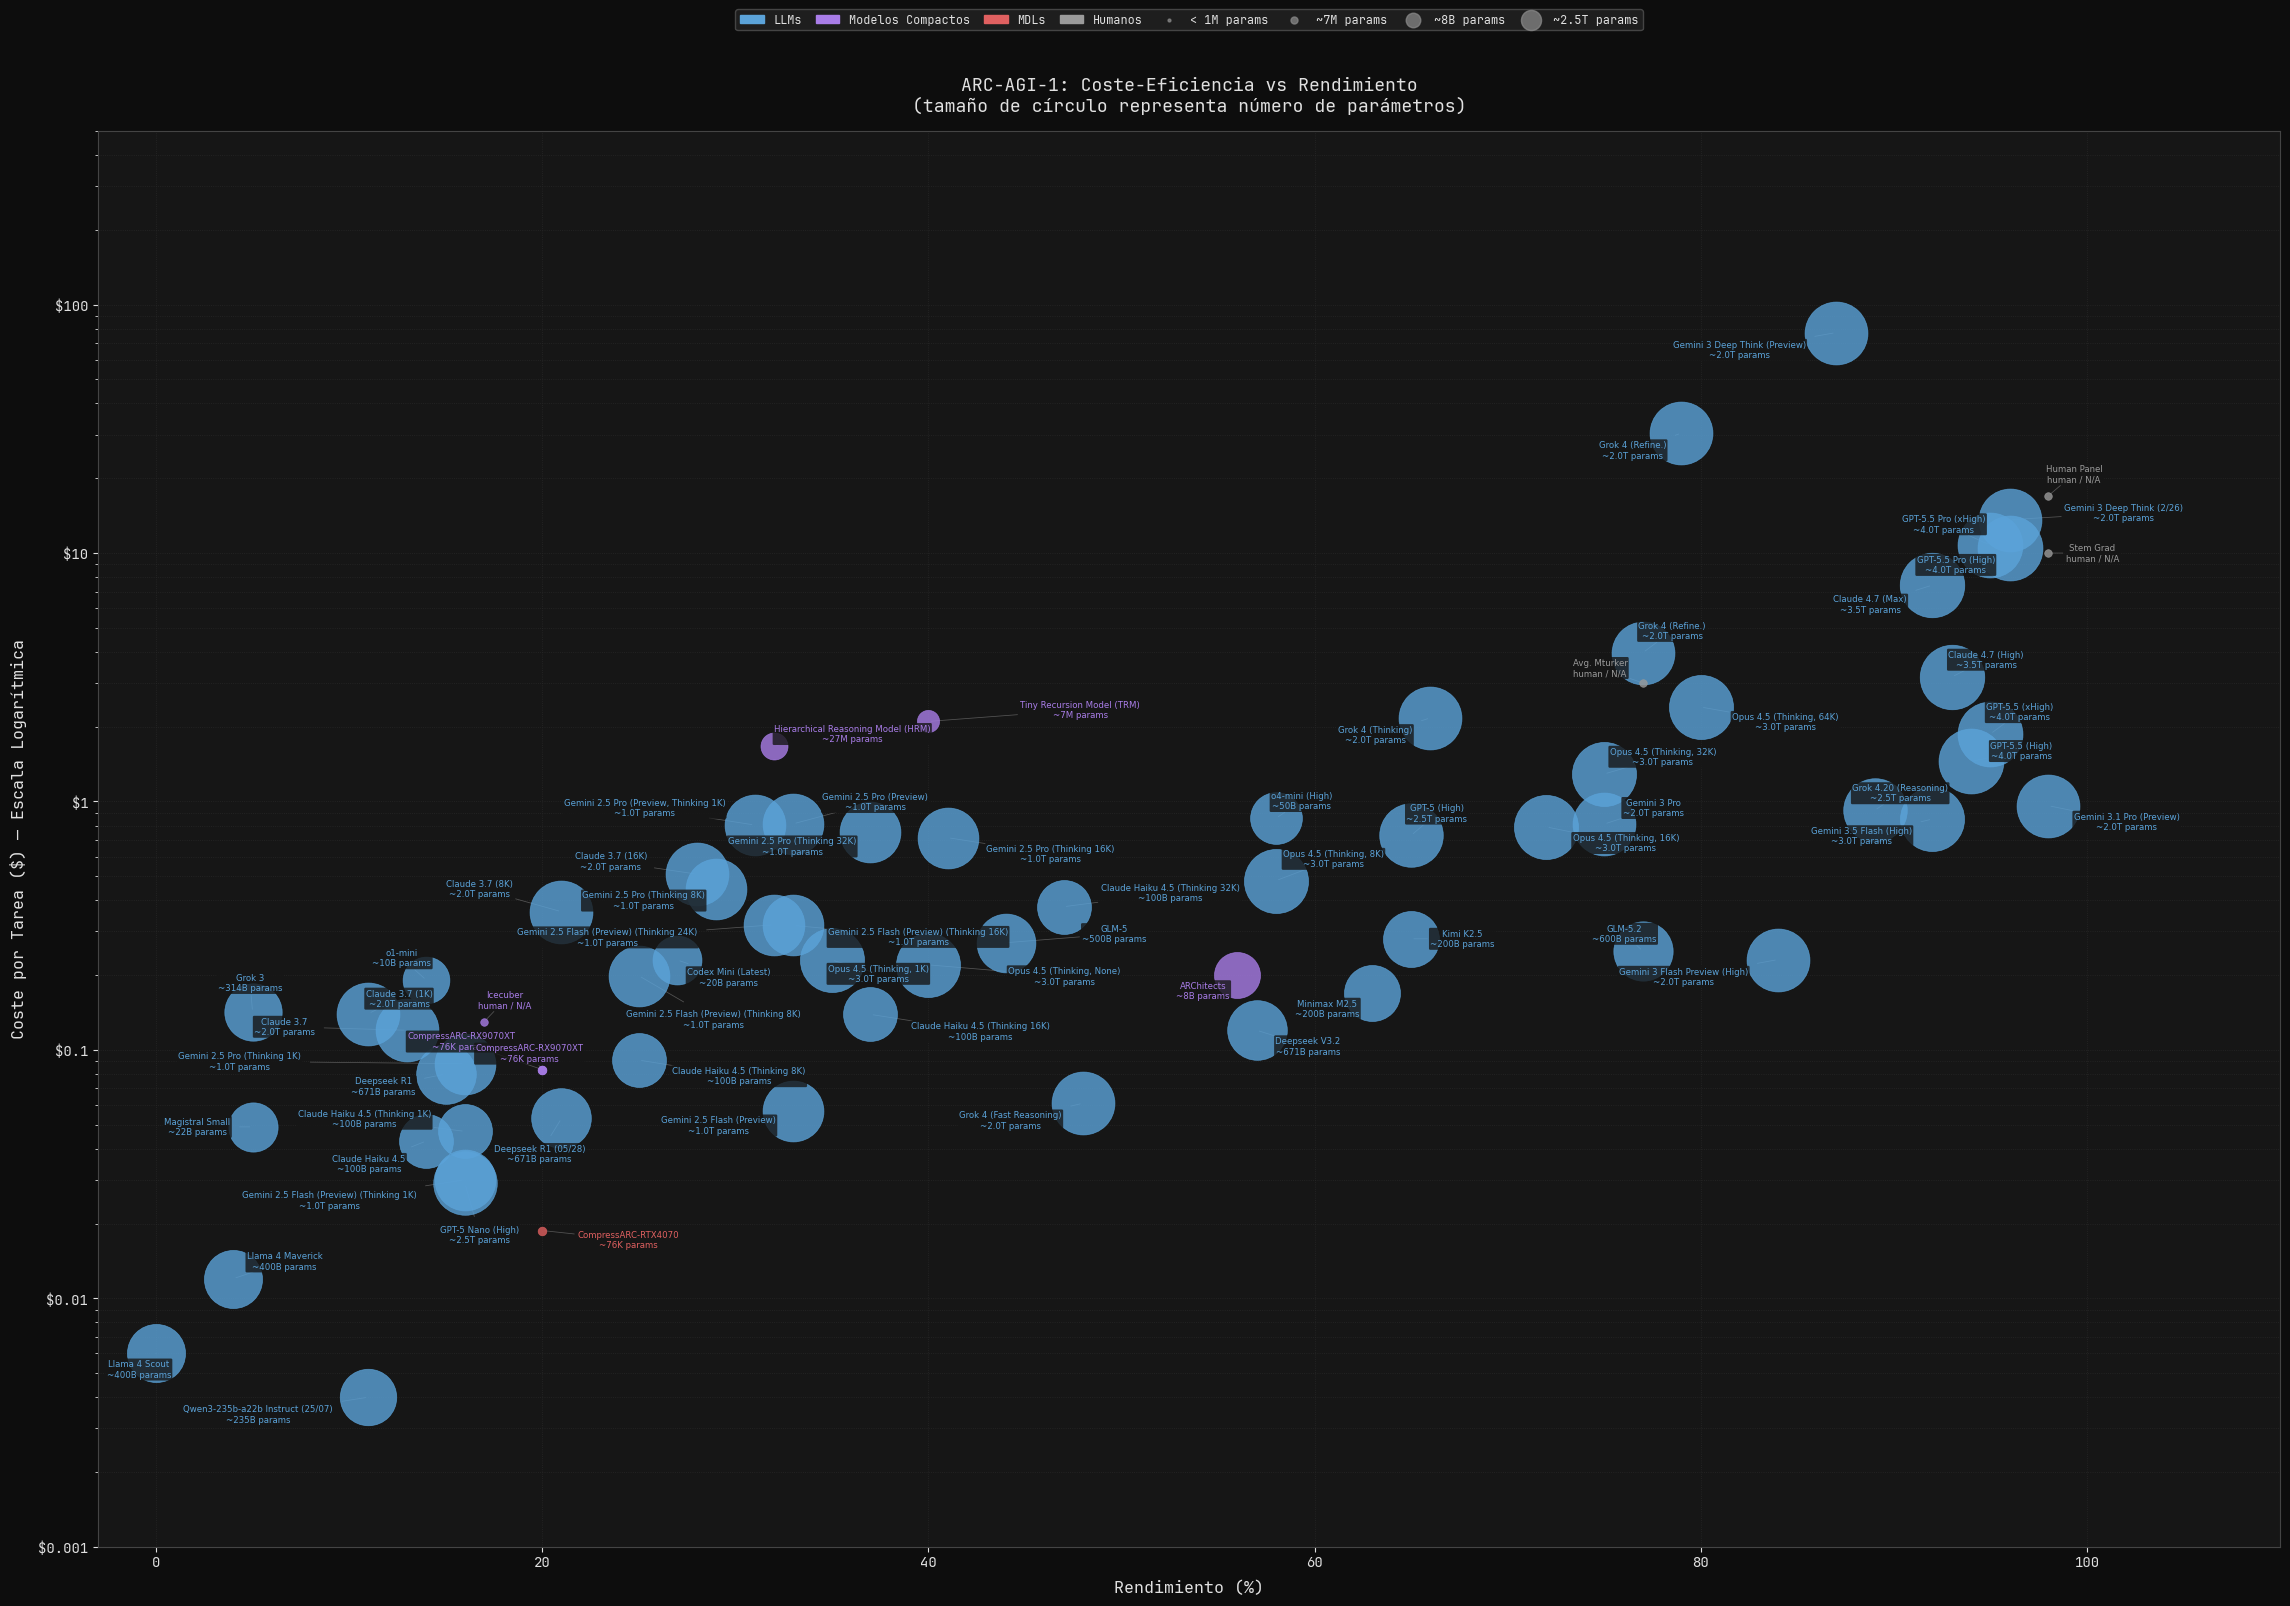

In [56]:
def plot_bubble_chart(df, theme='light', save_path=None):
    """
    Plot ARC-AGI-1 cost-efficiency vs performance bubble chart.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain: arc_agi_1, cost_per_task, parameters_in_millions,
        author, model, solution_type.
    theme : {'light', 'dark'}
    """
    if theme == 'dark':
        BG_COLOR     = '#0D0D0D';  PANEL_COLOR  = '#161616'
        GRID_COLOR   = '#2A2A2A';  TEXT_COLOR   = '#E0E0E0';  SPINE_COLOR = '#444444'
        MUTED_BLUE   = '#5BA3D9';  GREY_COL     = '#9A9A9A'
        PURPLE_COL   = '#A97DE8';  MUTED_RED    = '#E06060'
        ARROW_COLOR  = '#555555';  BBOX_FC = '#161616'
        LEG_FC = '#1E1E1E';        LEG_EC = '#444444';         LEG_LC = '#E0E0E0'
        BUBBLE_ALPHA = 0.80
    else:
        BG_COLOR     = 'white';    PANEL_COLOR  = 'white'
        GRID_COLOR   = '#DCDCDC';  TEXT_COLOR   = 'black';    SPINE_COLOR = 'black'
        MUTED_BLUE   = '#5B8DB8';  GREY_COL     = '#8C8C8C'
        PURPLE_COL   = '#7B5EA7';  MUTED_RED    = '#C0504D'
        ARROW_COLOR  = '#BBBBBB';  BBOX_FC = 'white'
        LEG_FC = 'white';          LEG_EC = '#BBBBBB';         LEG_LC = 'black'
        BUBBLE_ALPHA = 0.72

    df_plot = df.dropna(subset=['cost_per_task', 'arc_agi_1']).copy()
    df_plot = df_plot[df_plot['cost_per_task'] > 0].reset_index(drop=True)

    def fmt_params(p):
        if pd.isna(p) or p == 0:  return "human / N/A"
        if p < 1:                  return f"~{p * 1000:.0f}K params"
        if p < 1_000:              return f"~{int(p)}M params"
        if p < 1_000_000:          return f"~{p / 1_000:.0f}B params"
        return f"~{p / 1_000_000:.1f}T params"

    def bubble_size(p):
        if pd.isna(p) or p <= 0:  return 30
        v = (np.log10(p + 0.1) + 1) / 7.7
        return 30 + v ** 1.6 * 2200

    def get_color(row):
        if row['author'] == 'Human':             return GREY_COL
        if row['model'] == 'CompressARC-RTX4070':         return MUTED_RED
        if row.get('solution_type') == 'Custom':  return PURPLE_COL
        return MUTED_BLUE

    df_plot['bsize']  = df_plot['parameters_in_millions'].apply(bubble_size)
    df_plot['plabel'] = df_plot['parameters_in_millions'].apply(fmt_params)
    df_plot['color']  = df_plot.apply(get_color, axis=1)

    plt.rcParams['font.family'] = 'JetBrains Mono NL'

    fig, ax = plt.subplots(figsize=(23, 16))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(PANEL_COLOR)
    ax.grid(True, which='both', linestyle=':', color=GRID_COLOR, linewidth=0.6, alpha=0.85)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8);  spine.set_color(SPINE_COLOR)
    ax.tick_params(colors=TEXT_COLOR, which='both')
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

    for _, row in df_plot.iterrows():
        ax.scatter(row['arc_agi_1'], row['cost_per_task'],
                s=row['bsize'], c=row['color'],
                alpha=BUBBLE_ALPHA, edgecolors=row['color'], linewidths=0.5, zorder=4)

    ax.set_xlim(-3, 110);  ax.set_xticks(range(0, 101, 20))
    ax.set_xlabel('Rendimiento (%)', fontsize=12, labelpad=8)
    ax.set_yscale('log');  ax.set_ylim(0.002, 500)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:g}'))
    ax.set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
    ax.set_ylabel('Coste por Tarea ($) — Escala Logarítmica', fontsize=12, labelpad=8)
    ax.set_title('ARC-AGI-1: Coste-Eficiencia vs Rendimiento\n(tamaño de círculo representa número de parámetros)',
                fontsize=13, pad=14)

    # offset_x_pool    = [28, -32, 28, -32, 20, -24, 32, -28, 16, -20]
    # offset_y_factors = [2.5, 0.4, 5.0, 0.2, 1.5, 0.6, 3.5, 0.3, 8.0, 0.15]
    # for i, (_, row) in enumerate(df_plot.iterrows()):
    #     x, y = row['arc_agi_1'], row['cost_per_task']
    #     ox   = offset_x_pool[i % len(offset_x_pool)]
    #     tyf  = offset_y_factors[i % len(offset_y_factors)]
    #     if x > 80 and ox > 0:  ox = -abs(ox)
    #     if x < 10 and ox < 0:  ox =  abs(ox)
    #     ty = max(0.003, min(y * tyf, 200))
    #     ax.annotate(f"{row['model']}\n{row['plabel']}", xy=(x, y), xytext=(x + ox, ty),
    #                 fontsize=6.2, color=row['color'], fontfamily='sans-serif',
    #                 ha='left' if ox >= 0 else 'right', va='center',
    #                 arrowprops=dict(arrowstyle='-', color=ARROW_COLOR, lw=0.55, shrinkA=0, shrinkB=3),
    #                 bbox=dict(boxstyle='round,pad=0.15', fc=BBOX_FC, ec='none', alpha=0.80), zorder=5)

    texts = []
    for _, row in df_plot.iterrows():
        t = ax.text(row['arc_agi_1'], row['cost_per_task'],
                    f"{row['model']}\n{row['plabel']}",
                    fontsize=6.2, color=row['color'], fontfamily='sans-serif',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc=BBOX_FC, ec='none', alpha=0.80),
                    zorder=5)
        texts.append(t)

    adjust_text(
        texts,
        x=df_plot['arc_agi_1'].values,
        y=df_plot['cost_per_task'].values,
        arrowprops=dict(arrowstyle='-', color=ARROW_COLOR, lw=0.55),
        expand=(1.3, 1.5),   # how much to expand bounding boxes when checking overlaps
        ax=ax,
    )

    _ls = 0.10   # legend bubble scale factor — keeps icons within the legend box
    legend_handles = [
        mpatches.Patch(facecolor=MUTED_BLUE,  edgecolor=MUTED_BLUE,  label='LLMs'),
        mpatches.Patch(facecolor=PURPLE_COL,  edgecolor=PURPLE_COL,  label='Modelos Compactos'),
        mpatches.Patch(facecolor=MUTED_RED,   edgecolor=MUTED_RED,   label='MDLs'),
        mpatches.Patch(facecolor=GREY_COL,    edgecolor=GREY_COL,    label='Humanos'),
        plt.scatter([], [], s=bubble_size(0.1)       * _ls, c='#888888', alpha=0.75, label='< 1M params'),
        plt.scatter([], [], s=bubble_size(7)         * _ls, c='#888888', alpha=0.75, label='~7M params'),
        plt.scatter([], [], s=bubble_size(8_000)     * _ls, c='#888888', alpha=0.75, label='~8B params'),
        plt.scatter([], [], s=bubble_size(2_500_000) * _ls, c='#888888', alpha=0.75, label='~2.5T params'),
    ]
    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.09),
            ncol=8, fontsize=8.5, frameon=True, fancybox=True, edgecolor=LEG_EC,
            framealpha=1.0, columnspacing=1.2, labelcolor=LEG_LC, facecolor=LEG_FC)
    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path, 
            dpi=800,                  # High resolution for presentations/papers
            bbox_inches='tight',      # Prevents labels from getting cut off
            facecolor=fig.get_facecolor() # Preserves your dark/light background color
        )
    print(f"Plot saved successfully to: {save_path}")
    
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
# Save the light theme version
parameters_light_image_path = output_folder / "parameters_models_cost_light.png"

# Save the dark theme version
parameters_dark_image_path = output_folder / "parameters_models_cost_dark.png"


plot_bubble_chart(df_saved_only_arc_1, theme='light', save_path=parameters_light_image_path)
plot_bubble_chart(df_saved_only_arc_1, theme='dark', save_path=parameters_dark_image_path)

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/tflops_models_cost_light.png


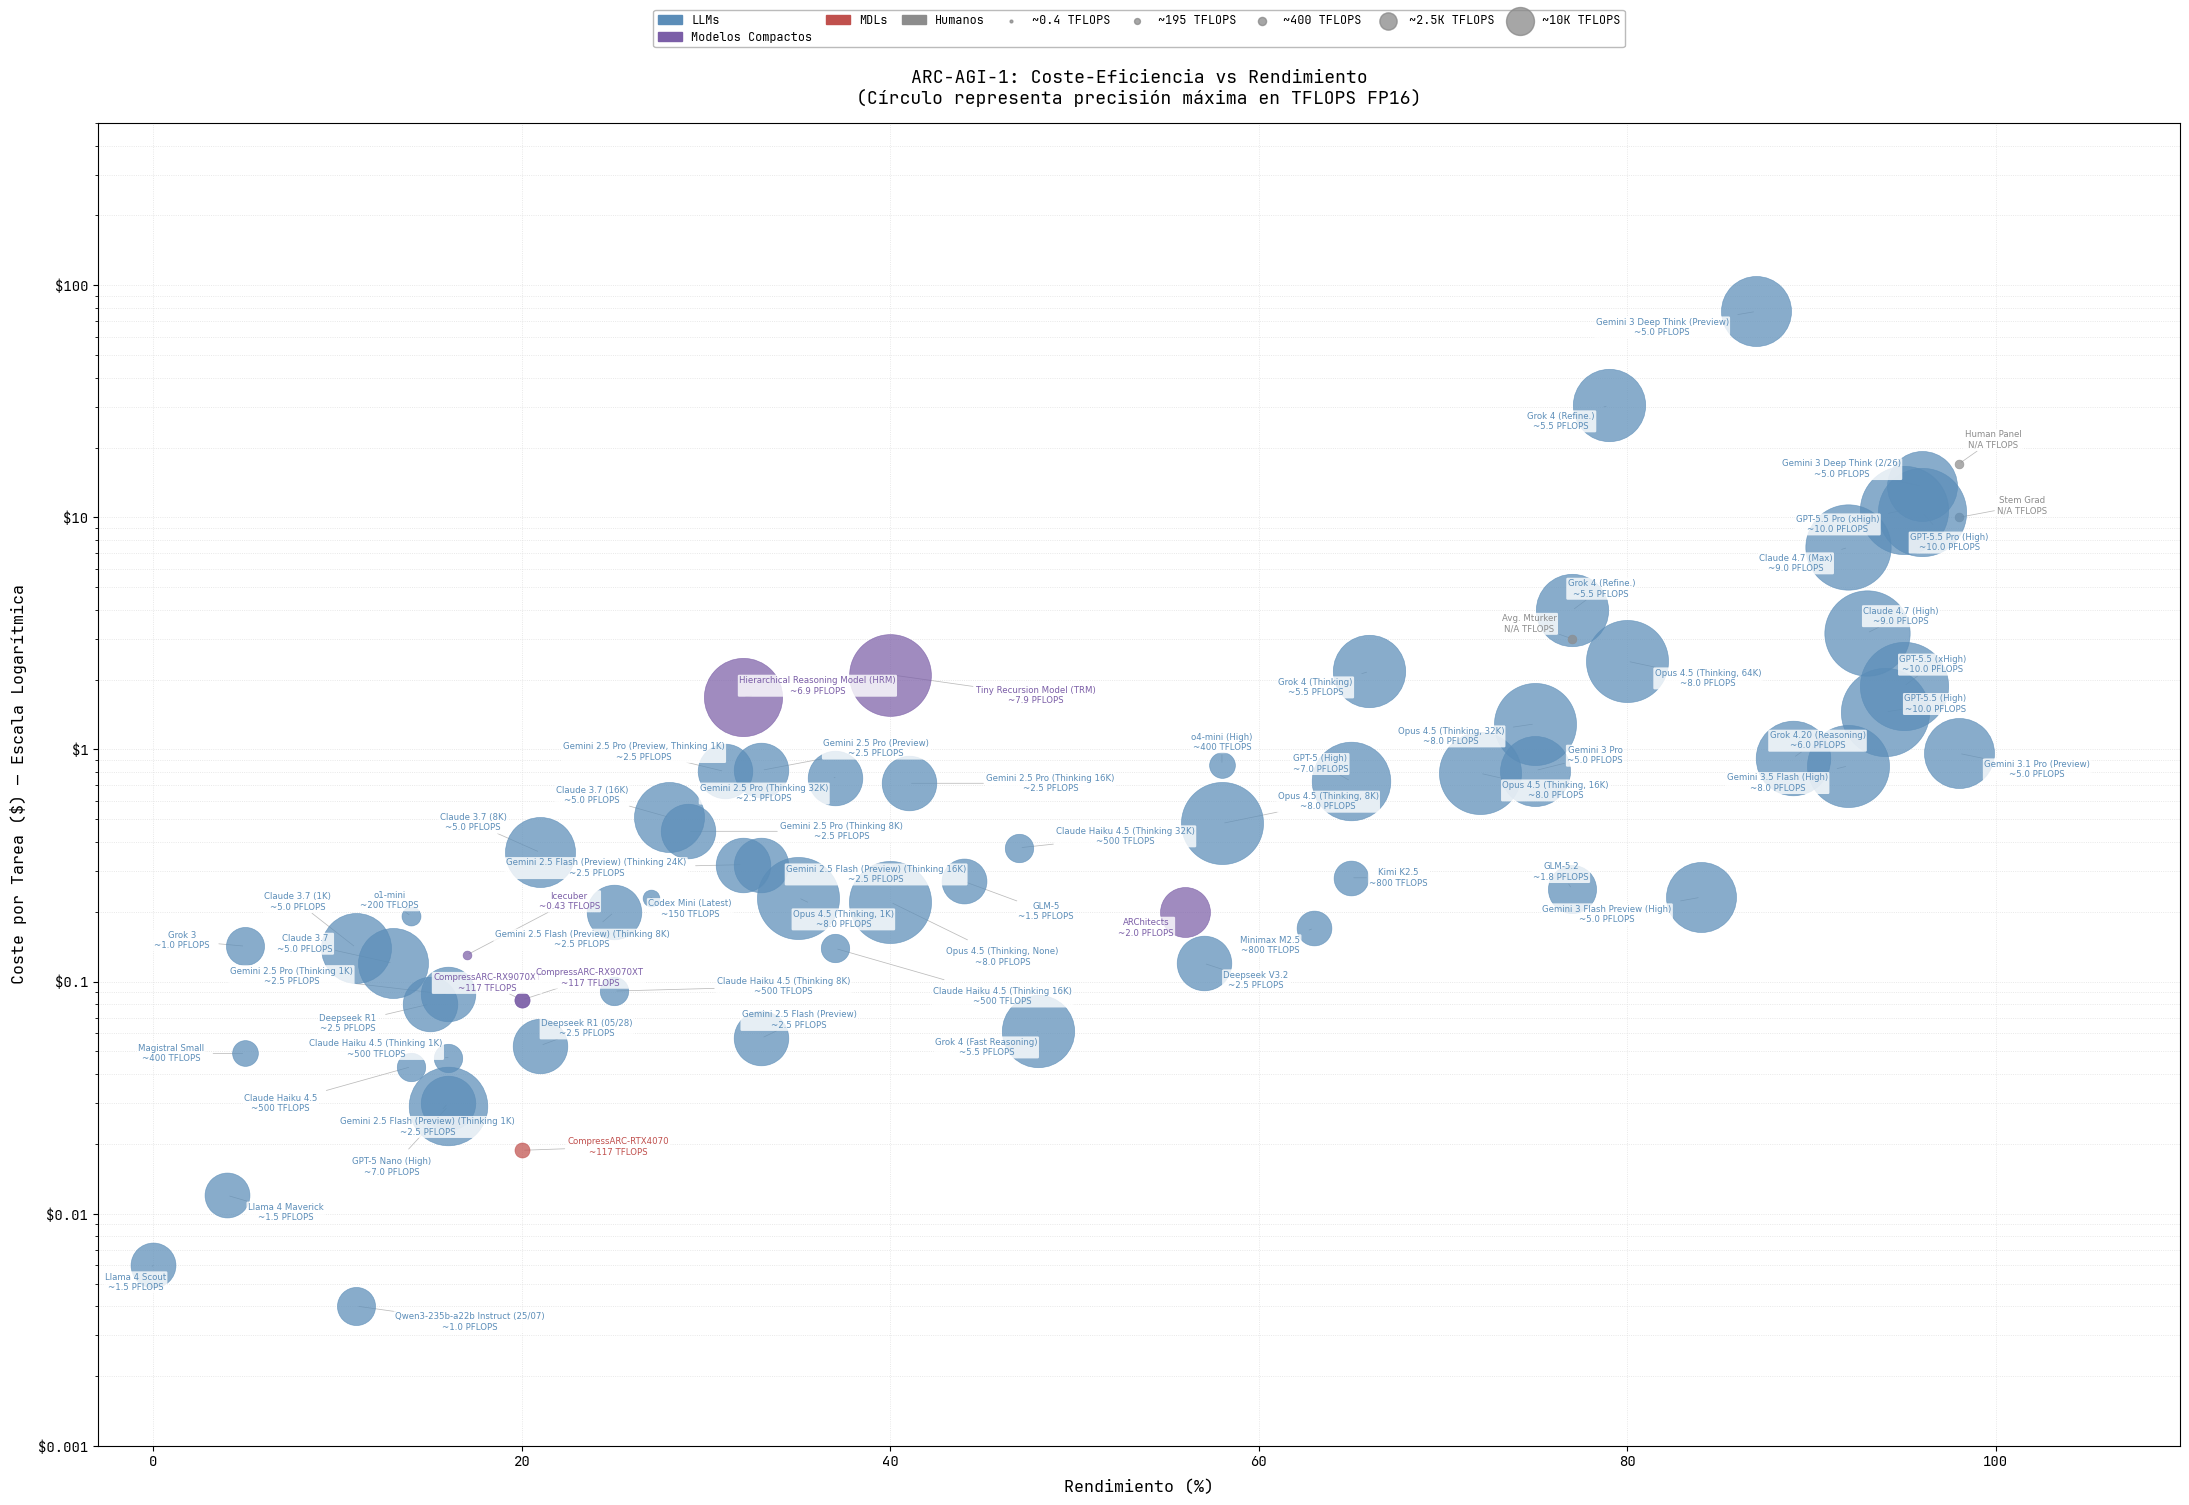

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/tflops_models_cost_dark.png


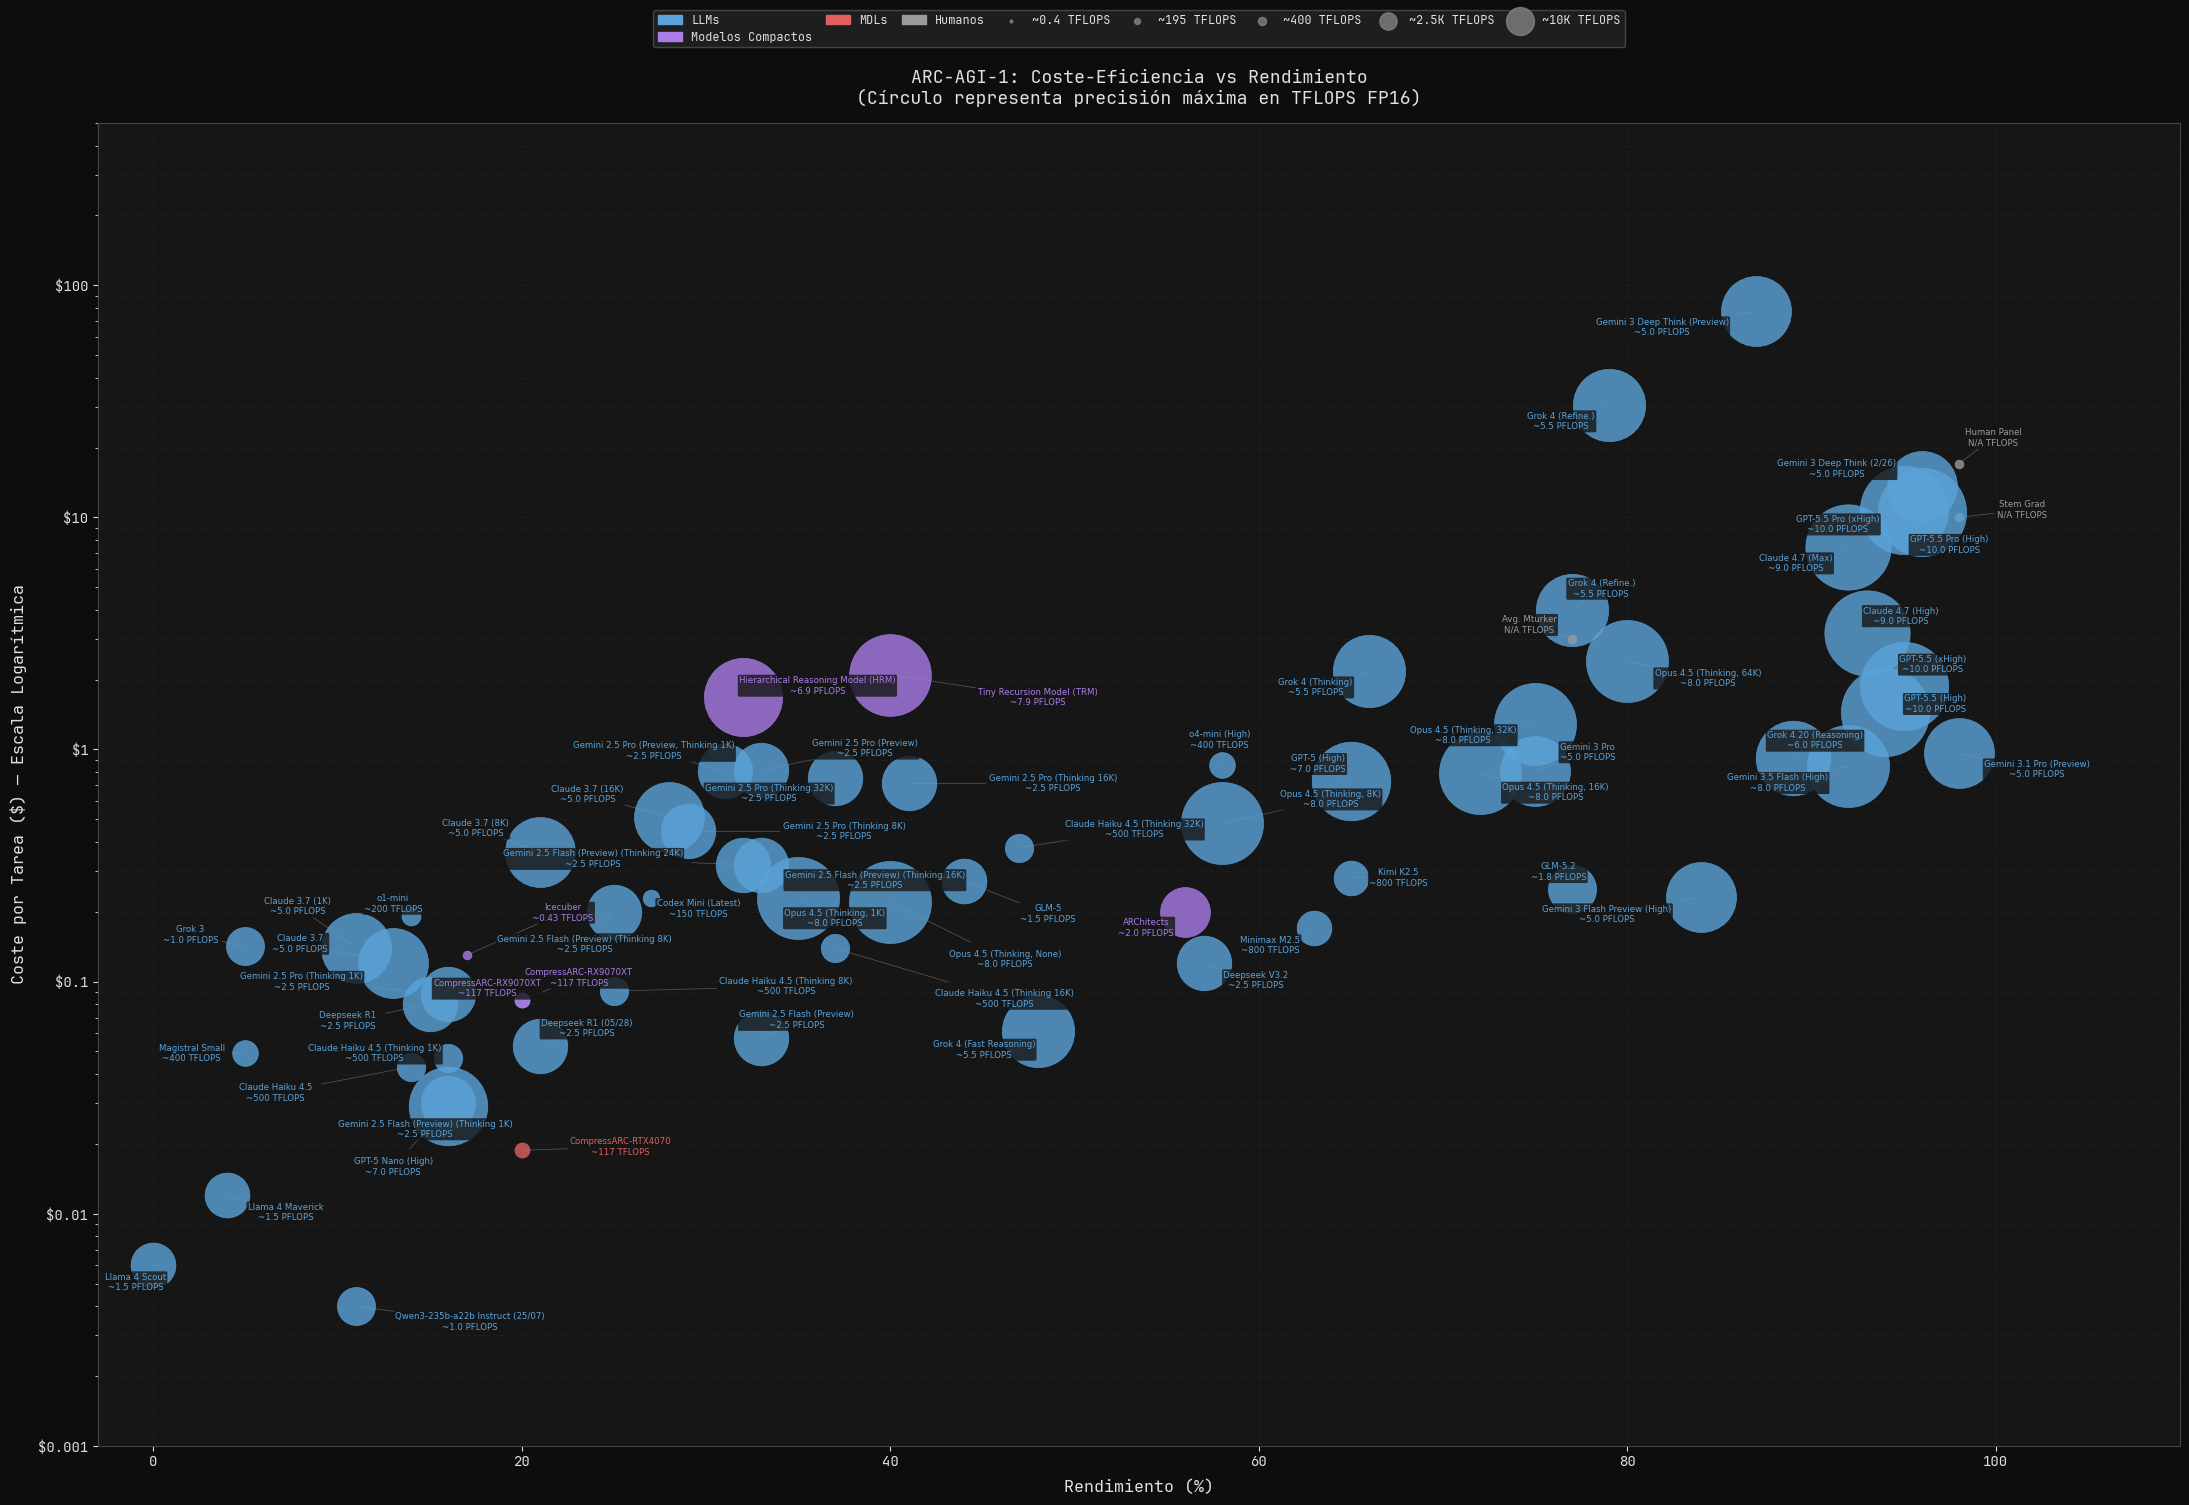

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/tflops_models_cost_light_large_font.png


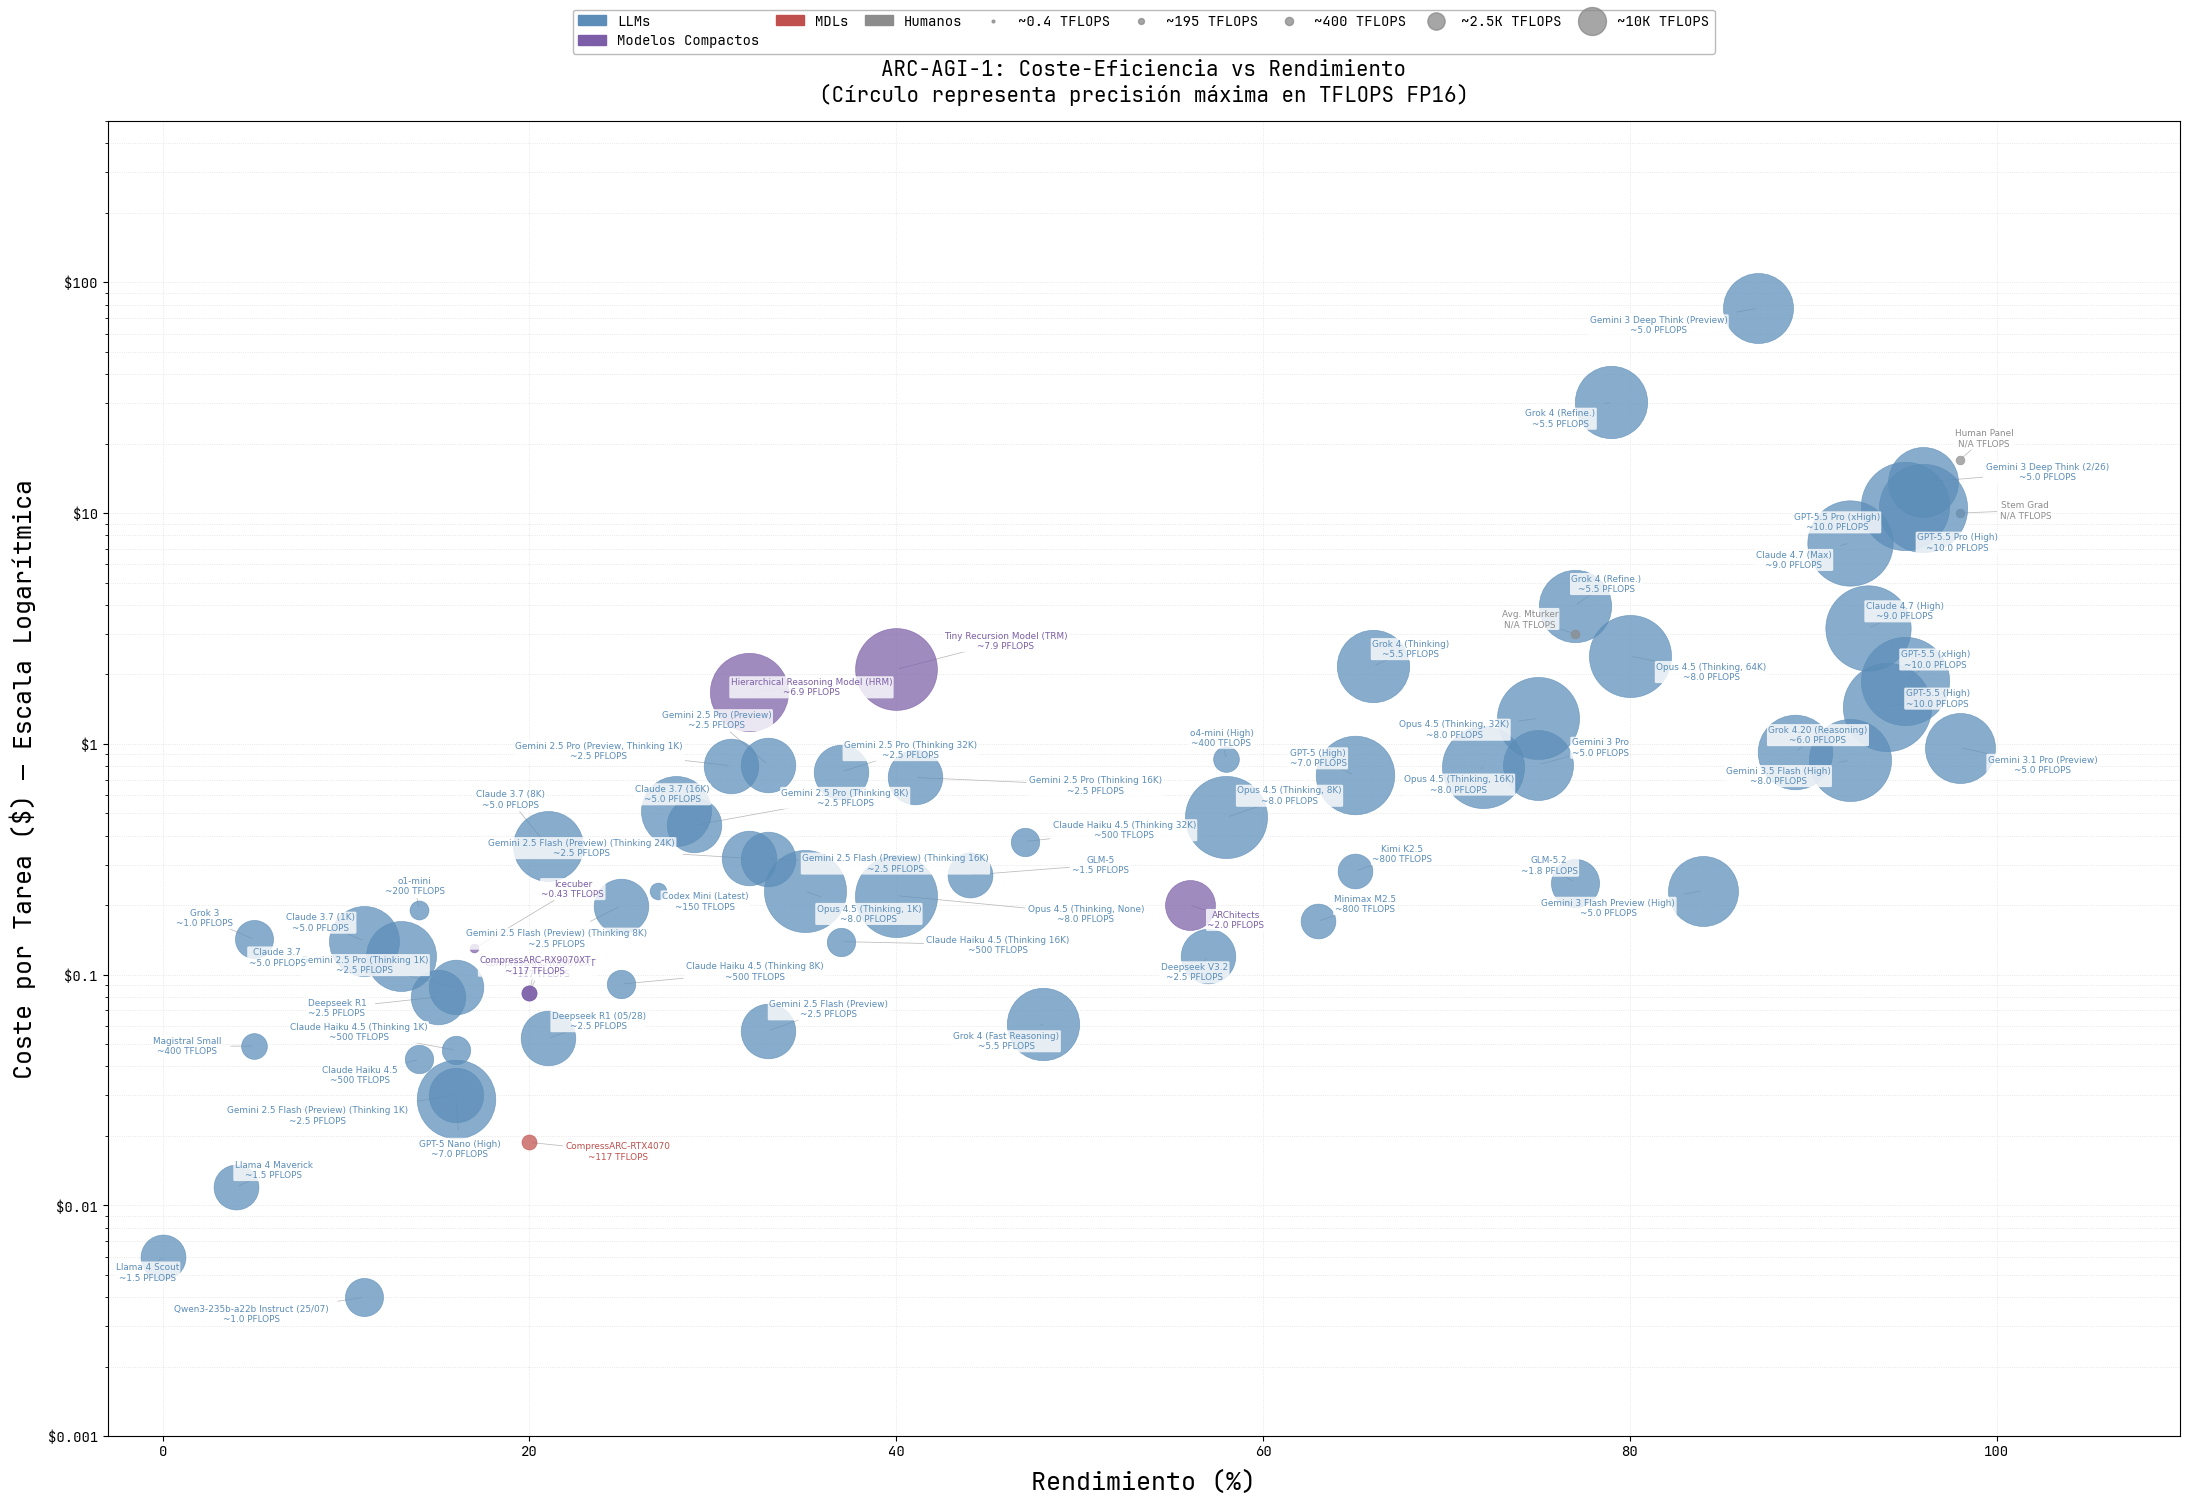

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/tflops_models_cost_dark_large_font.png


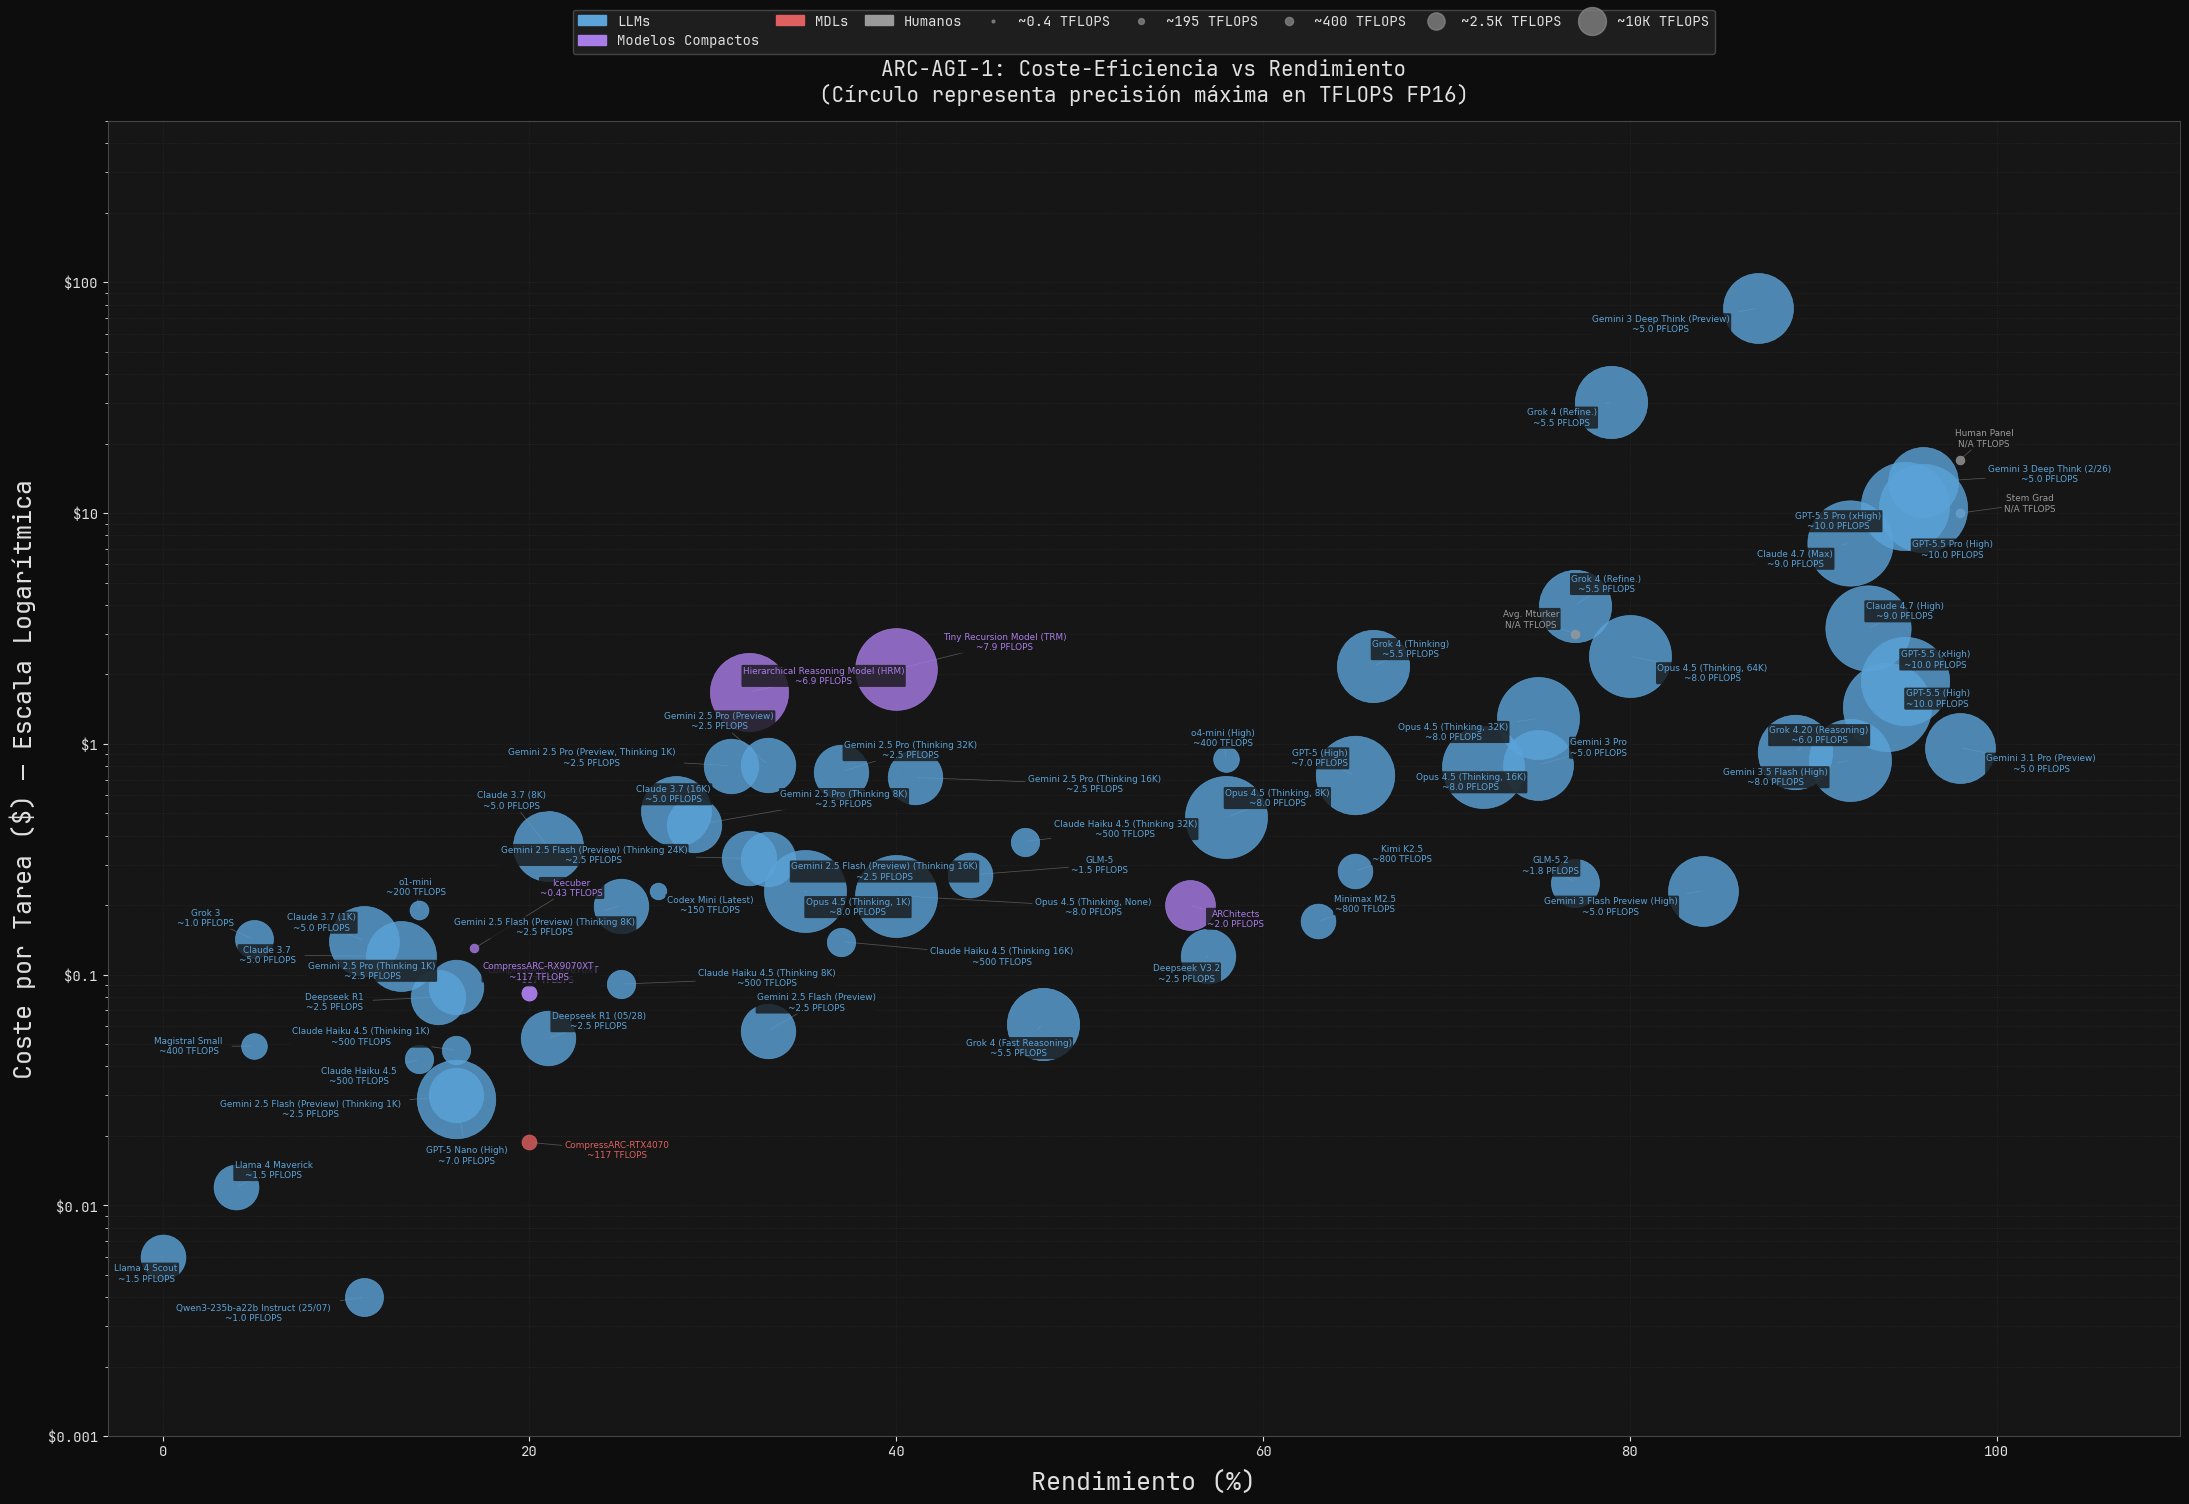

In [57]:
def plot_tflops_bubble_chart(df, theme='light', save_path=None, font_size_title=13, font_size_labels=12, font_size_legend=8.5, font_size_annotation=6.2):
    """
    Plot ARC-AGI-1 cost-efficiency vs performance bubble chart.
    Bubble size represents peak precision (TFLOPS FP16).

    Parameters
    ----------
    df : pd.DataFrame
        Must contain: arc_agi_1, cost_per_task, peak_precision_tflops_fp16,
        author, model, solution_type.
    theme : {'light', 'dark'}
    """
    if theme == 'dark':
        BG_COLOR     = '#0D0D0D';  PANEL_COLOR  = '#161616'
        GRID_COLOR   = '#2A2A2A';  TEXT_COLOR   = '#E0E0E0';  SPINE_COLOR = '#444444'
        MUTED_BLUE   = '#5BA3D9';  GREY_COL     = '#9A9A9A'
        PURPLE_COL   = '#A97DE8';  MUTED_RED    = '#E06060'
        ARROW_COLOR  = '#555555';  BBOX_FC = '#161616'
        LEG_FC = '#1E1E1E';        LEG_EC = '#444444';         LEG_LC = '#E0E0E0'
        BUBBLE_ALPHA = 0.80
    else:
        BG_COLOR     = 'white';    PANEL_COLOR  = 'white'
        GRID_COLOR   = '#DCDCDC';  TEXT_COLOR   = 'black';    SPINE_COLOR = 'black'
        MUTED_BLUE   = '#5B8DB8';  GREY_COL     = '#8C8C8C'
        PURPLE_COL   = '#7B5EA7';  MUTED_RED    = '#C0504D'
        ARROW_COLOR  = '#BBBBBB';  BBOX_FC = 'white'
        LEG_FC = 'white';          LEG_EC = '#BBBBBB';         LEG_LC = 'black'
        BUBBLE_ALPHA = 0.72

    # ── Prepare data ──────────────────────────────────────────────────────────
    df_plot = df.dropna(subset=['cost_per_task', 'arc_agi_1']).copy()
    df_plot = df_plot[df_plot['cost_per_task'] > 0].reset_index(drop=True)

    def fmt_tflops(t):
        if pd.isna(t) or t == 0:  return "N/A TFLOPS"
        if t < 1:                  return f"~{t:.2f} TFLOPS"
        if t < 1_000:              return f"~{t:.0f} TFLOPS"
        return f"~{t / 1_000:.1f} PFLOPS"

    # def bubble_size(t):
    #     if pd.isna(t) or t <= 0:  return 25
    #     v = np.log10(t + 1) / 4.0   # normalise [0,1] — max ~10K TFLOPS
    #     # return 25 + v ** 1.4 * 2400
    #     # return 25 + v ** 2.5 * 2400
    #     return 25 + v ** 4.0 * 3500
    def bubble_size(t):
        if pd.isna(t) or t <= 0:  return 40   # raised floor for visibility
        v = np.log10(t + 1) / 4.0
        return 40 + v ** 6.0 * 4000

    def get_color(row):
        if row['author'] == 'Human':             return GREY_COL
        if row['model'] == 'CompressARC-RTX4070':         return MUTED_RED
        if row.get('solution_type') == 'Custom':  return PURPLE_COL
        return MUTED_BLUE

    df_plot['bsize']  = df_plot['peak_precision_tflops_fp16'].apply(bubble_size)
    df_plot['tlabel'] = df_plot['peak_precision_tflops_fp16'].apply(fmt_tflops)
    df_plot['color']  = df_plot.apply(get_color, axis=1)

    plt.rcParams['font.family'] = 'JetBrains Mono NL'

    # ── Figure / axes ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(22, 15))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(PANEL_COLOR)
    ax.grid(True, which='both', linestyle=':', color=GRID_COLOR, linewidth=0.6, alpha=0.85)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8);  spine.set_color(SPINE_COLOR)
    ax.tick_params(colors=TEXT_COLOR, which='both')
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

    # ── Scatter bubbles ───────────────────────────────────────────────────────
    for _, row in df_plot.iterrows():
        ax.scatter(row['arc_agi_1'], row['cost_per_task'],
                s=row['bsize'], c=row['color'],
                alpha=BUBBLE_ALPHA, edgecolors=row['color'], linewidths=0.5, zorder=4)

    # ── Axes config ───────────────────────────────────────────────────────────
    ax.set_xlim(-3, 110);  ax.set_xticks(range(0, 101, 20))
    ax.set_xlabel('Rendimiento (%)', fontsize=font_size_labels, labelpad=8)
    ax.set_yscale('log');  ax.set_ylim(0.002, 500)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:g}'))
    ax.set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
    ax.set_ylabel('Coste por Tarea ($) — Escala Logarítmica', fontsize=font_size_labels, labelpad=8)
    ax.set_title(
        'ARC-AGI-1: Coste-Eficiencia vs Rendimiento\n'
        '(Círculo representa precisión máxima en TFLOPS FP16)',
        fontsize=font_size_title, pad=14
    )

    # ── Annotations with leader lines ─────────────────────────────────────────
    # offset_x_pool    = [28, -32, 28, -32, 20, -24, 32, -28, 16, -20]
    # offset_y_factors = [2.5, 0.4, 5.0, 0.2, 1.5, 0.6, 3.5, 0.3, 8.0, 0.15]
    # for i, (_, row) in enumerate(df_plot.iterrows()):
    #     x, y = row['arc_agi_1'], row['cost_per_task']
    #     ox   = offset_x_pool[i % len(offset_x_pool)]
    #     tyf  = offset_y_factors[i % len(offset_y_factors)]
    #     if x > 80 and ox > 0:  ox = -abs(ox)
    #     if x < 10 and ox < 0:  ox =  abs(ox)
    #     ty = max(0.003, min(y * tyf, 200))
    #     ax.annotate(f"{row['model']}\n{row['tlabel']}", xy=(x, y), xytext=(x + ox, ty),
    #                 fontsize=6.2, color=row['color'], fontfamily='sans-serif',
    #                 ha='left' if ox >= 0 else 'right', va='center',
    #                 arrowprops=dict(arrowstyle='-', color=ARROW_COLOR, lw=0.55, shrinkA=0, shrinkB=3),
    #                 bbox=dict(boxstyle='round,pad=0.15', fc=BBOX_FC, ec='none', alpha=0.80), zorder=5)

    texts = []
    for _, row in df_plot.iterrows():
        t = ax.text(row['arc_agi_1'], row['cost_per_task'],
                    f"{row['model']}\n{row['tlabel']}",
                    fontsize=font_size_annotation, color=row['color'], fontfamily='sans-serif',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc=BBOX_FC, ec='none', alpha=0.80),
                    zorder=5)
        texts.append(t)

    adjust_text(
        texts,
        x=df_plot['arc_agi_1'].values,
        y=df_plot['cost_per_task'].values,
        arrowprops=dict(arrowstyle='-', color=ARROW_COLOR, lw=0.55),
        expand=(1.3, 1.5),   # how much to expand bounding boxes when checking overlaps
        ax=ax,
    )

    # ── Legend ────────────────────────────────────────────────────────────────
    _ls = 0.10   # legend bubble scale factor — keeps icons within the legend box
    # legend_handles = [
    #     mpatches.Patch(facecolor=MUTED_BLUE,  edgecolor=MUTED_BLUE,  label='ARC-AGI-1 (LLM)'),
    #     mpatches.Patch(facecolor=PURPLE_COL,  edgecolor=PURPLE_COL,  label='Custom solution'),
    #     mpatches.Patch(facecolor=MUTED_RED,   edgecolor=MUTED_RED,   label='CompressARC-RTX4070'),
    #     mpatches.Patch(facecolor=GREY_COL,    edgecolor=GREY_COL,    label='Human Baseline'),
    #     plt.scatter([], [], s=bubble_size(0.43)  * _ls, c='#888888', alpha=0.75, label='~0.4 TFLOPS'),
    #     plt.scatter([], [], s=bubble_size(400)   * _ls, c='#888888', alpha=0.75, label='~400 TFLOPS'),
    #     plt.scatter([], [], s=bubble_size(2500)  * _ls, c='#888888', alpha=0.75, label='~2.5K TFLOPS'),
    #     plt.scatter([], [], s=bubble_size(10000) * _ls, c='#888888', alpha=0.75, label='~10K TFLOPS'),
    # ]
    legend_handles = [
        mpatches.Patch(facecolor=MUTED_BLUE,  edgecolor=MUTED_BLUE,  label='LLMs'),
        mpatches.Patch(facecolor=PURPLE_COL,  edgecolor=PURPLE_COL,  label='Modelos Compactos'),
        mpatches.Patch(facecolor=MUTED_RED,   edgecolor=MUTED_RED,   label='MDLs'),
        mpatches.Patch(facecolor=GREY_COL,    edgecolor=GREY_COL,    label='Humanos'),
        plt.scatter([], [], s=bubble_size(0.43)  * _ls, c='#888888', alpha=0.75, label='~0.4 TFLOPS'),
        plt.scatter([], [], s=bubble_size(195)   * _ls, c='#888888', alpha=0.75, label='~195 TFLOPS'),  # ← new
        plt.scatter([], [], s=bubble_size(400)   * _ls, c='#888888', alpha=0.75, label='~400 TFLOPS'),
        plt.scatter([], [], s=bubble_size(2500)  * _ls, c='#888888', alpha=0.75, label='~2.5K TFLOPS'),
        plt.scatter([], [], s=bubble_size(10000) * _ls, c='#888888', alpha=0.75, label='~10K TFLOPS'),
    ]   
    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.09),
            ncol=8, fontsize=font_size_legend, frameon=True, fancybox=True, edgecolor=LEG_EC,
            framealpha=1.0, columnspacing=1.2, labelcolor=LEG_LC, facecolor=LEG_FC)
    plt.tight_layout()
    if save_path:
        plt.savefig(
            save_path, 
            dpi=800,                  # High resolution for presentations/papers
            bbox_inches='tight',      # Prevents labels from getting cut off
            facecolor=fig.get_facecolor() # Preserves your dark/light background color
        )
        print(f"Plot saved successfully to: {save_path}")
    
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
# Save the light theme version
light_image_path = output_folder / "tflops_models_cost_light.png"

# Save the dark theme version
dark_image_path = output_folder / "tflops_models_cost_dark.png"

plot_tflops_bubble_chart(df_saved_only_arc_1, theme='light', save_path=light_image_path)
plot_tflops_bubble_chart(df_saved_only_arc_1, theme='dark', save_path=dark_image_path)

## With bigger font sizes for presentations
plot_tflops_bubble_chart(df_saved_only_arc_1, theme='light', save_path=output_folder / "tflops_models_cost_light_large_font.png", font_size_title=15, font_size_labels=18, font_size_legend=10, font_size_annotation=6.4)
plot_tflops_bubble_chart(df_saved_only_arc_1, theme='dark', save_path=output_folder / "tflops_models_cost_dark_large_font.png", font_size_title=15, font_size_labels=18, font_size_legend=10, font_size_annotation=6.4)


Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/compact_tflops_cost_light.png


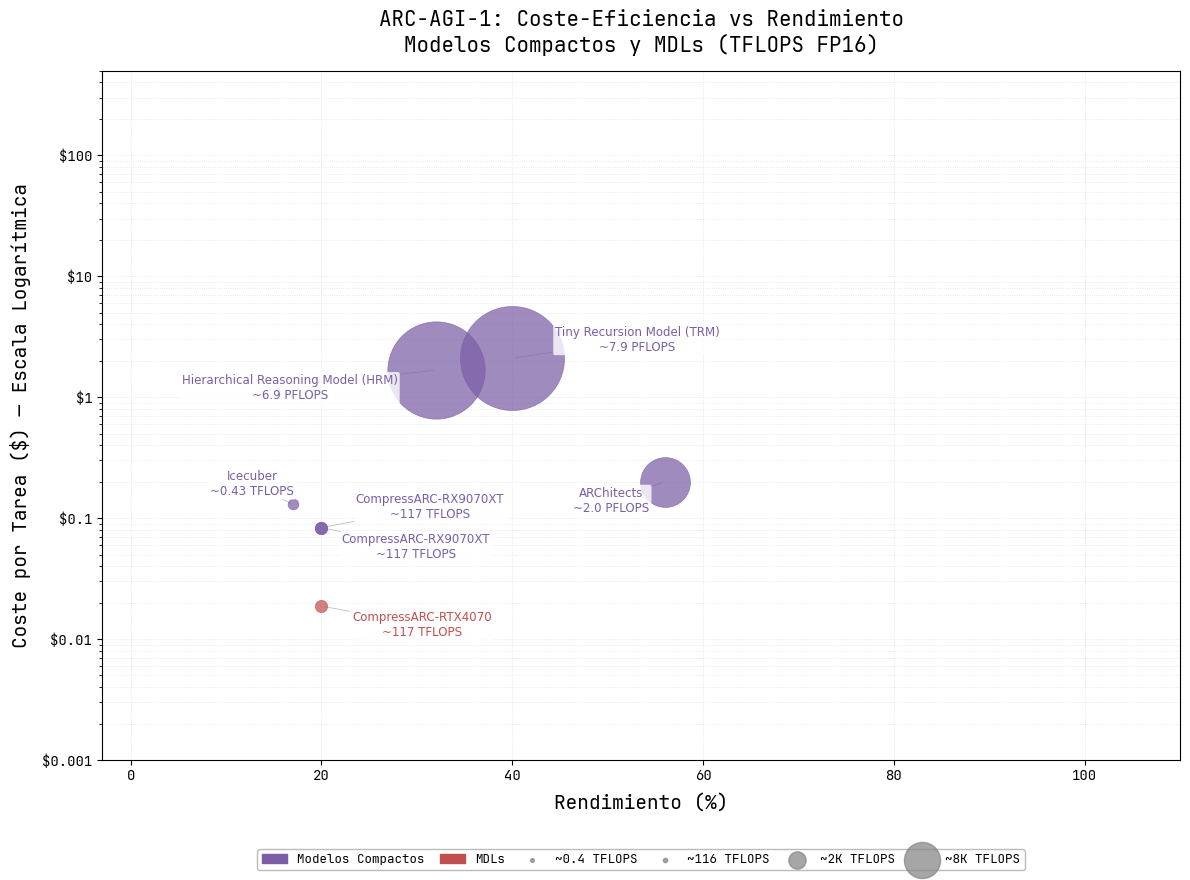

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/compact_tflops_cost_dark.png


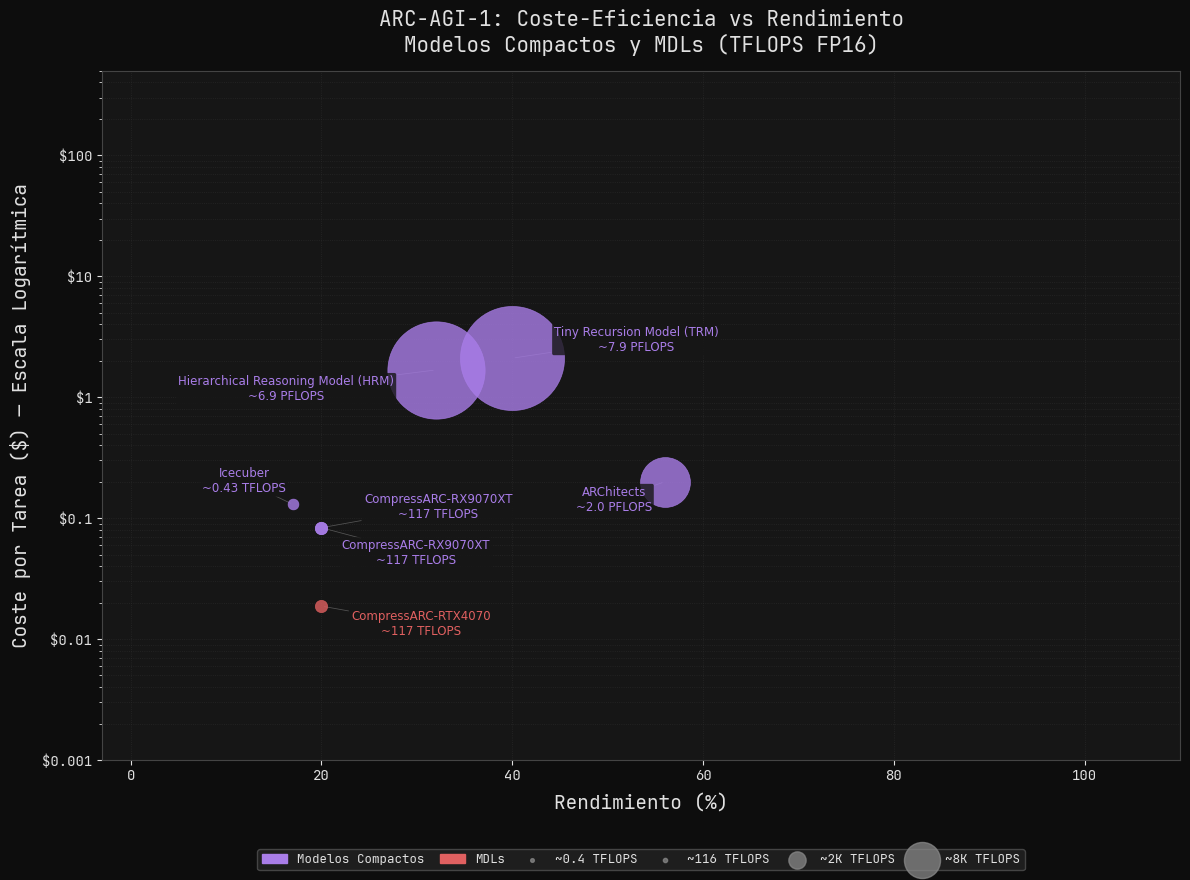

In [58]:
def plot_compact_models_tflops_bubble_chart(df, theme='light', save_path=None):
    """
    Plot ARC-AGI-1 cost-efficiency vs performance bubble chart.
    Shows only 'Modelos Compactos' (Custom solution_type) and 'MDLs' (CompressARC-RTX4070).
    Bubble size represents peak precision (TFLOPS FP16) with a more dramatic size spread.
    Parameters
    ----------
    df : pd.DataFrame
    Must contain: arc_agi_1, cost_per_task, peak_precision_tflops_fp16,
    author, model, solution_type.
    theme : {'light', 'dark'}
    """
    if theme == 'dark':
        BG_COLOR = '#0D0D0D'; PANEL_COLOR = '#161616'
        GRID_COLOR = '#2A2A2A'; TEXT_COLOR = '#E0E0E0'; SPINE_COLOR = '#444444'
        MUTED_BLUE = '#5BA3D9'; GREY_COL = '#9A9A9A'
        PURPLE_COL = '#A97DE8'; MUTED_RED = '#E06060'
        ARROW_COLOR = '#555555'; BBOX_FC = '#161616'
        LEG_FC = '#1E1E1E'; LEG_EC = '#444444'; LEG_LC = '#E0E0E0'
        BUBBLE_ALPHA = 0.80
    else:
        BG_COLOR = 'white'; PANEL_COLOR = 'white'
        GRID_COLOR = '#DCDCDC'; TEXT_COLOR = 'black'; SPINE_COLOR = 'black'
        MUTED_BLUE = '#5B8DB8'; GREY_COL = '#8C8C8C'
        PURPLE_COL = '#7B5EA7'; MUTED_RED = '#C0504D'
        ARROW_COLOR = '#BBBBBB'; BBOX_FC = 'white'
        LEG_FC = 'white'; LEG_EC = '#BBBBBB'; LEG_LC = 'black'
        BUBBLE_ALPHA = 0.72

    # ── Prepare data — filter to Custom + CompressARC-RTX4070 only ────────────────────
    df_plot = df.dropna(subset=['cost_per_task', 'arc_agi_1']).copy()
    df_plot = df_plot[df_plot['cost_per_task'] > 0]
    df_plot = df_plot[
        (df_plot['model'] == 'CompressARC-RTX4070') |
        (df_plot['solution_type'] == 'Custom')
    ].reset_index(drop=True)

    def fmt_tflops(t):
        if pd.isna(t) or t == 0:  return "N/A TFLOPS"
        if t < 1:                  return f"~{t:.2f} TFLOPS"
        if t < 1_000:              return f"~{t:.0f} TFLOPS"
        return f"~{t / 1_000:.1f} PFLOPS"

    def bubble_size(t):
        if pd.isna(t) or t <= 0:  return 60
        v = np.log10(t + 1) / 4.0
        return 60 + v ** 9.0 * 7000

    def get_color(row):
        if row['author'] == 'Human':             return GREY_COL
        if row['model'] == 'CompressARC-RTX4070':         return MUTED_RED
        if row.get('solution_type') == 'Custom':  return PURPLE_COL
        return MUTED_BLUE

    df_plot['bsize']  = df_plot['peak_precision_tflops_fp16'].apply(bubble_size)
    df_plot['tlabel'] = df_plot['peak_precision_tflops_fp16'].apply(fmt_tflops)
    df_plot['color']  = df_plot.apply(get_color, axis=1)

    plt.rcParams['font.family'] = 'JetBrains Mono NL'

    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(PANEL_COLOR)
    ax.grid(True, which='both', linestyle=':', color=GRID_COLOR, linewidth=0.6, alpha=0.85)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8);  spine.set_color(SPINE_COLOR)
    ax.tick_params(colors=TEXT_COLOR, which='both')
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

    for _, row in df_plot.iterrows():
        ax.scatter(row['arc_agi_1'], row['cost_per_task'],
                s=row['bsize'], c=row['color'],
                alpha=BUBBLE_ALPHA, edgecolors=row['color'], linewidths=0.5, zorder=4)

    ax.set_xlim(-3, 110);  ax.set_xticks(range(0, 101, 20))
    ax.set_xlabel('Rendimiento (%)', fontsize=14, labelpad=8)
    ax.set_yscale('log');  ax.set_ylim(0.002, 500)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:g}'))
    ax.set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
    ax.set_ylabel('Coste por Tarea ($) — Escala Logarítmica', fontsize=14, labelpad=8)
    ax.set_title(
        'ARC-AGI-1: Coste-Eficiencia vs Rendimiento\n'
        'Modelos Compactos y MDLs (TFLOPS FP16)',
        fontsize=15, pad=14
    )

    texts = []
    for _, row in df_plot.iterrows():
        t = ax.text(row['arc_agi_1'], row['cost_per_task'],
                    f"{row['model']}\n{row['tlabel']}",
                    fontsize=8.5, color=row['color'], fontfamily='sans-serif',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc=BBOX_FC, ec='none', alpha=0.80),
                    zorder=5)
        texts.append(t)

    adjust_text(
        texts,
        x=df_plot['arc_agi_1'].values,
        y=df_plot['cost_per_task'].values,
        arrowprops=dict(arrowstyle='-', color=ARROW_COLOR, lw=0.55),
        expand=(1.3, 1.5),
        ax=ax,
    )

    # ── Legend — placed below the axes to avoid title collision ───────────────
    _ls = 0.12
    legend_handles = [
        mpatches.Patch(facecolor=PURPLE_COL, edgecolor=PURPLE_COL, label='Modelos Compactos'),
        mpatches.Patch(facecolor=MUTED_RED,  edgecolor=MUTED_RED,  label='MDLs'),
        plt.scatter([], [], s=bubble_size(0.43)  * _ls, c='#888888', alpha=0.75, label='~0.4 TFLOPS'),
        plt.scatter([], [], s=bubble_size(116)   * _ls, c='#888888', alpha=0.75, label='~116 TFLOPS'),
        plt.scatter([], [], s=bubble_size(1979)  * _ls, c='#888888', alpha=0.75, label='~2K TFLOPS'),
        plt.scatter([], [], s=bubble_size(7916)  * _ls, c='#888888', alpha=0.75, label='~8K TFLOPS'),
    ]
    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.12),
            ncol=6, fontsize=9, frameon=True, fancybox=True, edgecolor=LEG_EC,
            framealpha=1.0, columnspacing=1.2, labelcolor=LEG_LC, facecolor=LEG_FC)

    plt.tight_layout(rect=[0, 0.10, 1, 1])

    if save_path:
        plt.savefig(
            save_path,
            dpi=800,
            bbox_inches='tight',
            facecolor=fig.get_facecolor()
        )
    print(f"Plot saved successfully to: {save_path}")
    plt.show()


compact_light_image_path = output_folder / "compact_tflops_cost_light.png"
compact_dark_image_path = output_folder / "compact_tflops_cost_dark.png"

plot_compact_models_tflops_bubble_chart(df_saved_only_arc_1, theme='light', save_path=compact_light_image_path)
plot_compact_models_tflops_bubble_chart(df_saved_only_arc_1, theme='dark', save_path=compact_dark_image_path)

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/vram_models_cost_light.png


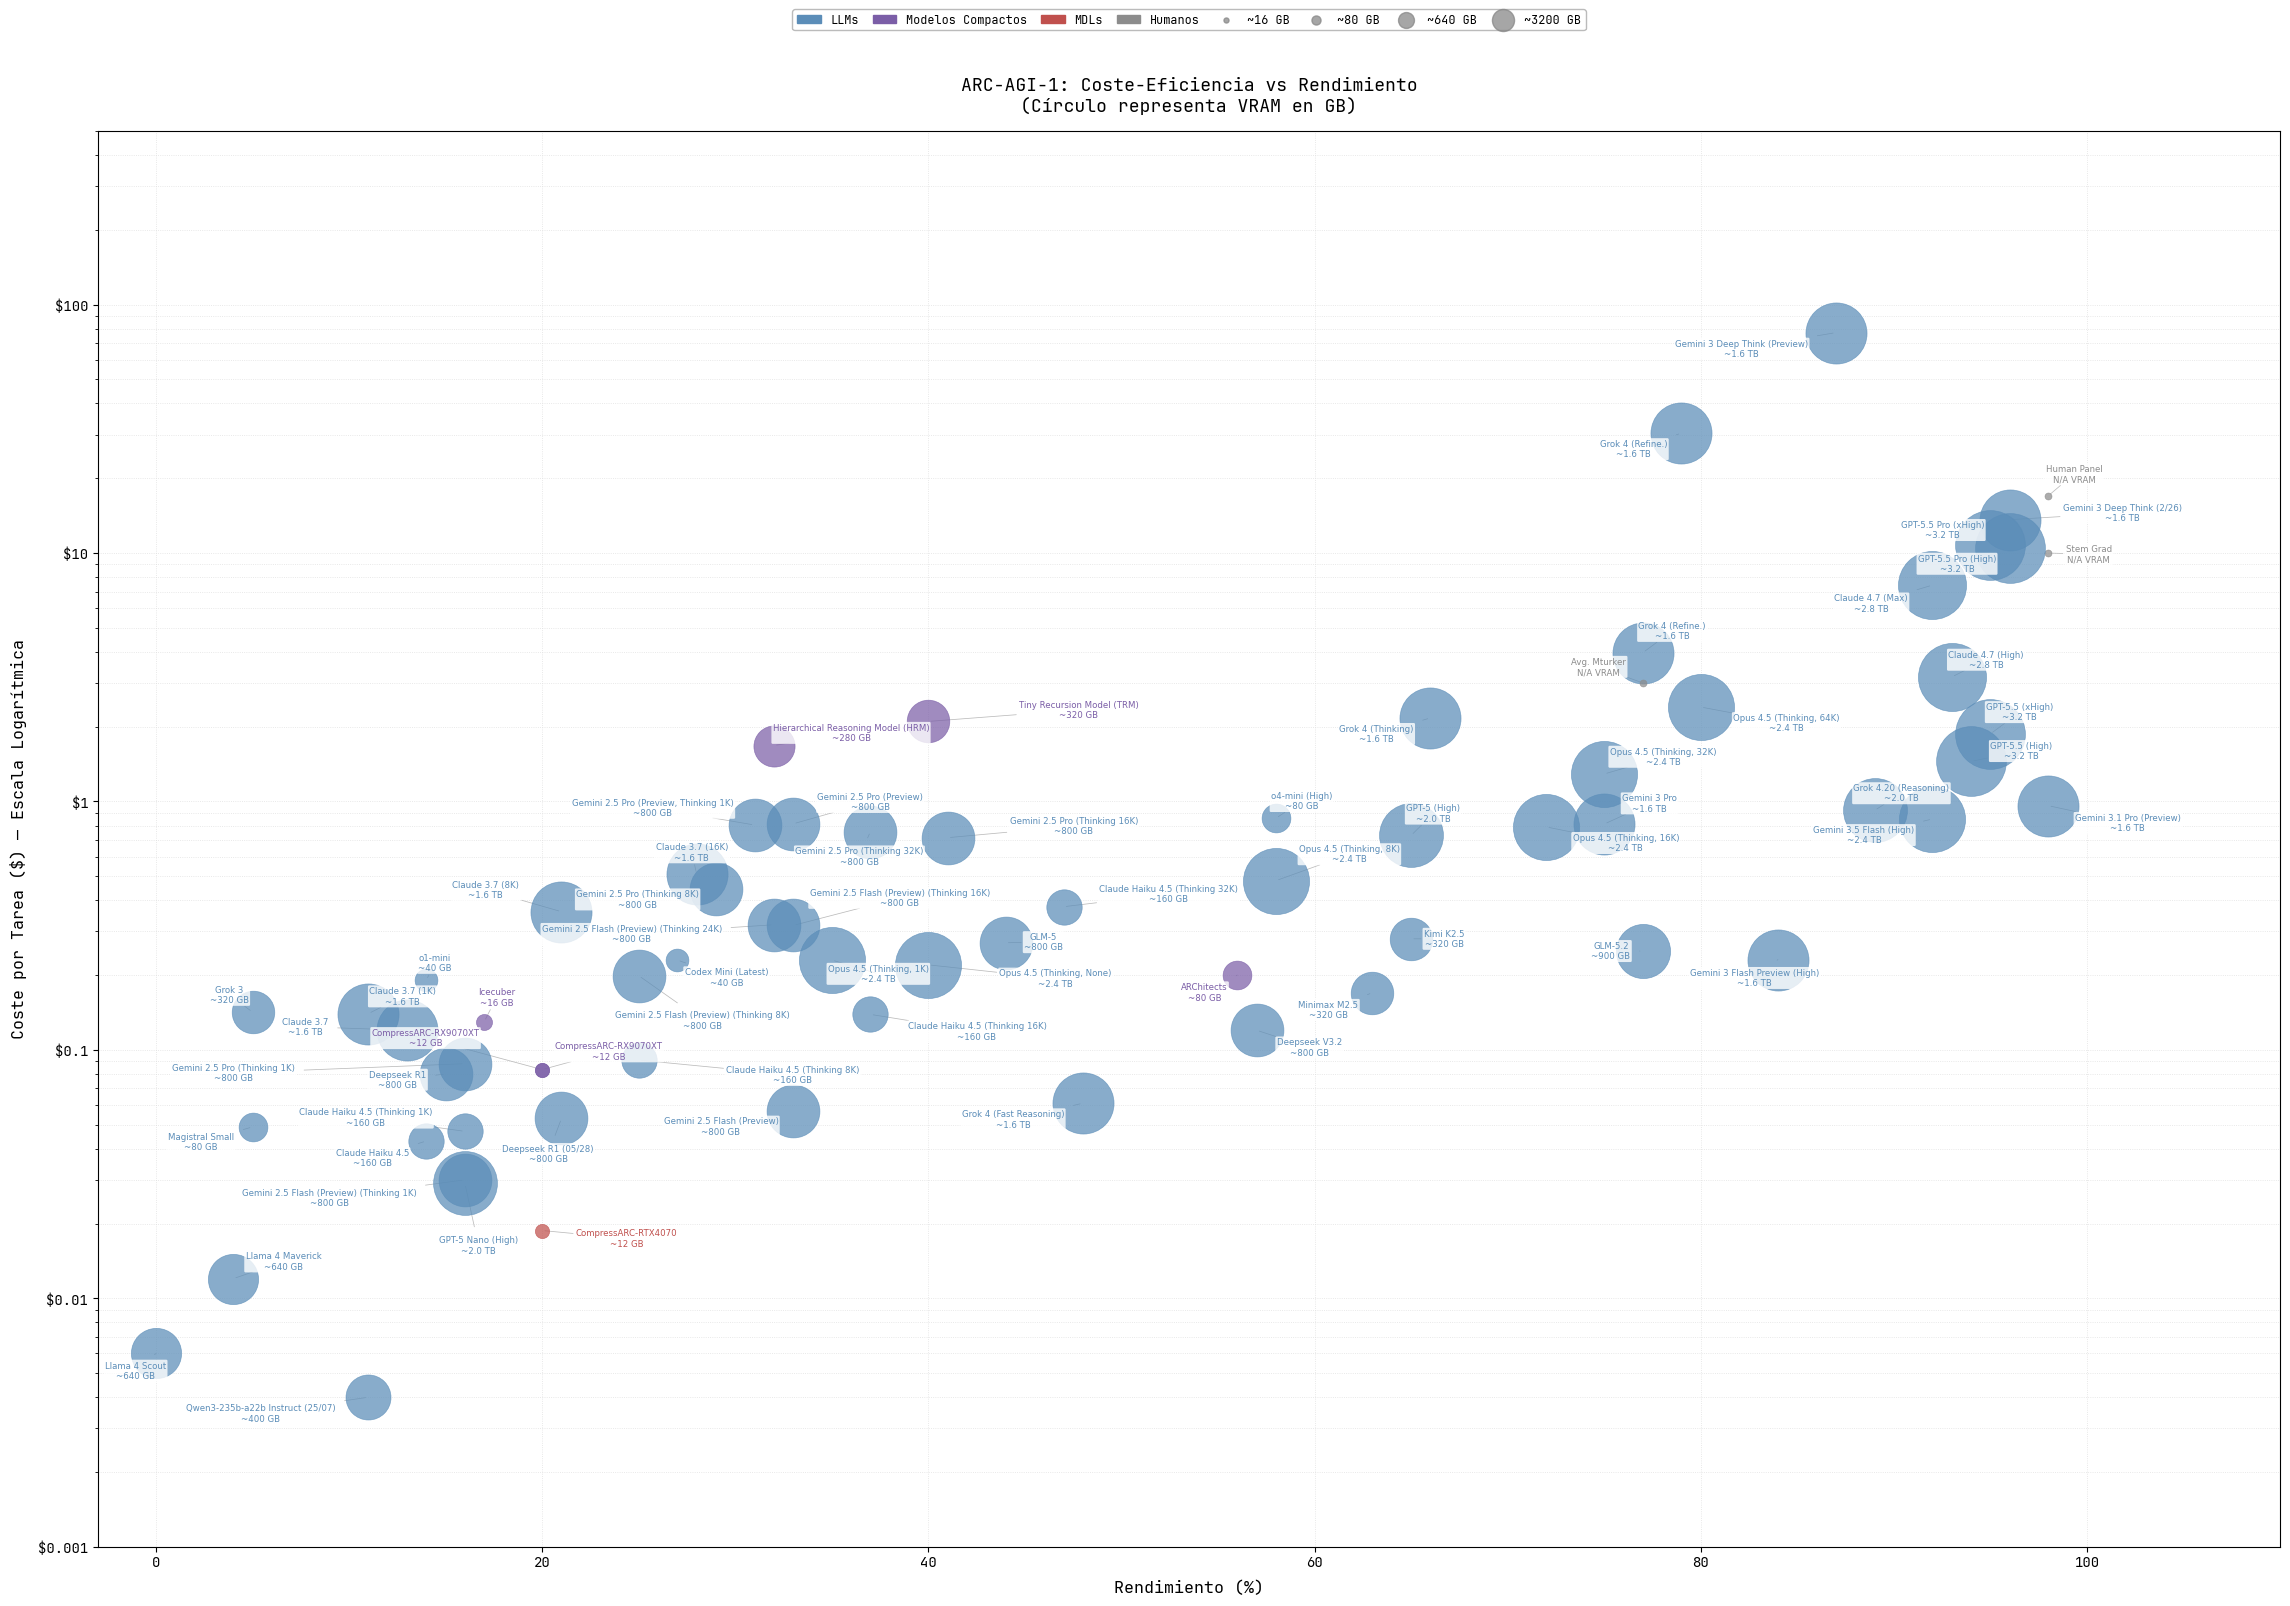

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/vram_models_cost_dark.png


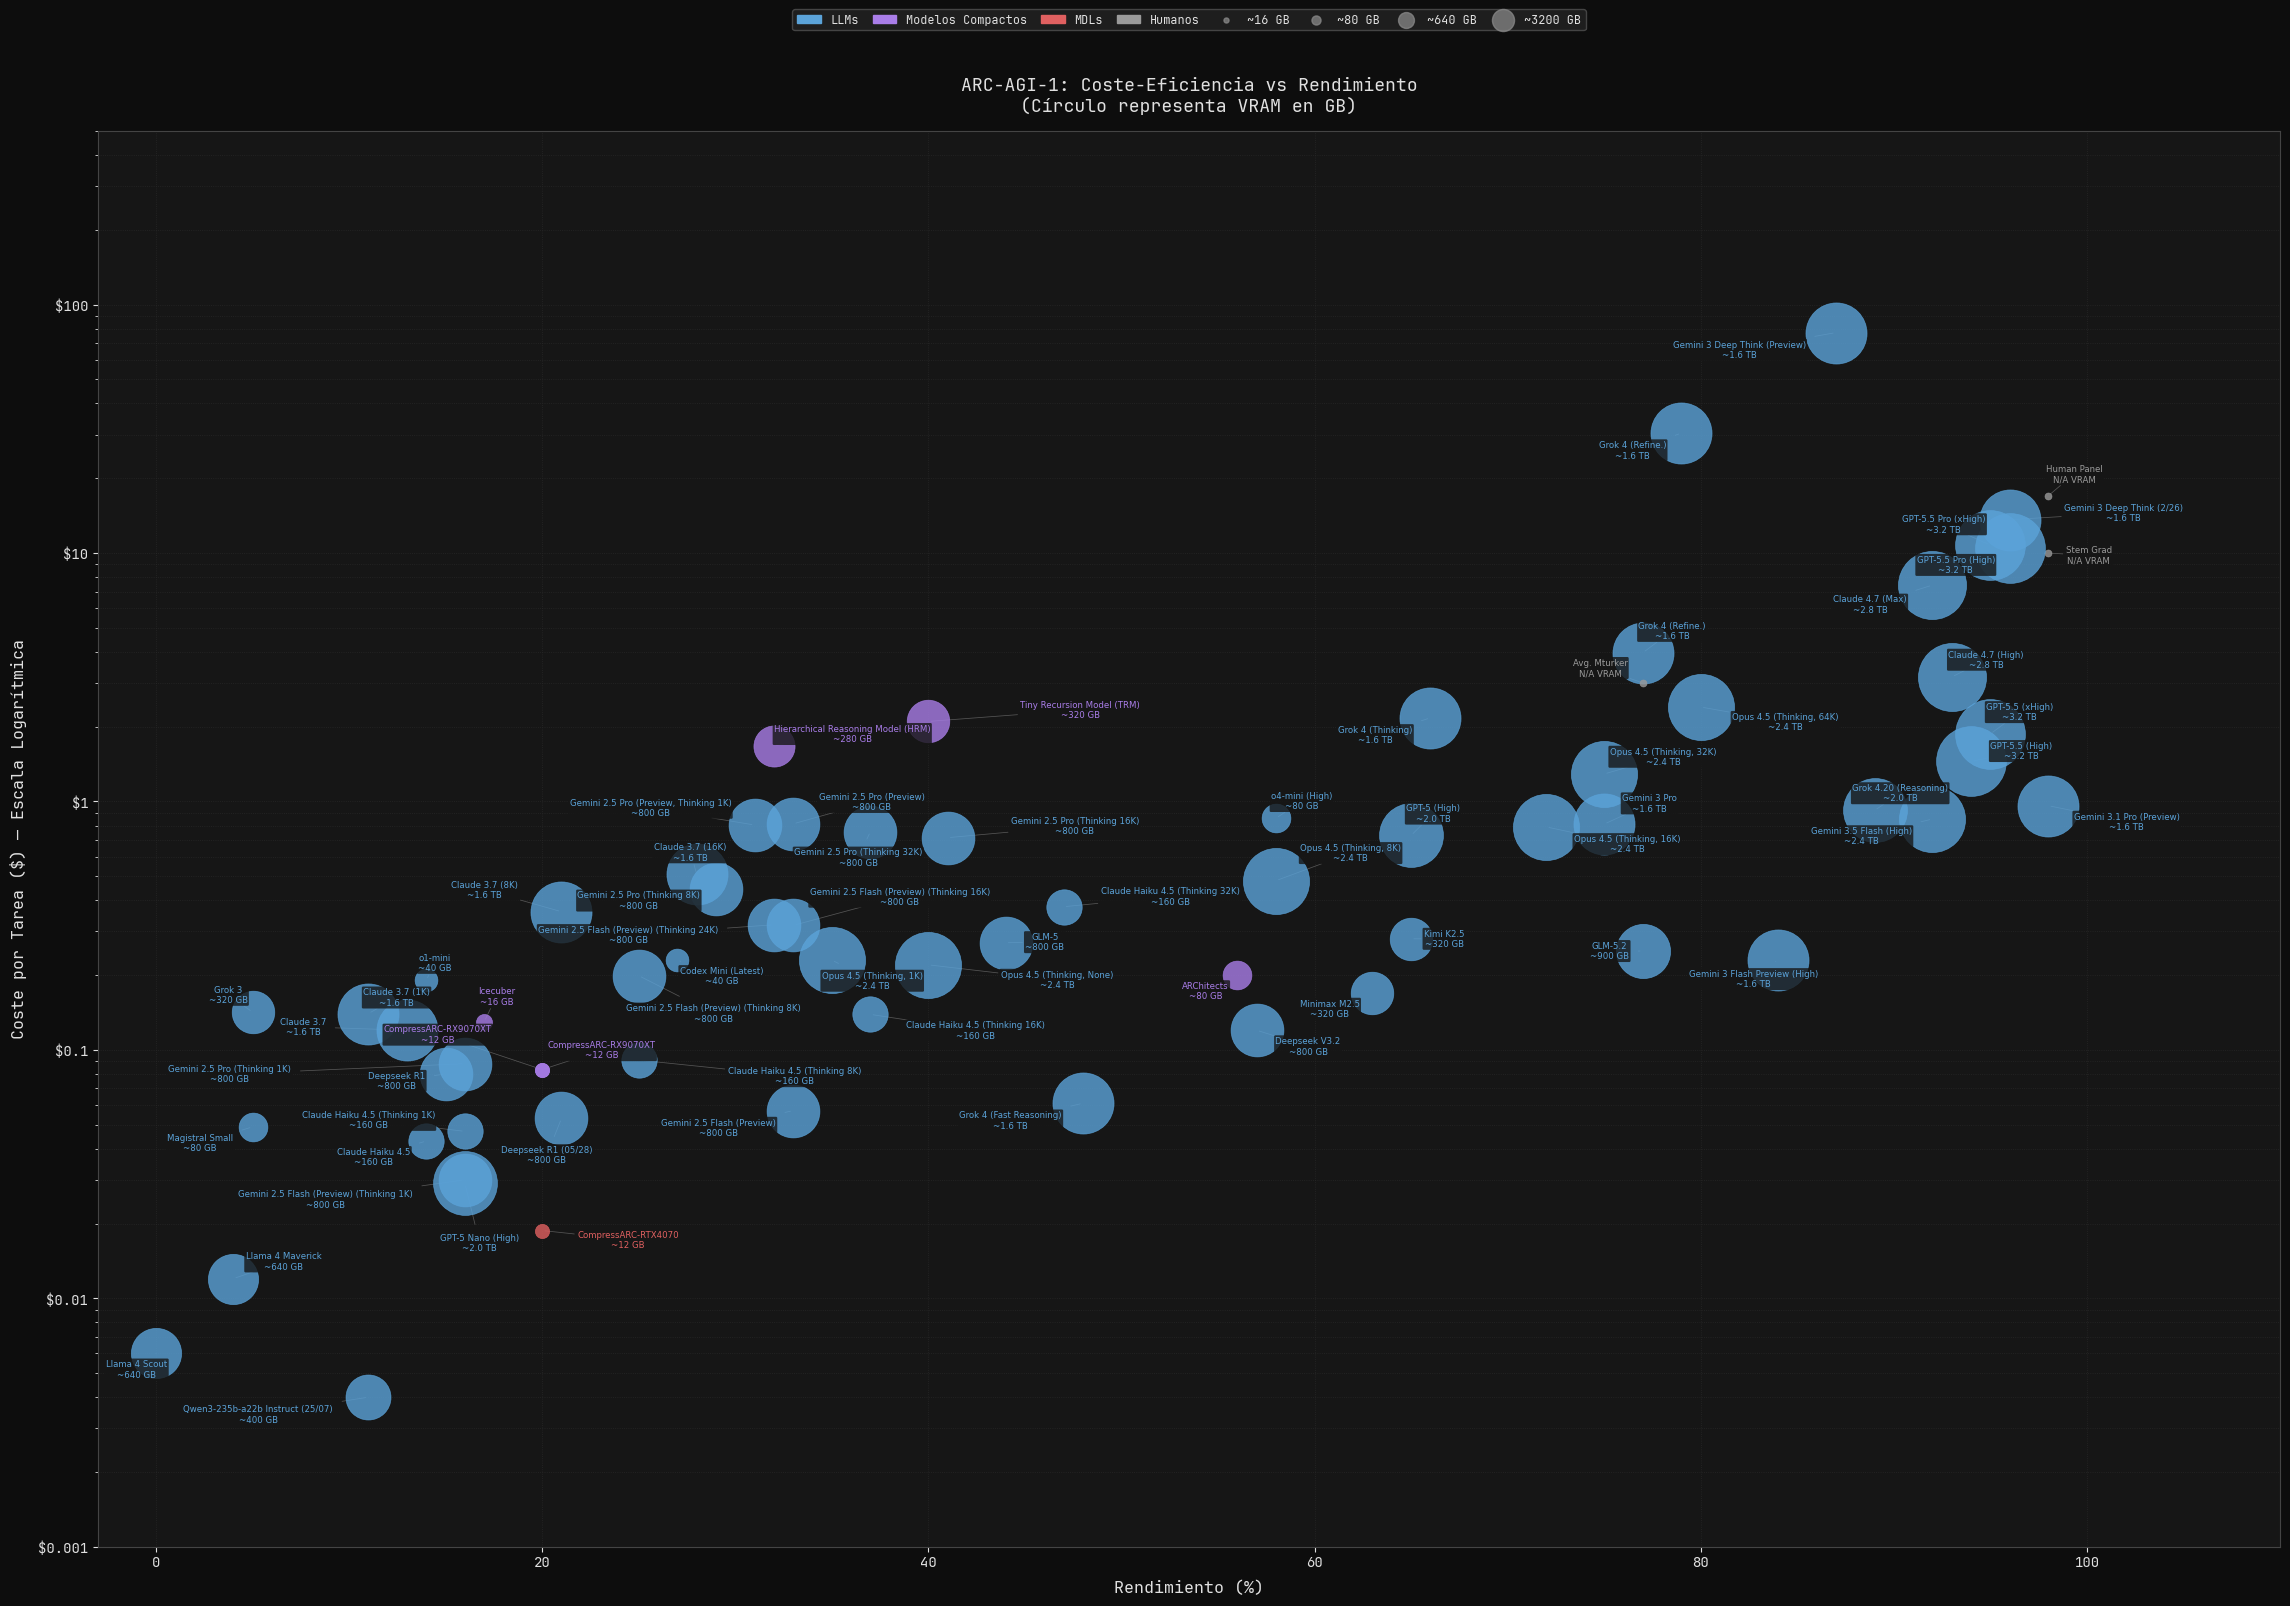

In [59]:
def plot_vram_bubble_chart(df, theme='light', save_path=None):
    """
    Plot ARC-AGI-1 cost-efficiency vs performance bubble chart.
    Bubble size represents VRAM usage (GB).

    Parameters
    ----------
    df : pd.DataFrame
        Must contain: arc_agi_1, cost_per_task, vram_gb,
        author, model, solution_type.
    theme : {'light', 'dark'}

    VRAM tiers in the dataset:
        0 GB  → human baselines / unknown
        12–16 GB → consumer GPU (CompressARC-RTX4070, Icecuber)
        40–80 GB → single datacenter GPU (o4-mini, ARChitects)
    160–320 GB → multi-GPU small (Claude Haiku, TRM, Kimi)
    640–800 GB → multi-GPU large (Llama 4, GLM-5, Deepseek)
        1600 GB → large cluster (Grok 4, Claude 3.7, Gemini 3)
    2400–3200 GB → frontier cluster (GPT-5.5, Claude 4.7)
    """
    if theme == 'dark':
        BG_COLOR     = '#0D0D0D';  PANEL_COLOR  = '#161616'
        GRID_COLOR   = '#2A2A2A';  TEXT_COLOR   = '#E0E0E0';  SPINE_COLOR = '#444444'
        MUTED_BLUE   = '#5BA3D9';  GREY_COL     = '#9A9A9A'
        PURPLE_COL   = '#A97DE8';  MUTED_RED    = '#E06060'
        ARROW_COLOR  = '#555555';  BBOX_FC = '#161616'
        LEG_FC = '#1E1E1E';        LEG_EC = '#444444';         LEG_LC = '#E0E0E0'
        BUBBLE_ALPHA = 0.80
    else:
        BG_COLOR     = 'white';    PANEL_COLOR  = 'white'
        GRID_COLOR   = '#DCDCDC';  TEXT_COLOR   = 'black';    SPINE_COLOR = 'black'
        MUTED_BLUE   = '#5B8DB8';  GREY_COL     = '#8C8C8C'
        PURPLE_COL   = '#7B5EA7';  MUTED_RED    = '#C0504D'
        ARROW_COLOR  = '#BBBBBB';  BBOX_FC = 'white'
        LEG_FC = 'white';          LEG_EC = '#BBBBBB';         LEG_LC = 'black'
        BUBBLE_ALPHA = 0.72

    # ── Prepare data ──────────────────────────────────────────────────────────
    df_plot = df.dropna(subset=['cost_per_task', 'arc_agi_1']).copy()
    df_plot = df_plot[df_plot['cost_per_task'] > 0].reset_index(drop=True)

    _VRAM_LOG_MAX = np.log10(3201)

    def fmt_vram(v):
        if pd.isna(v) or v == 0:  return "N/A VRAM"
        if v < 1000:               return f"~{v:.0f} GB"
        return f"~{v / 1000:.1f} TB"

    def bubble_size(v):
        if pd.isna(v) or v <= 0:  return 25
        norm = np.log10(v + 1) / _VRAM_LOG_MAX   # [0, 1]
        return 25 + norm ** 3.0 * 2500

    def get_color(row):
        if row['author'] == 'Human':             return GREY_COL
        if row['model'] == 'CompressARC-RTX4070':         return MUTED_RED
        if row.get('solution_type') == 'Custom':  return PURPLE_COL
        return MUTED_BLUE

    df_plot['bsize']  = df_plot['vram_gb'].apply(bubble_size)
    df_plot['vlabel'] = df_plot['vram_gb'].apply(fmt_vram)
    df_plot['color']  = df_plot.apply(get_color, axis=1)

    plt.rcParams['font.family'] = 'JetBrains Mono NL'
    # plt.rcParams['font.family'] = 'JetBrains Mono'
    # plt.rcParams['font.family'] = 'Cascadia Code'

    # ── Figure / axes ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(23, 16))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(PANEL_COLOR)
    ax.grid(True, which='both', linestyle=':', color=GRID_COLOR, linewidth=0.6, alpha=0.85)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8);  spine.set_color(SPINE_COLOR)
    ax.tick_params(colors=TEXT_COLOR, which='both')
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

    # ── Scatter bubbles ───────────────────────────────────────────────────────
    for _, row in df_plot.iterrows():
        ax.scatter(row['arc_agi_1'], row['cost_per_task'],
                s=row['bsize'], c=row['color'],
                alpha=BUBBLE_ALPHA, edgecolors=row['color'], linewidths=0.5, zorder=4)

    # ── Axes config ───────────────────────────────────────────────────────────
    ax.set_xlim(-3, 110);  ax.set_xticks(range(0, 101, 20))
    ax.set_xlabel('Rendimiento (%)', fontsize=12, labelpad=8)
    ax.set_yscale('log');  ax.set_ylim(0.002, 500)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:g}'))
    ax.set_yticks([0.001, 0.01, 0.1, 1, 10, 100])
    ax.set_ylabel('Coste por Tarea ($) — Escala Logarítmica', fontsize=12, labelpad=8)
    ax.set_title(
        'ARC-AGI-1: Coste-Eficiencia vs Rendimiento\n(Círculo representa VRAM en GB)',
        fontsize=13, pad=14
    )

    # ── Annotations with leader lines ─────────────────────────────────────────
    # offset_x_pool    = [28, -32, 28, -32, 20, -24, 32, -28, 16, -20]
    # offset_y_factors = [2.5, 0.4, 5.0, 0.2, 1.5, 0.6, 3.5, 0.3, 8.0, 0.15]
    # for i, (_, row) in enumerate(df_plot.iterrows()):
    #     x, y = row['arc_agi_1'], row['cost_per_task']
    #     ox   = offset_x_pool[i % len(offset_x_pool)]
    #     tyf  = offset_y_factors[i % len(offset_y_factors)]
    #     if x > 80 and ox > 0:  ox = -abs(ox)
    #     if x < 10 and ox < 0:  ox =  abs(ox)
    #     ty = max(0.003, min(y * tyf, 200))
    #     ax.annotate(f"{row['model']}\n{row['vlabel']}", xy=(x, y), xytext=(x + ox, ty),
    #                 fontsize=6.2, color=row['color'], fontfamily='sans-serif',
    #                 ha='left' if ox >= 0 else 'right', va='center',
    #                 arrowprops=dict(arrowstyle='-', color=ARROW_COLOR, lw=0.55, shrinkA=0, shrinkB=3),
    #                 bbox=dict(boxstyle='round,pad=0.15', fc=BBOX_FC, ec='none', alpha=0.80), zorder=5)

    texts = []
    for _, row in df_plot.iterrows():
        t = ax.text(row['arc_agi_1'], row['cost_per_task'],
                    f"{row['model']}\n{row['vlabel']}",
                    fontsize=6.2, color=row['color'], fontfamily='sans-serif',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc=BBOX_FC, ec='none', alpha=0.80),
                    zorder=5)
        texts.append(t)

    adjust_text(
        texts,
        x=df_plot['arc_agi_1'].values,
        y=df_plot['cost_per_task'].values,
        arrowprops=dict(arrowstyle='-', color=ARROW_COLOR, lw=0.55),
        expand=(1.3, 1.5),   # how much to expand bounding boxes when checking overlaps
        ax=ax,
    )

    # ── Legend ────────────────────────────────────────────────────────────────
    _ls = 0.10   # legend bubble scale factor — keeps icons within the legend box
    legend_handles = [
        mpatches.Patch(facecolor=MUTED_BLUE,  edgecolor=MUTED_BLUE,  label='LLMs'),
        mpatches.Patch(facecolor=PURPLE_COL,  edgecolor=PURPLE_COL,  label='Modelos Compactos'),
        mpatches.Patch(facecolor=MUTED_RED,   edgecolor=MUTED_RED,   label='MDLs'),
        mpatches.Patch(facecolor=GREY_COL,    edgecolor=GREY_COL,    label='Humanos'),
        plt.scatter([], [], s=bubble_size(16)   * _ls, c='#888888', alpha=0.75, label='~16 GB'),
        plt.scatter([], [], s=bubble_size(80)   * _ls, c='#888888', alpha=0.75, label='~80 GB'),
        plt.scatter([], [], s=bubble_size(640)  * _ls, c='#888888', alpha=0.75, label='~640 GB'),
        plt.scatter([], [], s=bubble_size(3200) * _ls, c='#888888', alpha=0.75, label='~3200 GB'),
    ]
    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.09),
            ncol=8, fontsize=8.5, frameon=True, fancybox=True, edgecolor=LEG_EC,
            framealpha=1.0, columnspacing=1.2, labelcolor=LEG_LC, facecolor=LEG_FC)
    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path, 
            dpi=800,                  # High resolution for presentations/papers
            bbox_inches='tight',      # Prevents labels from getting cut off
            facecolor=fig.get_facecolor() # Preserves your dark/light background color
        )
        print(f"Plot saved successfully to: {save_path}")
    
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
# Save the light theme version
light_image_path = output_folder / "vram_models_cost_light.png"

# Save the dark theme version
dark_image_path = output_folder / "vram_models_cost_dark.png"

plot_vram_bubble_chart(df_saved_only_arc_1, theme='light', save_path=light_image_path)
plot_vram_bubble_chart(df_saved_only_arc_1, theme='dark', save_path=dark_image_path)


Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/cost_models_cost_light.png


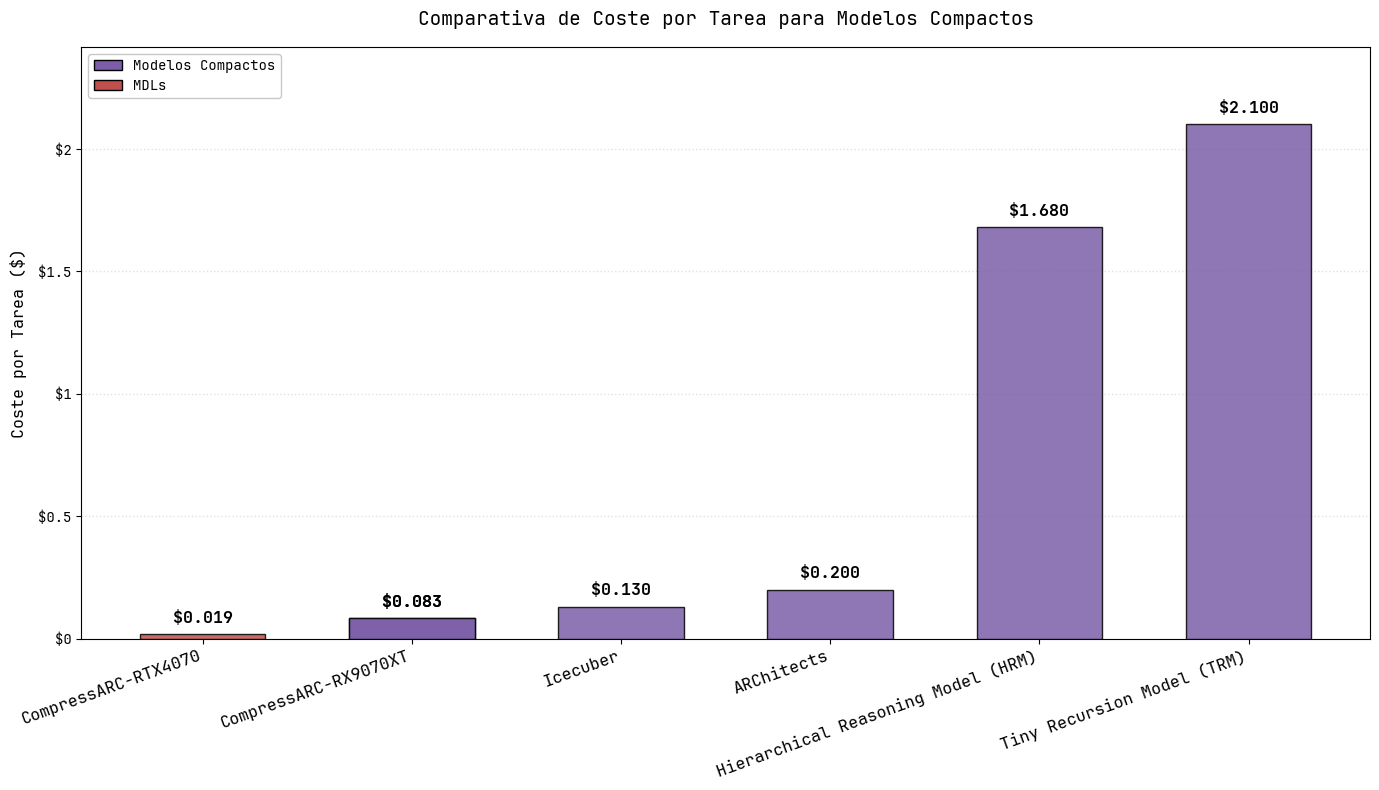

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/cost_models_cost_dark.png


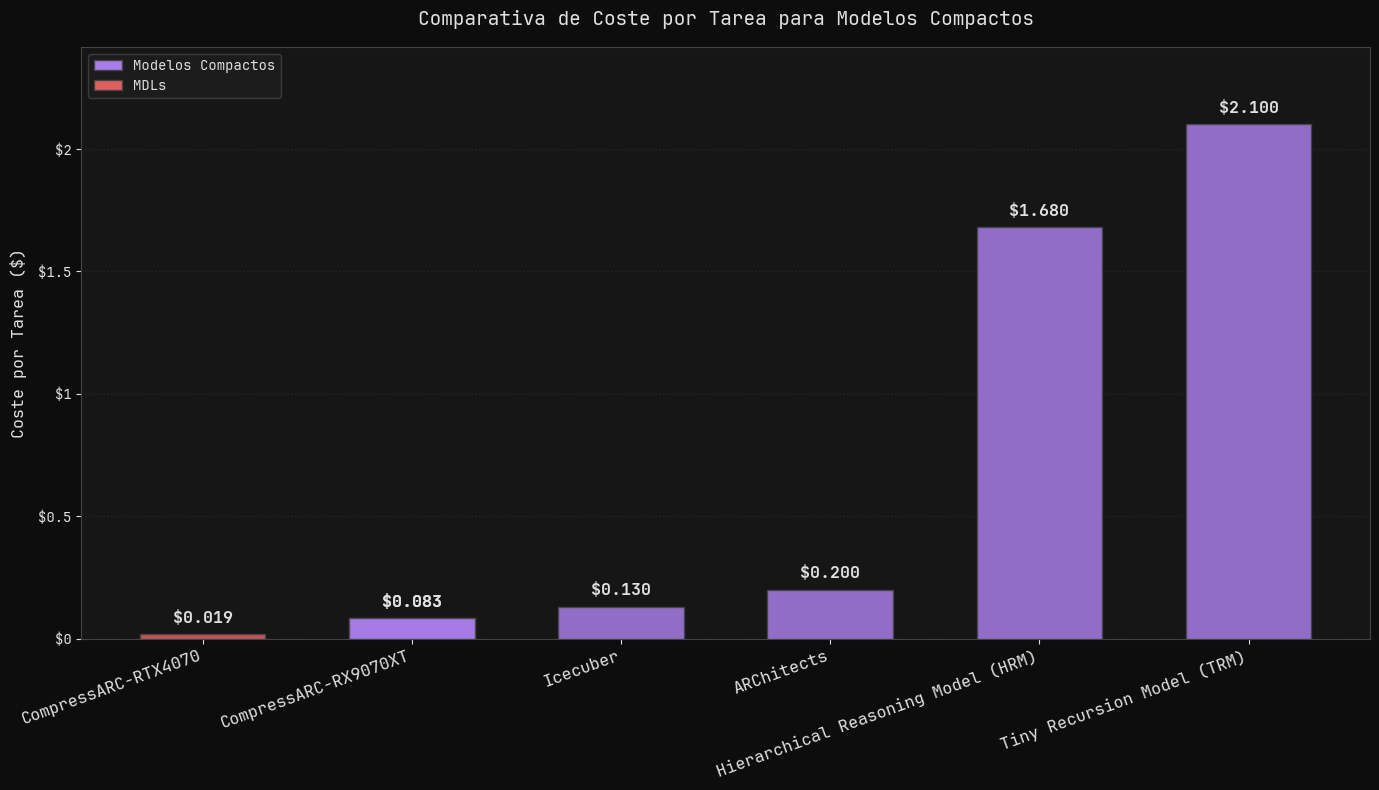

In [60]:
def plot_custom_models_cost_bar_chart(df, theme='light', save_path=None):
    """
    Plot bar chart comparing the cost per task specifically for 'Custom' models.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain: cost_per_task, model, solution_type.
    theme : {'light', 'dark'}
    """
    # ── Theme Colors ──────────────────────────────────────────────────────────
    if theme == 'dark':
        BG_COLOR     = '#0D0D0D';  PANEL_COLOR  = '#161616'
        GRID_COLOR   = '#2A2A2A';  TEXT_COLOR   = '#E0E0E0';  SPINE_COLOR = '#444444'
        PURPLE_COL   = '#A97DE8';  MUTED_RED    = '#E06060'
        LEG_FC       = '#1E1E1E';  LEG_EC       = '#444444';  LEG_LC      = '#E0E0E0'
    else:
        BG_COLOR     = 'white';    PANEL_COLOR  = 'white'
        GRID_COLOR   = '#DCDCDC';  TEXT_COLOR   = 'black';    SPINE_COLOR = 'black'
        PURPLE_COL   = '#7B5EA7';  MUTED_RED    = '#C0504D'
        LEG_FC       = 'white';    LEG_EC       = '#BBBBBB';  LEG_LC      = 'black'

    # ── Prepare Data ──────────────────────────────────────────────────────────
    # Filter only Custom solutions and valid cost_per_task
    df_plot = df[df['solution_type'] == 'Custom'].dropna(subset=['cost_per_task', 'model']).copy()
    df_plot = df_plot[df_plot['cost_per_task'] > 0].reset_index(drop=True)
    
    # Sort by lowest cost to highest for a better narrative
    df_plot = df_plot.sort_values(by='cost_per_task', ascending=True).reset_index(drop=True)

    # Apply JetBrains font globablly for this plot
    plt.rcParams['font.family'] = 'JetBrains Mono NL'

    # ── Figure / Axes Setup ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(PANEL_COLOR)

    # Use horizontal grid lines only for bar charts
    ax.grid(True, axis='y', linestyle=':', color=GRID_COLOR, linewidth=1.0, alpha=0.85)
    ax.grid(False, axis='x')
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color(SPINE_COLOR)

    ax.tick_params(colors=TEXT_COLOR, which='both')
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

    # ── Plot Bars ─────────────────────────────────────────────────────────────
    # Distinctive color for "CompressARC-RTX4070" compared to other custom models
    bar_colors = [MUTED_RED if model == 'CompressARC-RTX4070' else PURPLE_COL for model in df_plot['model']]
    
    bars = ax.bar(
        df_plot['model'], 
        df_plot['cost_per_task'], 
        color=bar_colors, 
        edgecolor=SPINE_COLOR, 
        alpha=0.85, 
        width=0.6,
        zorder=4
    )

    # ── Axes Formatting ───────────────────────────────────────────────────────
    # Linear scale is preferred for bar charts as they encode value in length starting at 0
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:g}'))
    ax.set_ylabel('Coste por Tarea ($)', fontsize=12, labelpad=8)
    #ax.set_xlabel('Modelo', fontsize=12, labelpad=8)
    
    # Margins and titles
    ax.margins(y=0.15)  # Add some space at the top of the bars for text annotations
    ax.set_title(
        'Comparativa de Coste por Tarea para Modelos Compactos',
        fontsize=14, pad=16
    )

    # Slant the X labels so they don't overlap
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=12)

    # ── Annotate Bars ─────────────────────────────────────────────────────────
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'${height:.3f}',  # Formatting to 3 decimals to see the small differences
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 6),  # 6 points vertical offset
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=12, color=TEXT_COLOR,
            fontweight='bold'
        )

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=PURPLE_COL, edgecolor=SPINE_COLOR, label='Modelos Compactos'),
        mpatches.Patch(facecolor=MUTED_RED,  edgecolor=SPINE_COLOR, label='MDLs')
    ]
    ax.legend(
        handles=legend_handles, 
        loc='upper left', 
        fontsize=10, 
        frameon=True, 
        facecolor=LEG_FC, 
        edgecolor=LEG_EC, 
        labelcolor=LEG_LC
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(
            save_path, 
            dpi=800,                  # High resolution for presentations/papers
            bbox_inches='tight',      # Prevents labels from getting cut off
            facecolor=fig.get_facecolor() # Preserves your dark/light background color
        )
        print(f"Plot saved successfully to: {save_path}")
    
    plt.show()

# ── Usage ─────────────────────────────────────────────────────────────────────
# Save the light theme version
light_image_path = output_folder / "cost_models_cost_light.png"

# Save the dark theme version
dark_image_path = output_folder / "cost_models_cost_dark.png"

plot_custom_models_cost_bar_chart(df_saved_only_arc_1, theme='light', save_path=light_image_path)
plot_custom_models_cost_bar_chart(df_saved_only_arc_1, theme='dark', save_path=dark_image_path)

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/efficiency_models_light.png


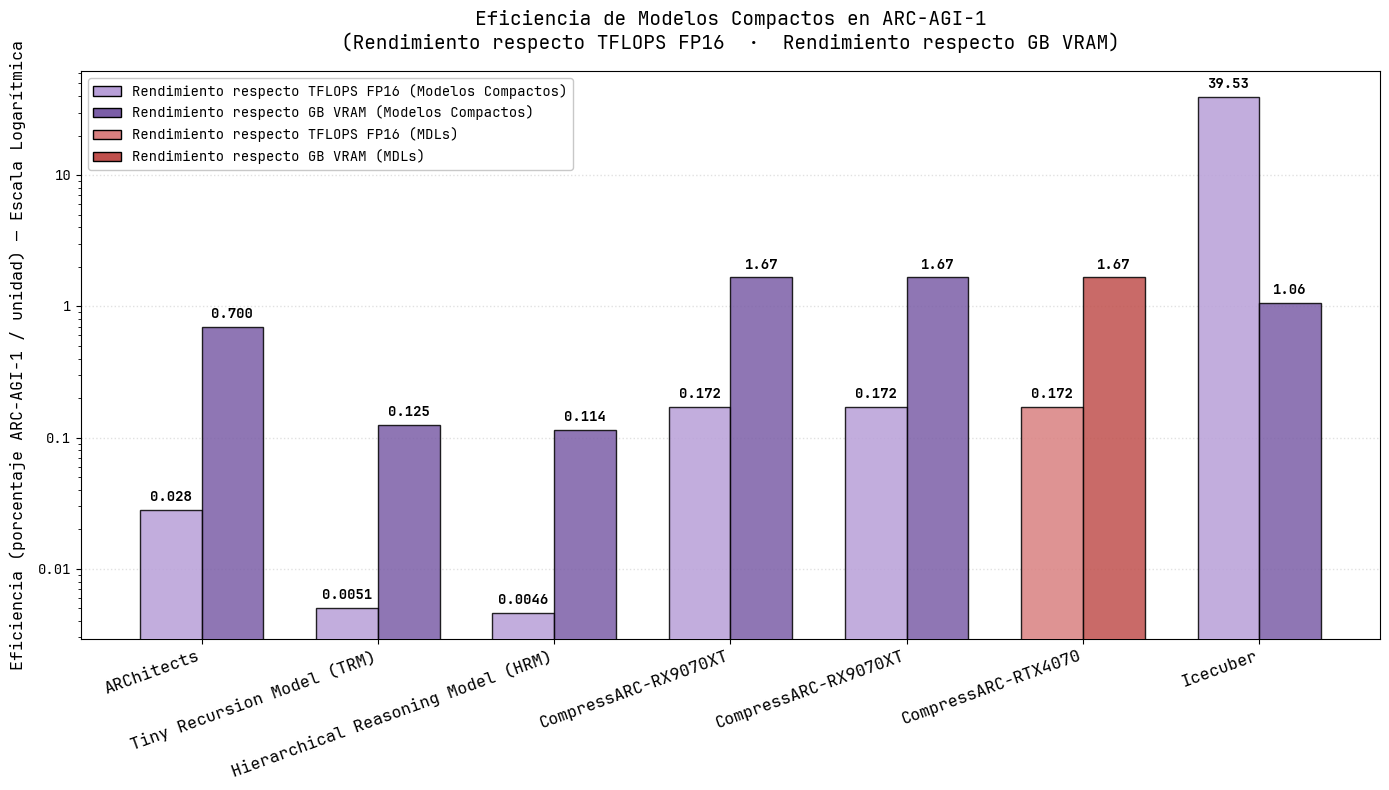

Plot saved successfully to: /home/asier/repos/arc-agi/src/arc_agi_data_scraper/images/efficiency_models_dark.png


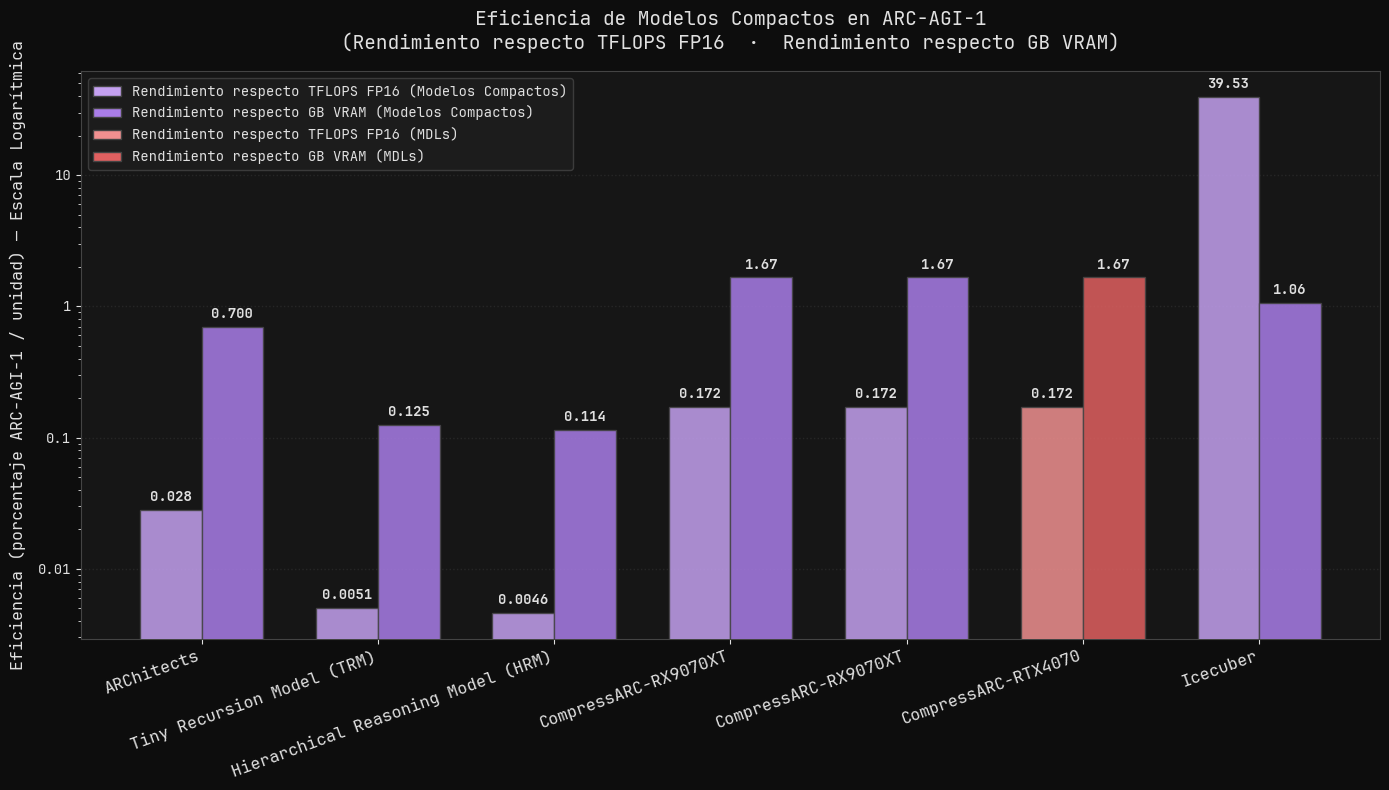

In [61]:
def plot_custom_models_efficiency_bar_chart(df, theme='light', save_path=None):
    """
    Plot grouped bar chart comparing compute-efficiency for 'Custom' models.
    Each model has two bars:
      - arc_agi_1 / peak_precision_tflops_fp16  (puntos ARC-AGI-1 por TFLOP FP16)
      - arc_agi_1 / vram_gb                      (puntos ARC-AGI-1 por GB VRAM)

    Parameters
    ----------
    df : pd.DataFrame
        Must contain: arc_agi_1, peak_precision_tflops_fp16, vram_gb, model, solution_type.
    theme : {'light', 'dark'}
    """
    # ── Theme Colors ──────────────────────────────────────────────────────────
    if theme == 'dark':
        BG_COLOR     = '#0D0D0D';  PANEL_COLOR  = '#161616'
        GRID_COLOR   = '#2A2A2A';  TEXT_COLOR   = '#E0E0E0';  SPINE_COLOR   = '#444444'
        PURPLE_LIGHT = '#C4A0F0';  PURPLE_DARK  = '#A97DE8'   # non-CompressARC-RTX4070
        RED_LIGHT    = '#F09090';  RED_DARK     = '#E06060'   # CompressARC-RTX4070
        LEG_FC       = '#1E1E1E';  LEG_EC       = '#444444';  LEG_LC        = '#E0E0E0'
    else:
        BG_COLOR     = 'white';    PANEL_COLOR  = 'white'
        GRID_COLOR   = '#DCDCDC';  TEXT_COLOR   = 'black';    SPINE_COLOR   = 'black'
        PURPLE_LIGHT = '#B89FD8';  PURPLE_DARK  = '#7B5EA7'   # non-CompressARC-RTX4070
        RED_LIGHT    = '#D98080';  RED_DARK     = '#C0504D'   # CompressARC-RTX4070
        LEG_FC       = 'white';    LEG_EC       = '#BBBBBB';  LEG_LC        = 'black'

    # ── Prepare Data ──────────────────────────────────────────────────────────
    df_plot = df[df['solution_type'] == 'Custom'].dropna(subset=['arc_agi_1', 'model']).copy()
    df_plot = df_plot[df_plot['arc_agi_1'] > 0].reset_index(drop=True)

    df_plot['eff_tflops'] = np.where(
        df_plot['peak_precision_tflops_fp16'].notna() & (df_plot['peak_precision_tflops_fp16'] > 0),
        df_plot['arc_agi_1'] / df_plot['peak_precision_tflops_fp16'],
        np.nan
    )
    df_plot['eff_vram'] = np.where(
        df_plot['vram_gb'].notna() & (df_plot['vram_gb'] > 0),
        df_plot['arc_agi_1'] / df_plot['vram_gb'],
        np.nan
    )

    # Sort by ARC-AGI-1 score descending (same narrative as leaderboard)
    df_plot = df_plot.sort_values(by='arc_agi_1', ascending=False).reset_index(drop=True)

    plt.rcParams['font.family'] = 'JetBrains Mono NL'

    # ── Figure / Axes Setup ───────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 8))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(PANEL_COLOR)

    ax.grid(True, axis='y', linestyle=':', color=GRID_COLOR, linewidth=1.0, alpha=0.85)
    ax.grid(False, axis='x')
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color(SPINE_COLOR)

    ax.tick_params(colors=TEXT_COLOR, which='both')
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

    # ── Grouped Bars ──────────────────────────────────────────────────────────
    n = len(df_plot)
    x = np.arange(n)
    width = 0.35

    colors_tflops = [RED_LIGHT  if m == 'CompressARC-RTX4070' else PURPLE_LIGHT for m in df_plot['model']]
    colors_vram   = [RED_DARK   if m == 'CompressARC-RTX4070' else PURPLE_DARK  for m in df_plot['model']]

    bars1 = ax.bar(x - width / 2, df_plot['eff_tflops'], width,
                   color=colors_tflops, edgecolor=SPINE_COLOR, alpha=0.85, zorder=4)
    bars2 = ax.bar(x + width / 2, df_plot['eff_vram'],   width,
                   color=colors_vram,   edgecolor=SPINE_COLOR, alpha=0.85, zorder=4)

    # ── Axes Formatting ───────────────────────────────────────────────────────
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.set_ylabel('Eficiencia (porcentaje ARC-AGI-1 / unidad) — Escala Logarítmica', fontsize=12, labelpad=8)
    ax.set_title(
        'Eficiencia de Modelos Compactos en ARC-AGI-1\n'
        '(Rendimiento respecto TFLOPS FP16  ·  Rendimiento respecto GB VRAM)',
        fontsize=14, pad=16
    )

    ax.set_xticks(x)
    ax.set_xticklabels(df_plot['model'], rotation=20, ha='right', fontsize=12)

    # ── Annotate Bars ─────────────────────────────────────────────────────────
    def fmt_eff(v):
        if v >= 1:     return f'{v:.2f}'
        if v >= 0.01:  return f'{v:.3f}'
        return f'{v:.4f}'

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if np.isnan(h) or h <= 0:
            continue
        ax.annotate(
            fmt_eff(h),
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 4), textcoords='offset points',
            ha='center', va='bottom',
            fontsize=10, color=TEXT_COLOR, fontweight='bold'
        )

    # ── Legend ────────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=PURPLE_LIGHT, edgecolor=SPINE_COLOR, label='Rendimiento respecto TFLOPS FP16 (Modelos Compactos)'),
        mpatches.Patch(facecolor=PURPLE_DARK,  edgecolor=SPINE_COLOR, label='Rendimiento respecto GB VRAM (Modelos Compactos)'),
        mpatches.Patch(facecolor=RED_LIGHT,    edgecolor=SPINE_COLOR, label='Rendimiento respecto TFLOPS FP16 (MDLs)'),
        mpatches.Patch(facecolor=RED_DARK,     edgecolor=SPINE_COLOR, label='Rendimiento respecto GB VRAM (MDLs)'),
    ]
    ax.legend(
        handles=legend_handles,
        loc='upper left',
        fontsize=10,
        frameon=True,
        facecolor=LEG_FC,
        edgecolor=LEG_EC,
        labelcolor=LEG_LC
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=800, bbox_inches='tight', facecolor=fig.get_facecolor())
        print(f'Plot saved successfully to: {save_path}')

    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
efficiency_light_path = output_folder / "efficiency_models_light.png"
efficiency_dark_path  = output_folder / "efficiency_models_dark.png"

plot_custom_models_efficiency_bar_chart(df_saved_only_arc_1, theme='light', save_path=efficiency_light_path)
plot_custom_models_efficiency_bar_chart(df_saved_only_arc_1, theme='dark',  save_path=efficiency_dark_path)